# Kandinsky 2.2 Inpainting — DIMER guided end-to-end notebook (standalone)

[![GitHub](https://img.shields.io/badge/GitHub-181717?style=flat&logo=github&logoColor=white)](https://github.com/kurtvalcorza/kandinsky-inpainting-pipeline) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kurtvalcorza/kandinsky-inpainting-pipeline/blob/main/tutorials/kandinsky_inpainting_colab.ipynb) [![Hugging Face](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-kandinsky--community%2Fkandinsky--2--2--decoder--inpaint-ffcc4d?style=flat)](https://huggingface.co/kandinsky-community/kandinsky-2-2-decoder-inpaint) [![Upstream](https://img.shields.io/badge/Upstream-ai--forever%2FKandinsky--2-181717?style=flat&logo=github&logoColor=white)](https://github.com/ai-forever/Kandinsky-2) [![License](https://img.shields.io/badge/License-Apache--2.0-blue.svg)](https://www.apache.org/licenses/LICENSE-2.0)

**Profile:** `E2E`  
**Mode:** `GUIDED`  
**Notebook specification:** DIMER Notebook Specification 2.2 — **standalone** (§4)  
**Capability:** masked image inpainting with a 1.25 B-parameter UNet diffusion model, held-out denoising-loss, preservation and CLIP-scored evaluation, and bounded LoRA fine-tuning to a set of captioned photographs

**This notebook is standalone.** Section 2 carries the repository's package (4 modules under `src/kandinsky_inpainting_pipeline/`, at revision `6539f63ff676`), the stage runner, the hash-locked requirements (68 packages), the pinned snapshot manifests and the licence, and verifies every carried file against its SHA-256 before use, so the notebook keeps working after export even if the repository changes or disappears. Nothing is installed into the notebook kernel: a pinned `uv` (checked by size and SHA-256) builds an isolated Python environment from the lock with `--require-hashes`, and every stage runs there in its own process, so the hosted runtime's own packages are never replaced and no restart is needed. Its only external dependencies are PyPI, the managed CPython build that `uv` downloads, the Hugging Face Hub at the immutable revision `db790ad5cbcabed886f069ef2710774657621702` and its two companion revisions (~16468 MB, digest-verified before loading), and the public sample-data bucket named in the Prerequisites. It was generated by `tools/build_notebook.py` (build_notebook.py/3.0); edit the repository and regenerate rather than editing cells.

**Run all:** Selecting **Run all** in a fresh Linux **GPU** runtime (a 16 GB T4 is enough; see the Prerequisites) builds an isolated Python environment from the carried hash-locked requirements (torch, diffusers, transformers, peft, accelerate, sentencepiece, safetensors, huggingface-hub, numpy, pillow and their dependencies) without touching the notebook kernel's own packages, then runs each stage below in its own process: it stages and digest-verifies three pinned snapshots from the Hub — the 5.28 GB Kandinsky 2.2 inpainting decoder (UNet + MoVQ), the 10.57 GB Kandinsky 2.2 diffusion prior and a 0.61 GB CLIP scorer — fetches 60 CC0 iNaturalist bird photographs as digest-verified JPEGs (about 6 MB, no credential), gives each the deterministic centre mask, validates them and splits them 36 / 12 / 12 by seed, encodes every prompt with the prior and releases the prior, measures the frozen model (held-out denoising loss, preservation of the kept region, and CLIP prompt similarity beside a mean-colour-fill floor and an original-photograph reference), runs a bounded LoRA fine-tuning (4 epochs over 36 photographs) and exports the adapter as safetensors with a manifest, measures the exported adapter in a fresh process on identical inputs, reloads it in a second fresh process to verify parity with the trained in-memory model before inpainting a new caption into held-out photographs, and finally runs one small optional activity that changes the mask size. The default path needs no repository clone, no DIMER worker or service, no credential, no upload dialog, no configuration edit and no runtime restart (NOTEBOOK_SPEC 2.2 §5). The whole run took about 15 minutes on a Kaggle T4 (904.7 s, measured 2026-09-29 in strict single-pass mode with an empty model cache, so the 16.5 GB of downloads are included) at the previous revision of this notebook, which ran the same stages; this revision changes explanations and small printed outputs only. The BYOD journey on the same runtime took 702.9 s.

**Bring Your Own Data:** After the tutorial workflow completes, set `USE_BYOD = True` in Section 4 and re-run from that cell: every stage is a fresh process that rebuilds an unadapted pipeline from the verified snapshots (already staged), so the baseline you measure is the frozen model again. Supply your own photographs, masks and captions as a zip holding `captions.csv` beside the files. The table needs the columns `id`, `file` and `caption`, and may carry a `mask` column naming a mask image of the same size (white = repaint, black = keep); a row without a mask gets the deterministic centre mask, and the cell reports how many records used it. Photographs must have a shorter side of at least 256 px and a longer side of at most 4096 px. The split is stratified within each caption: a caption with 3..7 distinct photographs gives one test and one validation photograph (about 20 % each from 8 photographs on), a caption with one or two photographs goes to training only, and at least 4 training photographs must remain — so you need at least **6 distinct photographs**, for example six of one caption or four of each of two captions; two captions of three photographs each are refused (2 training photographs). The split assumes your photographs are independent: remove near-duplicates (bursts, crops or edits of one scene), because only pixel-identical copies are removed; Section 4 reports any near-duplicate pair that crosses splits. Set `BYOD_PATH` to a zip or directory already in the runtime to skip the upload dialog. Every caption appears in training, validation and test, and your records flow through the same contract — validation, prompt encoding, frozen baseline, adaptation, held-out evaluation, inference, artifact export and reload parity. An invalid zip stops Section 4 with a `RuntimeError` that repeats the validator's message. Uploaded files stay inside this runtime. BYOD is optional and never part of the default path.

Kandinsky 2.2 is a two-stage latent diffusion model from ai-forever (Razzhigaev et al., 2023). A diffusion prior with CLIP text and image encoders maps a caption to a CLIP image embedding. The inpainting decoder's UNet (1,253,074,568 parameters) then denoises a 64 × 64 × 4 latent. Its input has nine channels: the four noisy latent channels, the four latent channels of the photograph with the repaint region zeroed, and one **keep mask** channel (1 = keep). A MoVQ autoencoder encodes the photograph to latents and decodes the result to 512 × 512 RGB pixels. Three pinned snapshots make one inpainting system: the decoder (5.28 GB safetensors), the shared diffusion prior (10.57 GB safetensors) and, for evaluation only, a CLIP ViT-B/32 scorer.

Two properties are handled in the open. **The prior pipeline can be released before training**: Section 5 encodes every caption the notebook uses into image embeddings, each prior run seeded from a SHA-256 of its caption, and releases the prior so that the UNet, the MoVQ, the scorer and a training graph fit on a 16 GB GPU. **Inpainting has no single ground truth** for the repainted region, so the notebook reads three kinds of number: the held-out *denoising loss* (the training objective on photographs the model never trained on), the *preservation* of the kept region, and CLIP scores of the outputs beside two references: a mean-colour-fill floor and the original-photograph reference (a reference line, not a ceiling — an output can score above its original). None of these is a human judgement of image quality.

**Learning objectives:** by the end of this notebook you will be able to **explain** what the mask, the keep-mask channel, the prior and the latent are, and how an inpainting UNet uses them; **inspect** a validated, digest-pinned photograph dataset and **identify** what validation refuses; **predict**, then **compare**, the frozen and the adapted model on identical held-out inputs; **interpret** a denoising loss, a preservation score and a CLIP similarity, and **explain** why none of them alone measures image quality; **apply** a bounded LoRA fine-tuning with explicit hyperparameters; **verify** that an exported safetensors adapter reloads against the pinned base with the same outputs; and **diagnose** how the mask size changes what the model repaints and preserves.

**This notebook does not demonstrate:** text-to-image generation without a source photograph, depth or ControlNet conditioning, outpainting, full fine-tuning, DreamBooth identifiers, safety filtering of prompts or images, human preference studies, FID, prompt engineering, and any claim that a CLIP score, a preservation score or a denoising loss measures image quality.

## How to use this notebook

**Who this notebook is for.** Learners who can open a hosted notebook, run cells in order and read short Python, and who want to see how a diffusion inpainting model is measured and adapted. No prior diffusion-model experience is assumed: each term is explained where it is first used, and the glossary below collects them. A Linux **GPU** runtime is required (Colab: Runtime → Change runtime type → T4 GPU), with about 30 GB of free disk.

- **Run all** from a fresh GPU runtime (Runtime → Run all). Every cell runs in order without editing; nothing asks for input on the default path, and no runtime restart is needed. Sections 1–3 build an isolated environment from hash-locked packages and download about 16.5 GB of verified weights, so they take the longest before any model runs.
- **Infrastructure** cells (Sections 1–3) are collapsed and titled *Infrastructure*. They check the runtime, carry the repository's code, build the isolated environment and verify the model files. You may run them without studying their implementation.
- **Form fields** (`# @param`) such as `USE_BYOD`, `STEPS` or `EPOCHS` can be changed in the form view. The defaults are the canonical path; change them only after one complete run.
- Each section is tagged by kind: **[Concept]** explains an idea, **[Evaluation practice]** concerns fair measurement, and **[Engineering]** concerns reproducibility.
- Before each principal result you are asked to **predict**. Write your prediction down first. After the result, a **What to notice** note describes normal output, and a **Check your reasoning** box holds a sample answer: open it only after you have answered.

**Where the code runs.** The notebook kernel installs nothing and imports no model library. Each learner cell calls `run_stage('…')`, which runs one stage of the carried stage runner in its own process with the isolated environment's Python, streams what it prints, and stops the notebook with the stage's own error message if it fails. Stages hand results to each other only through files in the run directory — the verified snapshots, the caption embeddings, the adapter artifact and JSON records — and GPU memory is released when each stage ends.

**Roadmap.** 1–3 check the runtime, carry the code, build the isolated environment and verify the model (Infrastructure) → 4 photographs, masks, validation and splits → 5 prompt encoding → 6 the frozen baseline → 7 LoRA fine-tuning and export → 8 the paired held-out comparison → 9 fresh reload and a new caption → 10 change one thing: the mask size → interpretation, conclusion and troubleshooting. Optional: re-run from Section 4 with your own photographs and masks (Bring Your Own Data).

**Input → Model/System → Output.** A photograph, a mask marking the region to repaint (white = repaint, black = keep) and a caption → prior (caption → CLIP image embedding) → inpainting UNet (denoises a latent, conditioned on the embedding, the kept latents and the keep mask) → MoVQ decoder → a 512 × 512 photograph whose masked region is repainted to match the caption and whose kept region should be preserved.

<details>
<summary><strong>Glossary</strong> — open when a term is unfamiliar</summary>

| Term | Meaning in this notebook |
|---|---|
| **Inpainting** | Repainting a masked region of a photograph so that it matches a caption and blends with the rest. |
| **Mask** | A greyscale image the size of the photograph. In this repository white (255) marks the region to repaint and black (0) the region to keep. |
| **Keep mask** | The inverse mask (1 = keep) that the Kandinsky 2.2 inpainting UNet reads as its ninth input channel; `unet_keep_mask` converts one into the other. |
| **Latent** | A compressed 64 × 64 × 4 representation of a 512 × 512 image, produced by the MoVQ encoder; diffusion runs on latents, not pixels. |
| **Diffusion / denoising** | Generation starts from random noise and removes it step by step; the UNet predicts the noise to remove. |
| **Prior** | A second diffusion model that turns a caption into a CLIP image embedding, the condition the UNet reads. |
| **Classifier-free guidance** | Mixing a conditioned and an unconditioned prediction; `GUIDANCE_SCALE` sets how strongly the caption steers the result. |
| **Denoising loss** | The mean squared error between predicted and true noise: the training objective, measured here on held-out photographs. |
| **Preservation (PSNR, SSIM)** | How closely the kept region of the output matches the input photograph. Higher is closer. |
| **CLIP prompt similarity** | A frozen CLIP model's similarity score between an image and its caption: an automated proxy, not a human judgement. |
| **LoRA** | Low-rank adapter matrices added to the UNet's attention projections; only they are trained, the base model stays frozen. |
| **Held-out** | Photographs never used for training or for choosing the kept epoch (the test split). |
| **Paired comparison** | Measuring the frozen and the adapted model on identical inputs, noise and seeds, so the difference is the adaptation. |
| **Hash-locked environment** | A separate Python environment built from a requirements file that pins every package to one version and one set of SHA-256 digests; the installer refuses anything else. |
| **Stage** | One step of the workflow run as its own process by `run_stage`; it reads the files earlier stages wrote and writes its own. |

</details>

## Prerequisites

- **Runtime:** a fresh supported **Linux x86_64 GPU** runtime (Google Colab T4 or better, Kaggle T4, or a Linux Jupyter kernel with a CUDA GPU of at least 15 GB). The kernel's own Python version does not matter: the notebook installs nothing into it, and runs every stage with CPython 3.12.12 in an isolated environment built from 68 hash-locked packages (torch 2.14.0, whose Linux wheel is the CUDA 13.0 build). The prior runs in float16 while it encodes captions and is then released; the UNet and MoVQ run in float16; the LoRA tensors are kept in float32 and training uses float16 autocast with loss scaling. CPU-only runtimes are not supported for this notebook. About 18 GB of disk is needed for the snapshots and about 12 GB for the isolated environment.
- **Knowledge:** basic Python and notebooks. Helpful but not required: what a diffusion model does at inference, what classifier-free guidance is, and why a training loss is not a quality score. The glossary above covers the terms.
- **Weights:** the decoder, the diffusion prior and the CLIP scorer are all safetensors; nothing is unpickled and no Hub-hosted code is executed — the model classes come from `diffusers`, `transformers` and `peft` on PyPI. The Kandinsky weights are released under Apache-2.0; the scorer is MIT.
- **Data contract:** a record is `{id, image, caption}` plus an optional `mask_image` — an RGB photograph with shorter side at least 256 px and longer side at most 4096 px, a caption of 1..1000 characters, and a greyscale mask of the same size (255 = repaint). A record without a mask gets the deterministic centre mask (the middle half of each side). Photograph and mask are resized together so the shorter side is 512 px and centre-cropped to 512 × 512. Validation is structural: nothing checks that a caption describes its photograph or that a mask covers anything sensible.
- **Privacy:** Do not upload confidential or restricted data to a hosted runtime unless you are authorized to process it there — photographs of identifiable people, licensed stock images or client material are exactly that. The default path uploads nothing, and uploaded BYOD files are processed only inside this runtime.
- **External access (data):** besides the Hub, the default path fetches 60 pinned photographs (about 6 MB) from the public iNaturalist open-data bucket `inaturalist-open-data.s3.amazonaws.com` over HTTPS, digest-verified before decoding; every photo is CC0 and its observation page is recorded.
- **External access:** the Hugging Face Hub, to fetch the pinned `kandinsky-community/kandinsky-2-2-decoder-inpaint` snapshot and its companions (~16468 MB in total) at revision `db790ad5cbca…` and the revisions in the carried manifests; PyPI (`files.pythonhosted.org`), for the pinned `uv` wheel and the 68 hash-locked packages; and the managed CPython build (python-build-standalone) that `uv` downloads for the isolated environment. No repository clone and no credentials are required; nothing is installed from this repository.

## 1. Check the runtime · [Engineering]

> **Infrastructure.** The code cells in Sections 1–3 are collapsed. You may run them without studying their implementation; they exist for reproducibility and provenance. The learning activities start in Section 4.

**Input:** a fresh hosted runtime. **System:** checks that it is Linux x86_64 with a CUDA GPU and enough free disk, and creates a new run directory. **Output:** the GPU name and the directories this run will use. Each run writes to a new directory under `outputs/kandinsky_inpainting/`, so an earlier export cannot be mistaken for a current result. The verified snapshots are kept in `weights/` and reused by a later run.

In [ ]:
# @title Infrastructure: check the runtime, GPU and disk; create a fresh run directory
import hashlib
import json
import os
import platform
import shutil
import subprocess
import tempfile
import time
import uuid
from pathlib import Path

SESSION_START = time.perf_counter()
if platform.system() != 'Linux' or platform.machine() != 'x86_64':
    raise RuntimeError('This notebook needs a Linux x86_64 GPU runtime (Google Colab or Kaggle with a T4 or better): its locked environment is built for manylinux x86_64.')
try:
    gpu = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'], capture_output=True, text=True)
except FileNotFoundError as exc:
    raise RuntimeError('No GPU driver was found. Select Runtime > Change runtime type > T4 GPU, then Run all.') from exc
if gpu.returncode:
    raise RuntimeError('CUDA was not detected. Select a fresh T4 GPU runtime, then Run all.')
STEM = 'kandinsky_inpainting'
ROOT = Path.cwd() / 'outputs' / STEM / uuid.uuid4().hex[:12]
ROOT.mkdir(parents=True)
WEIGHTS = Path.cwd() / 'weights'
WEIGHTS.mkdir(exist_ok=True)
ENV_ROOT = Path(tempfile.gettempdir()) / (STEM + '_env_' + ROOT.name)
staged_gib = sum(p.stat().st_size for p in WEIGHTS.rglob('*') if p.is_file()) / 1024**3
need = {'weights': max(0.0, 17.5 - staged_gib), 'environment': 12.0}
free = {'weights': shutil.disk_usage(WEIGHTS).free / 1024**3, 'environment': shutil.disk_usage(tempfile.gettempdir()).free / 1024**3}
if os.stat(WEIGHTS).st_dev == os.stat(tempfile.gettempdir()).st_dev:
    short = free['weights'] < need['weights'] + need['environment']
else:
    short = free['weights'] < need['weights'] or free['environment'] < need['environment']
if short:
    raise RuntimeError(f'Not enough free disk: need about {need} GiB, free {free} GiB. Start a fresh runtime (see Troubleshooting).')
print({'gpu': gpu.stdout.strip(), 'kernel_python': platform.python_version(), 'run_directory': str(ROOT), 'weights': str(WEIGHTS), 'environment': str(ENV_ROOT), 'free_gib': {k: round(v, 1) for k, v in free.items()}})

{'gpu': 'Tesla T4, 15360 MiB', 'kernel_python': '3.13.15', 'run_directory': '/content/outputs/kandinsky_inpainting/c8190e696d67', 'weights': '/content/weights', 'environment': '/tmp/kandinsky_inpainting_env_c8190e696d67', 'free_gib': {'weights': 193.2, 'environment': 193.2}}


**Expected result:** one dictionary naming the GPU (for example `Tesla T4, 15360 MiB`), the kernel's Python version, the run directory, the weights directory, the isolated environment's directory and the free disk. If the cell stops with a GPU or disk message, see **Troubleshooting**.

## 2. Carry the code and install the locked runtime · [Engineering]

> **Infrastructure.** The next two code cells are collapsed. The first **is** the repository's code, carried so that this notebook works on its own; the second builds the environment every stage runs in.

The first cell holds, as text, the files the workflow needs: the package's four modules under `src/kandinsky_inpainting_pipeline/` (identity constants, snapshot verification and staging, validation and masks, the pipeline class, the sample corpus and the preservation and CLIP metrics), the stage runner `tutorial_stages.py`, the hash-locked `requirements.txt` (68 packages), the three snapshot manifests and the licence. It writes each file into the run directory and checks its SHA-256 against `CARRIED_HASHES`, stopping on any mismatch. The text is the repository's files byte for byte; the repository's parity test (`tests/test_notebook_parity.py`) fails whenever the two diverge, so what runs here is what the repository tests. Nothing in this cell runs a model.

In [ ]:
# @title Infrastructure: write and verify the carried package, stage runner, lock and manifests
CARRIED_FILES = {'src/kandinsky_inpainting_pipeline/__init__.py': '"""Kandinsky 2.2 inpainting pipeline package."""\n\nfrom .metrics import (\n    REAL_PHOTO_REFERENCE_KIND,\n    REAL_PHOTO_REFERENCE_READING,\n    ClipScorer,\n    compute_psnr,\n    compute_ssim,\n    count_above_reference,\n    real_photo_baseline,\n    real_photo_reference,\n    score_generations,\n    score_inpainting_preservation,\n)\nfrom .pipeline import (\n    ARTIFACT_FORMAT,\n    ARTIFACT_FORMAT_VERSION,\n    ARTIFACT_MANIFEST_NAME,\n    ARTIFACT_WEIGHTS_NAME,\n    DEFAULT_GUIDANCE,\n    DEFAULT_STEPS,\n    INPUT_SCHEMA,\n    LATENT_CHANNELS,\n    LORA_ALPHA,\n    LORA_PARAMETERS,\n    LORA_RANK,\n    LORA_TARGETS,\n    LORA_TENSORS,\n    MAX_CAPTION_CHARS,\n    MAX_GUIDANCE,\n    MAX_IMAGE_SIDE,\n    MAX_RECORDS,\n    MAX_STEPS,\n    MIN_IMAGE_SIDE,\n    MIN_TRAIN_RECORDS,\n    MODEL_ID,\n    MODEL_KEY,\n    MODEL_LICENSE,\n    MODEL_REVISION,\n    PRIOR_ID,\n    PRIOR_KEY,\n    PRIOR_REVISION,\n    RESOLUTION,\n    SCORER_ID,\n    SCORER_KEY,\n    SCORER_REVISION,\n    UNET_PARAMETERS,\n    UNET_TENSORS,\n    KandinskyInpaintPipeline,\n    build_unet,\n    create_center_mask,\n    dataset_digest,\n    image_digest,\n    lora_parameter_names,\n    preprocess_image,\n    preprocess_image_and_mask,\n    prompt_seed,\n    stage_missing_files,\n    stage_missing_prior_files,\n    stage_missing_scorer_files,\n    synthetic_image,\n    synthetic_records,\n    unet_keep_mask,\n    validate_dataset,\n    validate_inputs,\n    validate_prompts,\n    verify_prior_snapshot,\n    verify_scorer_snapshot,\n    verify_snapshot,\n)\nfrom .samples import (\n    CAPTION_TEMPLATE,\n    CORPUS_BASE_URL,\n    CORPUS_BYTES,\n    CORPUS_LICENSE,\n    CORPUS_NAME,\n    CORPUS_RELEASE,\n    SAMPLE_RECORDS,\n    SAMPLE_SPLIT,\n    SPECIES,\n    build_sample_dataset,\n    caption_for,\n    check_split_disjoint,\n    dataset_manifest,\n    fetch_corpus,\n    fetch_sample_dataset,\n    load_byod_dataset,\n    near_duplicate_pairs,\n    read_corpus,\n    sample_prompts,\n    split_dataset,\n    write_dataset_csv,\n)\n\n__all__ = [\n    "ARTIFACT_FORMAT",\n    "ARTIFACT_FORMAT_VERSION",\n    "ARTIFACT_MANIFEST_NAME",\n    "ARTIFACT_WEIGHTS_NAME",\n    "CAPTION_TEMPLATE",\n    "CORPUS_BASE_URL",\n    "CORPUS_BYTES",\n    "CORPUS_LICENSE",\n    "CORPUS_NAME",\n    "CORPUS_RELEASE",\n    "DEFAULT_GUIDANCE",\n    "DEFAULT_STEPS",\n    "INPUT_SCHEMA",\n    "LATENT_CHANNELS",\n    "LORA_ALPHA",\n    "LORA_PARAMETERS",\n    "LORA_RANK",\n    "LORA_TARGETS",\n    "LORA_TENSORS",\n    "MAX_CAPTION_CHARS",\n    "MAX_GUIDANCE",\n    "MAX_IMAGE_SIDE",\n    "MAX_RECORDS",\n    "MAX_STEPS",\n    "MIN_IMAGE_SIDE",\n    "MIN_TRAIN_RECORDS",\n    "MODEL_ID",\n    "MODEL_KEY",\n    "MODEL_LICENSE",\n    "MODEL_REVISION",\n    "PRIOR_ID",\n    "PRIOR_KEY",\n    "PRIOR_REVISION",\n    "REAL_PHOTO_REFERENCE_KIND",\n    "REAL_PHOTO_REFERENCE_READING",\n    "RESOLUTION",\n    "SAMPLE_RECORDS",\n    "SAMPLE_SPLIT",\n    "SCORER_ID",\n    "SCORER_KEY",\n    "SCORER_REVISION",\n    "SPECIES",\n    "UNET_PARAMETERS",\n    "UNET_TENSORS",\n    "KandinskyInpaintPipeline",\n    "build_sample_dataset",\n    "build_unet",\n    "caption_for",\n    "check_split_disjoint",\n    "compute_psnr",\n    "compute_ssim",\n    "count_above_reference",\n    "create_center_mask",\n    "dataset_digest",\n    "dataset_manifest",\n    "fetch_corpus",\n    "fetch_sample_dataset",\n    "image_digest",\n    "load_byod_dataset",\n    "lora_parameter_names",\n    "near_duplicate_pairs",\n    "preprocess_image",\n    "preprocess_image_and_mask",\n    "prompt_seed",\n    "read_corpus",\n    "real_photo_baseline",\n    "real_photo_reference",\n    "sample_prompts",\n    "score_generations",\n    "score_inpainting_preservation",\n    "split_dataset",\n    "stage_missing_files",\n    "stage_missing_prior_files",\n    "stage_missing_scorer_files",\n    "synthetic_image",\n    "synthetic_records",\n    "unet_keep_mask",\n    "validate_dataset",\n    "validate_inputs",\n    "validate_prompts",\n    "verify_prior_snapshot",\n    "verify_scorer_snapshot",\n    "verify_snapshot",\n    "write_dataset_csv",\n    "ClipScorer",\n]\n', 'src/kandinsky_inpainting_pipeline/pipeline.py': '"""DIMER-oriented pipeline for Kandinsky 2.2 inpainting (decoder inpaint + shared prior).\n\nExposes:\n- Snapshot verification and staging at immutable revisions\n- Inpaint UNet construction with rank-8 LoRA adapter injection\n- Lazy prior pipeline execution with prompt-embedding cache\n- Inpainting generation with unmasked preservation guarantees\n- Held-out evaluation reporting denoising MSE, PSNR and SSIM on unmasked regions\n- Bounded LoRA fine-tuning and portable safetensors artifact serialization\n"""\nfrom __future__ import annotations\n\nimport gc\nimport hashlib\nimport json\nimport math\nimport shutil\nimport time\nimport warnings\nfrom collections.abc import Callable, Mapping, Sequence\nfrom pathlib import Path\nfrom typing import Any\n\nimport numpy as np\n\nfrom .metrics import compute_psnr, compute_ssim\n\nMODEL_ID = "kandinsky-community/kandinsky-2-2-decoder-inpaint"\nMODEL_REVISION = "db790ad5cbcabed886f069ef2710774657621702"\nMODEL_KEY = "kandinsky-2-2-decoder-inpaint"\n\nPRIOR_ID = "kandinsky-community/kandinsky-2-2-prior"\nPRIOR_REVISION = "9fc51ad5732afc5d031724219d22e6c42179c5a8"\nPRIOR_KEY = "kandinsky-2-2-prior"\n\nSCORER_ID = "laion/CLIP-ViT-B-32-laion2B-s34B-b79K"\nSCORER_REVISION = "1a25a446712ba5ee05982a381eed697ef9b435cf"\nSCORER_KEY = "clip-vit-b-32-laion2b"\n\nMODEL_LICENSE = "apache-2.0"\nARTIFACT_FORMAT = "org.valcorza.kandinsky-inpainting.adapter.v1"\nARTIFACT_FORMAT_VERSION = "1.0"\nARTIFACT_WEIGHTS_NAME = "adapter.safetensors"\nARTIFACT_MANIFEST_NAME = "manifest.json"\nMANIFEST_NAME = "dimer-base-manifest.json"\n\n_WEIGHTS_ROOT = Path(__file__).resolve().parents[2] / "weights"\nDEFAULT_WEIGHTS_DIR = _WEIGHTS_ROOT / MODEL_KEY\nDEFAULT_PRIOR_DIR = _WEIGHTS_ROOT / PRIOR_KEY\nDEFAULT_SCORER_DIR = _WEIGHTS_ROOT / SCORER_KEY\n\nUNET_PARAMETERS = 1253074568\nUNET_TENSORS = 724\nLORA_RANK = 8\nLORA_ALPHA = 8\nLORA_TARGETS = ("to_q", "to_k", "to_v", "to_out.0")\nLORA_TENSORS = 176\nLORA_PARAMETERS = 1646592\n\nDEFAULT_STEPS = 20\nDEFAULT_GUIDANCE = 4.0\nMAX_STEPS = 100\nMAX_GUIDANCE = 20.0\nRESOLUTION = 512\nLATENT_CHANNELS = 4\nMAX_CAPTION_CHARS = 1_000\nMIN_IMAGE_SIDE = 256\nMAX_IMAGE_SIDE = 4_096\nMIN_TRAIN_RECORDS = 4\nMAX_RECORDS = 2_000\nNUM_TRAIN_TIMESTEPS = 1_000\nEVAL_TIMESTEPS = (100, 300, 500, 700, 900)\nNEGATIVE_PROMPT = ""\n\n\ndef _sha256_file(path: Path) -> str:\n    digest = hashlib.sha256()\n    with open(path, "rb") as handle:\n        for chunk in iter(lambda: handle.read(1 << 20), b""):\n            digest.update(chunk)\n    return digest.hexdigest()\n\n\ndef prompt_seed(prompt: str) -> int:\n    """Seed for the prior\'s sampler: the first 4 bytes of SHA-256(prompt), masked to 31 bits.\n\n    Stable across processes, unlike ``hash(prompt)``, which Python salts per interpreter.\n    """\n    return int.from_bytes(hashlib.sha256(prompt.encode("utf-8")).digest()[:4], "big") & 0x7FFFFFFF\n\n\ndef _read_manifest(dir_path: Path) -> dict[str, Any]:\n    manifest_path = dir_path / MANIFEST_NAME\n    if not manifest_path.is_file():\n        raise FileNotFoundError(f"manifest not found: {manifest_path}")\n    return json.loads(manifest_path.read_text(encoding="utf-8"))\n\n\ndef _verify_manifest(root: Path, model_id: str, revision: str) -> dict[str, Any]:\n    manifest = _read_manifest(root)\n    if manifest.get("modelId") != model_id:\n        raise ValueError(f"manifest modelId {manifest.get(\'modelId\')!r} != {model_id!r}")\n    if manifest.get("revision") != revision:\n        raise ValueError(f"manifest revision {manifest.get(\'revision\')!r} != {revision!r}")\n    for entry in manifest.get("files", []):\n        relative_path = entry["path"]\n        target = root / relative_path\n        if not target.is_file():\n            raise FileNotFoundError(f"snapshot file missing: {target}")\n        if target.stat().st_size != entry["bytes"]:\n            raise ValueError(f"{relative_path}: size {target.stat().st_size} != manifest {entry[\'bytes\']}")\n        digest = _sha256_file(target)\n        if digest != entry["sha256"]:\n            raise ValueError(f"{relative_path}: sha256 {digest} != manifest {entry[\'sha256\']}")\n        if not relative_path.endswith((".safetensors", ".json", ".model", ".txt", ".md")):\n            raise ValueError(f"{relative_path}: unexpected file type in a code-free snapshot")\n    return manifest\n\n\ndef verify_snapshot(weights_dir: str | Path = DEFAULT_WEIGHTS_DIR) -> dict[str, Any]:\n    """Verify that all files in the decoder inpaint snapshot exist and match recorded hashes."""\n    return _verify_manifest(Path(weights_dir), MODEL_ID, MODEL_REVISION)\n\n\ndef verify_prior_snapshot(prior_dir: str | Path = DEFAULT_PRIOR_DIR) -> dict[str, Any]:\n    """Verify that all files in the prior snapshot exist and match recorded hashes."""\n    return _verify_manifest(Path(prior_dir), PRIOR_ID, PRIOR_REVISION)\n\n\ndef verify_scorer_snapshot(scorer_dir: str | Path = DEFAULT_SCORER_DIR) -> dict[str, Any]:\n    """Verify that all files in the CLIP scorer snapshot exist and match recorded hashes."""\n    return _verify_manifest(Path(scorer_dir), SCORER_ID, SCORER_REVISION)\n\n\ndef _hub_download(relative_path: str, root: Path, model_id: str, revision: str) -> None:\n    from huggingface_hub import hf_hub_download\n\n    cached = hf_hub_download(model_id, relative_path, revision=revision)\n    target = root / relative_path\n    target.parent.mkdir(parents=True, exist_ok=True)\n    shutil.copy2(cached, target)\n\n\ndef _stage_missing(\n    root: Path,\n    model_id: str,\n    revision: str,\n    allow_download: bool,\n    downloader: Callable[[str, Path], None] | None,\n) -> list[str]:\n    manifest = _read_manifest(root)\n    if manifest.get("modelId") != model_id or manifest.get("revision") != revision:\n        raise ValueError(\n            f"manifest names {manifest.get(\'modelId\')}@{manifest.get(\'revision\')}, "\n            f"package pins {model_id}@{revision}; refusing to stage"\n        )\n    missing = [entry["path"] for entry in manifest.get("files", []) if not (root / entry["path"]).is_file()]\n    if not missing:\n        return []\n    if not allow_download:\n        raise FileNotFoundError(f"snapshot at {root} is missing {missing}; pass allow_download=True to fetch them")\n    fetch = downloader or (lambda relative_path, destination: _hub_download(relative_path, destination, model_id, revision))\n    for relative_path in missing:\n        fetch(relative_path, root)\n    return missing\n\n\ndef stage_missing_files(\n    weights_dir: str | Path = DEFAULT_WEIGHTS_DIR,\n    *,\n    allow_download: bool = False,\n    downloader: Callable[[str, Path], None] | None = None,\n) -> list[str]:\n    """Stage missing files for the inpaint decoder snapshot."""\n    return _stage_missing(Path(weights_dir), MODEL_ID, MODEL_REVISION, allow_download, downloader)\n\n\ndef stage_missing_prior_files(\n    prior_dir: str | Path = DEFAULT_PRIOR_DIR,\n    *,\n    allow_download: bool = False,\n    downloader: Callable[[str, Path], None] | None = None,\n) -> list[str]:\n    """Stage missing files for the prior snapshot."""\n    return _stage_missing(Path(prior_dir), PRIOR_ID, PRIOR_REVISION, allow_download, downloader)\n\n\ndef stage_missing_scorer_files(\n    scorer_dir: str | Path = DEFAULT_SCORER_DIR,\n    *,\n    allow_download: bool = False,\n    downloader: Callable[[str, Path], None] | None = None,\n) -> list[str]:\n    """Stage missing files for the CLIP scorer snapshot."""\n    return _stage_missing(Path(scorer_dir), SCORER_ID, SCORER_REVISION, allow_download, downloader)\n\n\nINPUT_SCHEMA: dict[str, Any] = {\n    "record": "{id, image, mask_image?, caption}: an RGB image, optional inpainting mask, and prompt",\n    "image_side": [MIN_IMAGE_SIDE, MAX_IMAGE_SIDE],\n    "resolution": RESOLUTION,\n    "preprocessing": (\n        f"image and mask are resized together so the shorter side is {RESOLUTION} px and centre-cropped "\n        f"to {RESOLUTION}x{RESOLUTION}"\n    ),\n    "caption_chars": [1, MAX_CAPTION_CHARS],\n    "records": [MIN_TRAIN_RECORDS, MAX_RECORDS],\n    "generation": {"steps": [1, MAX_STEPS], "guidance_scale": [1.0, MAX_GUIDANCE], "size": RESOLUTION},\n    "validation": (\n        "record shape, image decodability and side limits, optional mask shape, caption length and duplicate ids only. "\n        "Nothing checks semantic alignment: any RGB image with any string is accepted"\n    ),\n}\n\n\ndef _load_image(value: Any, *, mode: str, label: str) -> Any:\n    from PIL import Image\n\n    image = value\n    if isinstance(value, str | Path):\n        path = Path(value)\n        if not path.is_file():\n            raise ValueError(f"{label} file not found: {path}")\n        image = Image.open(path)\n        image.load()\n    if not isinstance(image, Image.Image):\n        raise ValueError(f"{label} must be a PIL.Image.Image or a file path")\n    return image.convert(mode)\n\n\ndef create_center_mask(image_or_size: Any) -> Any:\n    """Create a binary center-box mask covering the middle half of an image."""\n    from PIL import Image, ImageDraw\n\n    size = image_or_size if isinstance(image_or_size, tuple) else image_or_size.size\n    width, height = size\n    mask = Image.new("L", (width, height), 0)\n    ImageDraw.Draw(mask).rectangle((width // 4, height // 4, 3 * width // 4, 3 * height // 4), fill=255)\n    return mask\n\n\ndef unet_keep_mask(inpaint_mask: Any) -> Any:\n    """Convert an inpaint mask (1 = region to repaint, the repository convention) into the Kandinsky 2.2 inpainting\n    UNet\'s mask channel (1 = region to keep).\n\n    The repository convention (255 / 1 = repaint) is what records, ``create_center_mask`` and ``generate`` accept.\n    The UNet expects the opposite convention: diffusers v0.40.0\n    ``pipelines/kandinsky2_2/pipeline_kandinsky2_2_inpainting.py`` inverts the user mask (``mask = 1 - mask``,\n    L238), multiplies the image latents by it (L452) and concatenates it as the last UNet input channel (L479).\n    Works on NumPy arrays and torch tensors alike.\n    """\n    return 1.0 - inpaint_mask\n\n\ndef _check_record(record: Any, index: int) -> dict[str, Any]:\n    label = f"records[{index}]"\n    if not isinstance(record, Mapping):\n        raise ValueError(f"{label} must be a mapping with id/image/caption")\n    for key in ("id", "image", "caption"):\n        if key not in record:\n            raise ValueError(f"{label} is missing {key!r}")\n    record_id = record["id"]\n    if not isinstance(record_id, str) or not record_id or len(record_id) > 64:\n        raise ValueError(f"{label}: id must be a non-empty string of at most 64 characters")\n    image = _load_image(record["image"], mode="RGB", label=f"{label}: image")\n    width, height = image.size\n    if min(width, height) < MIN_IMAGE_SIDE or max(width, height) > MAX_IMAGE_SIDE:\n        raise ValueError(f"{label}: image sides must be within {MIN_IMAGE_SIDE}..{MAX_IMAGE_SIDE} px, got {image.size}")\n    caption = record["caption"]\n    if not isinstance(caption, str) or not caption.strip() or len(caption) > MAX_CAPTION_CHARS:\n        raise ValueError(f"{label}: caption must be a non-empty string of at most {MAX_CAPTION_CHARS} characters")\n    mask = (\n        _load_image(record["mask_image"], mode="L", label=f"{label}: mask_image")\n        if "mask_image" in record\n        else create_center_mask(image)\n    )\n    if mask.size != image.size:\n        raise ValueError(f"{label}: mask_image size {mask.size} must match image size {image.size}")\n    item = {"id": record_id, "image": image, "mask_image": mask, "caption": caption.strip()}\n    for key in ("label", "common_name", "scientific_name", "observer", "inat_photo_id", "inat_observation_url", "source_id"):\n        if key in record:\n            item[key] = record[key]\n    return item\n\n\ndef image_digest(image: Any) -> str:\n    """Return a stable SHA-256 over decoded RGB pixels and dimensions."""\n    rgb = image.convert("RGB")\n    return hashlib.sha256(f"{rgb.size[0]}x{rgb.size[1]}:".encode() + rgb.tobytes()).hexdigest()\n\n\ndef dataset_digest(records: Sequence[Mapping[str, Any]]) -> str:\n    payload = []\n    for record in records:\n        mask = record.get("mask_image")\n        mask_digest = hashlib.sha256(mask.convert("L").tobytes()).hexdigest() if mask is not None else None\n        payload.append([record["id"], image_digest(record["image"]), mask_digest, record["caption"]])\n    encoded = json.dumps(payload, ensure_ascii=False, separators=(",", ":")).encode("utf-8")\n    return hashlib.sha256(encoded).hexdigest()\n\n\ndef validate_dataset(\n    records: Sequence[Mapping[str, Any]],\n    *,\n    min_records: int = MIN_TRAIN_RECORDS,\n    max_records: int = MAX_RECORDS,\n) -> dict[str, Any]:\n    """Validate inpainting records before importing any model dependency."""\n    if isinstance(records, Mapping) or not isinstance(records, Sequence) or isinstance(records, str | bytes):\n        raise ValueError("records must be a list of {id, image, caption} mappings")\n    if not min_records <= len(records) <= max_records:\n        raise ValueError(f"{len(records)} records; {min_records}..{max_records} are required")\n    checked = []\n    ids: set[str] = set()\n    crops = 0\n    for index, record in enumerate(records):\n        item = _check_record(record, index)\n        if item["id"] in ids:\n            raise ValueError(f"duplicate id {item[\'id\']!r}")\n        ids.add(item["id"])\n        crops += item["image"].size[0] != item["image"].size[1]\n        checked.append(item)\n    sides = [min(item["image"].size) for item in checked]\n    return {\n        "records": checked,\n        "n_records": len(checked),\n        "n_captions": len({item["caption"] for item in checked}),\n        "shorter_side": {"min": min(sides), "max": max(sides)},\n        "centre_cropped": crops,\n        "resolution": RESOLUTION,\n        "digest": dataset_digest(checked),\n        "model_id": MODEL_ID,\n    }\n\n\ndef validate_inputs(record: Mapping[str, Any]) -> dict[str, Any]:\n    """Validate one record and report its deterministic preprocessing shape."""\n    item = _check_record(record, 0)\n    width, height = item["image"].size\n    scale = RESOLUTION / min(width, height)\n    return {\n        "id": item["id"],\n        "size": (width, height),\n        "resized_to": (round(width * scale), round(height * scale)),\n        "centre_crop": (RESOLUTION, RESOLUTION),\n        "caption_chars": len(item["caption"]),\n    }\n\n\ndef validate_prompts(prompts: Sequence[str]) -> list[str]:\n    """Validate and normalize generation prompts."""\n    if isinstance(prompts, str) or not isinstance(prompts, Sequence) or not prompts:\n        raise ValueError("prompts must be a non-empty list of strings")\n    normalized = []\n    for index, prompt in enumerate(prompts):\n        if not isinstance(prompt, str) or not prompt.strip() or len(prompt) > MAX_CAPTION_CHARS:\n            raise ValueError(f"prompts[{index}] must be a non-empty string of at most {MAX_CAPTION_CHARS} characters")\n        normalized.append(prompt.strip())\n    return normalized\n\n\ndef _resize_and_crop(image: Any, *, target_size: int, resample: Any) -> Any:\n    width, height = image.size\n    scale = target_size / min(width, height)\n    resized_size = (max(target_size, round(width * scale)), max(target_size, round(height * scale)))\n    resized = image.resize(resized_size, resample)\n    left = (resized_size[0] - target_size) // 2\n    top = (resized_size[1] - target_size) // 2\n    return resized.crop((left, top, left + target_size, top + target_size))\n\n\ndef preprocess_image(image: Any, *, target_size: int = RESOLUTION) -> Any:\n    """Resize the shorter side and center-crop an image to a square RGB image."""\n    from PIL import Image\n\n    return _resize_and_crop(image.convert("RGB"), target_size=target_size, resample=Image.Resampling.BICUBIC)\n\n\ndef preprocess_image_and_mask(image: Any, mask_image: Any, *, target_size: int = RESOLUTION) -> tuple[Any, Any]:\n    """Apply identical resize/crop geometry to an RGB image and its binary mask."""\n    from PIL import Image\n\n    rgb = image.convert("RGB")\n    mask = mask_image.convert("L")\n    if rgb.size != mask.size:\n        raise ValueError(f"mask_image size {mask.size} must match image size {rgb.size}")\n    return (\n        _resize_and_crop(rgb, target_size=target_size, resample=Image.Resampling.BICUBIC),\n        _resize_and_crop(mask, target_size=target_size, resample=Image.Resampling.NEAREST),\n    )\n\n\ndef synthetic_image(*, width: int = 640, height: int = 480, seed: int = 0) -> Any:\n    """Create a deterministic RGB image for examples and smoke tests."""\n    from PIL import Image\n\n    rng = np.random.default_rng(seed)\n    array = rng.integers(0, 256, size=(height, width, 3), dtype=np.uint8)\n    return Image.fromarray(array, mode="RGB")\n\n\ndef synthetic_records(n: int = 8, *, seed: int = 0) -> list[dict[str, Any]]:\n    """Create deterministic inpainting records for local examples."""\n    records = []\n    for index in range(n):\n        image = synthetic_image(seed=seed + index)\n        records.append(\n            {\n                "id": f"rec-{index:03d}",\n                "image": image,\n                "mask_image": create_center_mask(image),\n                "caption": "a photo of a red bird" if index % 2 == 0 else "a photo of a blue bird",\n            }\n        )\n    return records\n\n\ndef _lora_config() -> Any:\n    from peft import LoraConfig\n\n    return LoraConfig(r=LORA_RANK, lora_alpha=LORA_ALPHA, init_lora_weights="gaussian", target_modules=list(LORA_TARGETS))\n\n\ndef lora_parameter_names(unet: Any) -> list[str]:\n    """Return sorted list of attached LoRA parameter names."""\n    return sorted(name for name, _p in unet.named_parameters() if ".lora_A." in name or ".lora_B." in name)\n\n\ndef build_unet(weights_dir: Path, *, dtype: Any, use_lora: bool) -> Any:\n    """Build UNet2DConditionModel from weights_dir, optionally attaching LoRA."""\n    from diffusers import UNet2DConditionModel\n\n    with warnings.catch_warnings():\n        warnings.simplefilter("ignore")\n        model = UNet2DConditionModel.from_pretrained(str(weights_dir), subfolder="unet", torch_dtype=dtype)\n\n    n_params = sum(p.numel() for p in model.parameters())\n    if n_params != UNET_PARAMETERS or len(model.state_dict()) != UNET_TENSORS:\n        raise ValueError(\n            f"unet parameter mismatch: got {n_params} parameters in {len(model.state_dict())} tensors, "\n            f"expected {UNET_PARAMETERS} / {UNET_TENSORS}"\n        )\n    for p in model.parameters():\n        p.requires_grad_(False)\n\n    if use_lora:\n        from peft import inject_adapter_in_model\n\n        inject_adapter_in_model(_lora_config(), model, adapter_name="default")\n        names = lora_parameter_names(model)\n        if len(names) != LORA_TENSORS:\n            raise ValueError(f"adapter attached {len(names)} LoRA tensors, expected {LORA_TENSORS}")\n        import torch\n\n        name_set = set(names)\n        for name, param in model.named_parameters():\n            if name in name_set:\n                # LoRA tensors are kept in float32 so AdamW state and updates do not underflow in float16.\n                param.data = param.data.to(torch.float32)\n                param.requires_grad_(True)\n                if ".lora_B." in name:\n                    param.data.zero_()\n            else:\n                param.requires_grad_(False)\n    return model\n\n\nclass KandinskyInpaintPipeline:\n    """DIMER pipeline for Kandinsky 2.2 Inpainting with optional LoRA adaptation."""\n\n    def __init__(\n        self,\n        unet: Any,\n        movq: Any,\n        scheduler_config: dict[str, Any],\n        *,\n        device: str,\n        dtype: Any,\n        prior_dir: Path,\n        weights_dir: Path,\n        source: str = "local-snapshot (verified safetensors)",\n        use_lora: bool = False,\n    ):\n        self.unet = unet\n        self.movq = movq\n        self.scheduler_config = scheduler_config\n        self.device = device\n        self.dtype = dtype\n        self.prior_dir = prior_dir\n        self.weights_dir = weights_dir\n        self.source = source\n        self.use_lora = use_lora\n        self.adapter: dict[str, Any] | None = None\n        self._prior_pipeline = None\n        self._prompt_cache: dict[str, dict[str, Any]] = {}\n\n    @classmethod\n    def from_pretrained(\n        cls,\n        weights_dir: str | Path = DEFAULT_WEIGHTS_DIR,\n        prior_dir: str | Path = DEFAULT_PRIOR_DIR,\n        *,\n        device: str | None = None,\n        use_lora: bool = False,\n        allow_download: bool = False,\n    ) -> KandinskyInpaintPipeline:\n        """Instantiate pipeline from verified snapshot directories."""\n        import torch\n        from diffusers import VQModel\n\n        w_path = Path(weights_dir)\n        p_path = Path(prior_dir)\n\n        if allow_download:\n            stage_missing_files(w_path, allow_download=True)\n            stage_missing_prior_files(p_path, allow_download=True)\n\n        verify_snapshot(w_path)\n        verify_prior_snapshot(p_path)\n\n        dev = device or ("cuda" if torch.cuda.is_available() else "cpu")\n        dtype = torch.float16 if dev == "cuda" else torch.float32\n\n        unet = build_unet(w_path, dtype=dtype, use_lora=use_lora).to(dev)\n        movq = VQModel.from_pretrained(str(w_path), subfolder="movq", torch_dtype=dtype).to(dev).eval()\n        for p in movq.parameters():\n            p.requires_grad_(False)\n\n        sched_path = w_path / "scheduler" / "scheduler_config.json"\n        scheduler_config = json.loads(sched_path.read_text(encoding="utf-8"))\n\n        return cls(\n            unet=unet,\n            movq=movq,\n            scheduler_config=scheduler_config,\n            device=dev,\n            dtype=dtype,\n            prior_dir=p_path,\n            weights_dir=w_path,\n            use_lora=use_lora,\n        )\n\n    def _get_prior(self) -> Any:\n        if self._prior_pipeline is not None:\n            return self._prior_pipeline\n        import warnings\n\n        from diffusers import KandinskyV22PriorPipeline\n\n        with warnings.catch_warnings():\n            warnings.simplefilter("ignore")\n            self._prior_pipeline = KandinskyV22PriorPipeline.from_pretrained(\n                str(self.prior_dir),\n                torch_dtype=self.dtype,\n            ).to(self.device)\n        return self._prior_pipeline\n\n    def encode_prompts(self, prompts: Sequence[str]) -> dict[str, Any]:\n        """Encode prompts with the prior into CLIP image embeddings.\n\n        Each prompt\'s prior sampler is seeded with ``prompt_seed(prompt)``, so a prompt\'s embedding does not depend\n        on the other prompts encoded with it or on Python\'s per-process string-hash salt.\n        """\n        distinct = sorted(set([NEGATIVE_PROMPT, *validate_prompts(prompts)]))\n        missing = [p for p in distinct if p not in self._prompt_cache]\n        if not missing:\n            return {"n_cached": len(self._prompt_cache), "n_new": 0}\n        import torch\n\n        prior = self._get_prior()\n        prior.set_progress_bar_config(disable=True)\n        for prompt in missing:\n            generator = torch.Generator(device=self.device).manual_seed(prompt_seed(prompt))\n            out = prior(prompt=prompt, num_inference_steps=25, generator=generator)\n            self._prompt_cache[prompt] = {\n                "image_embeds": out.image_embeds[0].detach().to("cpu", self.dtype),\n                "negative_image_embeds": out.negative_image_embeds[0].detach().to("cpu", self.dtype),\n            }\n        return {"n_cached": len(self._prompt_cache), "n_new": len(missing)}\n\n    def release_prior(self) -> bool:\n        """Release the prior pipeline to reclaim GPU VRAM."""\n        import torch\n\n        if self._prior_pipeline is None:\n            return False\n        del self._prior_pipeline\n        self._prior_pipeline = None\n        gc.collect()\n        if torch.cuda.is_available():\n            torch.cuda.empty_cache()\n        return True\n\n    def export_prompt_cache(self) -> dict[str, Any]:\n        return {\n            prompt: {\n                "image_embeds": entry["image_embeds"].clone(),\n                "negative_image_embeds": entry["negative_image_embeds"].clone(),\n            }\n            for prompt, entry in self._prompt_cache.items()\n        }\n\n    def import_prompt_cache(self, cache: Mapping[str, Mapping[str, Any]]) -> int:\n        for prompt, entry in cache.items():\n            if "image_embeds" not in entry or "negative_image_embeds" not in entry:\n                raise ValueError(f"prompt cache entry for {prompt[:40]!r} missing required embedding keys")\n            self._prompt_cache[prompt] = {\n                "image_embeds": entry["image_embeds"],\n                "negative_image_embeds": entry["negative_image_embeds"],\n            }\n        return len(self._prompt_cache)\n\n    def _embeds(self, prompt: str) -> tuple[Any, Any]:\n        if prompt not in self._prompt_cache:\n            raise ValueError(f"prompt not encoded; call encode_prompts([...]) first: {prompt[:60]!r}")\n        entry = self._prompt_cache[prompt]\n        return (\n            entry["image_embeds"].to(self.device, self.dtype),\n            entry["negative_image_embeds"].to(self.device, self.dtype),\n        )\n\n    def _diffusers_pipeline(self) -> Any:\n        from diffusers import DDPMScheduler\n        from diffusers import KandinskyV22InpaintPipeline as _Upstream\n\n        return _Upstream(\n            unet=self.unet,\n            scheduler=DDPMScheduler.from_config(self.scheduler_config),\n            movq=self.movq,\n        )\n\n    def generate(\n        self,\n        records: Sequence[dict[str, Any]],\n        *,\n        seed: int = 0,\n        steps: int = DEFAULT_STEPS,\n        guidance_scale: float = DEFAULT_GUIDANCE,\n    ) -> dict[str, Any]:\n        """Run inpainting on `{image, mask_image, caption}` records."""\n        import torch\n\n        prompts = [r["caption"] for r in records]\n        if any(p not in self._prompt_cache for p in [NEGATIVE_PROMPT, *prompts]):\n            self.encode_prompts(prompts)\n\n        pipe = self._diffusers_pipeline()\n        pipe.set_progress_bar_config(disable=True)\n        started = time.perf_counter()\n        results = []\n\n        for idx, rec in enumerate(records):\n            img, mask = preprocess_image_and_mask(rec["image"], rec["mask_image"], target_size=RESOLUTION)\n            prompt = rec["caption"]\n            img_emb, neg_emb = self._embeds(prompt)\n            generator = torch.Generator(device=self.device).manual_seed(seed + idx)\n\n            with torch.inference_mode():\n                out = pipe(\n                    prompt=prompt,\n                    image=img,\n                    mask_image=mask,\n                    image_embeds=img_emb[None],\n                    negative_image_embeds=neg_emb[None],\n                    height=RESOLUTION,\n                    width=RESOLUTION,\n                    num_inference_steps=steps,\n                    guidance_scale=float(guidance_scale),\n                    generator=generator,\n                    output_type="pil",\n                )\n            gen_img = out.images[0]\n            unmasked = (np.asarray(mask) == 0)\n            psnr = compute_psnr(img, gen_img, mask=unmasked)\n            ssim = compute_ssim(img, gen_img, mask=unmasked)\n\n            results.append({\n                "id": rec.get("id", f"sample-{idx}"),\n                "prompt": prompt,\n                "image": gen_img,\n                "unmasked_psnr_db": round(psnr, 2),\n                "unmasked_ssim": round(ssim, 4),\n            })\n\n        return {\n            "model": {"id": MODEL_ID, "revision": MODEL_REVISION, "key": MODEL_KEY, "adapted": self.adapter is not None},\n            "steps": steps,\n            "guidance_scale": float(guidance_scale),\n            "size": (RESOLUTION, RESOLUTION),\n            "results": results,\n            "seconds": round(time.perf_counter() - started, 2),\n        }\n\n    def _conditioning(self, records: Sequence[Mapping[str, Any]]) -> tuple[Any, Any, Any]:\n        """Encode images and masks into latents, masked latents and the latent-resolution inpaint mask.\n\n        Returns ``(latents, masked_latents, inpaint_mask_latents)``: ``masked_latents`` keeps the latents outside the\n        repaint region (zero inside it), and ``inpaint_mask_latents`` is 1 inside the repaint region (repository\n        convention). ``_predict_noise`` converts it to the UNet\'s keep-mask channel with ``unet_keep_mask``.\n        """\n        import torch\n        import torch.nn.functional as F\n\n        images = []\n        masks = []\n        for record in records:\n            image, mask = preprocess_image_and_mask(record["image"], record["mask_image"], target_size=RESOLUTION)\n            images.append(np.asarray(image, dtype=np.float32) / 127.5 - 1.0)\n            masks.append(np.asarray(mask, dtype=np.float32) / 255.0)\n        pixels = torch.from_numpy(np.stack(images)).permute(0, 3, 1, 2).to(self.device, self.dtype)\n        mask_pixels = torch.from_numpy(np.stack(masks))[:, None].to(self.device, self.dtype)\n        with torch.no_grad():\n            encoded = self.movq.encode(pixels)\n            latents = encoded.latents if hasattr(encoded, "latents") else encoded["latents"]\n        mask_latents = F.interpolate(mask_pixels, size=latents.shape[-2:], mode="nearest")\n        masked_latents = latents * (1.0 - mask_latents)\n        return latents.to(self.dtype), masked_latents.to(self.dtype), mask_latents.to(self.dtype)\n\n    def _noise_scheduler(self) -> Any:\n        from diffusers import DDPMScheduler\n\n        return DDPMScheduler.from_config(self.scheduler_config)\n\n    def _predict_noise(\n        self,\n        noisy: Any,\n        timesteps: Any,\n        image_embeds: Any,\n        masked_latents: Any,\n        inpaint_mask_latents: Any,\n    ) -> Any:\n        """Predict noise from the nine-channel input ``[noisy latents, masked latents, keep mask]``: the channel order\n        and keep-mask convention of diffusers v0.40.0 ``KandinskyV22InpaintPipeline`` (L452, L479)."""\n        import torch\n\n        keep = unet_keep_mask(inpaint_mask_latents).to(noisy.dtype)\n        model_input = torch.cat([noisy, masked_latents.to(noisy.dtype), keep], dim=1)\n        output = self.unet(\n            sample=model_input,\n            timestep=timesteps,\n            encoder_hidden_states=None,\n            added_cond_kwargs={"image_embeds": image_embeds},\n            return_dict=False,\n        )\n        prediction = output[0] if isinstance(output, tuple) else output.sample\n        return prediction[:, :LATENT_CHANNELS]\n\n    def evaluate(\n        self,\n        records: Sequence[Mapping[str, Any]],\n        *,\n        seed: int = 0,\n        batch_size: int = 4,\n    ) -> dict[str, Any]:\n        """Evaluate seeded, paired denoising MSE across the fixed timestep schedule."""\n        import torch\n\n        checked = validate_dataset(records, min_records=1)["records"]\n        if not isinstance(batch_size, int) or not 1 <= batch_size <= 32:\n            raise ValueError("batch_size must be an int in 1..32")\n        self.encode_prompts([record["caption"] for record in checked])\n        scheduler = self._noise_scheduler()\n        per_timestep: dict[int, list[float]] = {timestep: [] for timestep in EVAL_TIMESTEPS}\n        per_record: dict[str, float] = {}\n        self.unet.eval()\n        for start in range(0, len(checked), batch_size):\n            batch = checked[start : start + batch_size]\n            latents, masked_latents, mask_latents = self._conditioning(batch)\n            image_embeds = torch.stack([self._embeds(record["caption"])[0] for record in batch])\n            record_losses = [0.0] * len(batch)\n            for timestep in EVAL_TIMESTEPS:\n                generator = torch.Generator(device="cpu").manual_seed(seed * 1_000 + timestep + start)\n                noise = torch.randn(latents.shape, generator=generator).to(self.device, self.dtype)\n                timesteps = torch.full((len(batch),), timestep, device=self.device, dtype=torch.long)\n                noisy = scheduler.add_noise(latents.float(), noise.float(), timesteps).to(self.dtype)\n                use_amp = self.dtype == torch.float16\n                autocast = torch.autocast(device_type=self.device.split(":")[0], dtype=torch.float16, enabled=use_amp)\n                with torch.inference_mode(), autocast:\n                    prediction = self._predict_noise(noisy, timesteps, image_embeds, masked_latents, mask_latents)\n                losses = ((prediction.float() - noise.float()) ** 2).mean(dim=(1, 2, 3))\n                for index, value in enumerate(losses.tolist()):\n                    per_timestep[timestep].append(value)\n                    record_losses[index] += value / len(EVAL_TIMESTEPS)\n            for record, value in zip(batch, record_losses, strict=True):\n                per_record[record["id"]] = round(value, 6)\n        by_timestep = {\n            str(timestep): round(sum(values) / len(values), 6) for timestep, values in per_timestep.items()\n        }\n        return {\n            "metric": "denoising_mse",\n            "n_records": len(checked),\n            "timesteps": list(EVAL_TIMESTEPS),\n            "seed": seed,\n            "denoising_mse": round(sum(per_record.values()) / len(per_record), 6),\n            "by_timestep": by_timestep,\n            "per_record": per_record,\n            "adapted": self.adapter is not None,\n        }\n\n    def adapt(\n        self,\n        train: Sequence[Mapping[str, Any]],\n        val: Sequence[Mapping[str, Any]] | None = None,\n        *,\n        epochs: int = 4,\n        lr: float = 1e-4,\n        batch_size: int = 1,\n        seed: int = 0,\n        progress: Callable[[dict[str, Any]], None] | None = None,\n    ) -> dict[str, Any]:\n        """Train only the bounded LoRA tensor set on the inpainting noise-prediction objective.\n\n        AdamW on the float32 LoRA tensors, float16 autocast with a ``GradScaler`` on CUDA (float32 on CPU), loss in\n        float32, gradient-norm clipping at 1.0. Epoch 0 records the frozen model; the lowest validation loss is kept.\n        """\n        if not self.use_lora:\n            raise ValueError("adapt() needs a pipeline built with use_lora=True")\n        if not isinstance(epochs, int) or not 1 <= epochs <= 50:\n            raise ValueError("epochs must be an int in 1..50")\n        if not 0.0 < lr <= 1e-2:\n            raise ValueError("lr must be in (0, 1e-2]")\n        if not isinstance(batch_size, int) or not 1 <= batch_size <= 8:\n            raise ValueError("batch_size must be an int in 1..8")\n        train_checked = validate_dataset(train)["records"]\n        val_checked = validate_dataset(val, min_records=1)["records"] if val is not None else None\n\n        import torch\n\n        prompts = [record["caption"] for record in train_checked]\n        if val_checked:\n            prompts.extend(record["caption"] for record in val_checked)\n        self.encode_prompts(prompts)\n        torch.manual_seed(seed)\n        started = time.perf_counter()\n        model = self.unet\n        names = lora_parameter_names(model)\n        name_set = set(names)\n        for name, parameter in model.named_parameters():\n            parameter.requires_grad_(name in name_set)\n        parameters = [parameter for name, parameter in model.named_parameters() if name in name_set]\n        n_trainable = sum(parameter.numel() for parameter in parameters)\n        if n_trainable != LORA_PARAMETERS:\n            raise ValueError(f"{n_trainable} trainable parameters, expected {LORA_PARAMETERS}")\n        initial_state = {key: value.detach().clone() for key, value in model.state_dict().items() if key in name_set}\n        optimizer = torch.optim.AdamW(parameters, lr=lr, weight_decay=0.0)\n        use_amp = self.dtype == torch.float16\n        scaler = torch.amp.GradScaler("cuda", enabled=use_amp)\n        scheduler = self._noise_scheduler()\n        generator = torch.Generator(device="cpu").manual_seed(seed)\n\n        conditioning_by_id = {}\n        for start in range(0, len(train_checked), 4):\n            batch = train_checked[start : start + 4]\n            latents, masked_latents, mask_latents = self._conditioning(batch)\n            for index, record in enumerate(batch):\n                conditioning_by_id[record["id"]] = (\n                    latents[index],\n                    masked_latents[index],\n                    mask_latents[index],\n                )\n\n        try:\n            history: list[dict[str, Any]] = []\n            baseline: dict[str, Any] = {\n                "epoch": 0,\n                "train_loss": None,\n                "note": "frozen model (LoRA at initialization: B = 0)",\n                "val_loss": self.evaluate(val_checked, seed=seed)["denoising_mse"] if val_checked else None,\n            }\n            history.append(baseline)\n            if progress:\n                progress(baseline)\n            best_val = baseline["val_loss"] if baseline["val_loss"] is not None else math.inf\n            best_state = {key: value.detach().clone() for key, value in model.state_dict().items() if key in name_set}\n            best_epoch = 0\n            n_steps = 0\n            for epoch in range(1, epochs + 1):\n                model.train()\n                order = torch.randperm(len(train_checked), generator=generator).tolist()\n                losses = []\n                for start in range(0, len(order), batch_size):\n                    batch = [train_checked[index] for index in order[start : start + batch_size]]\n                    latents = torch.stack([conditioning_by_id[record["id"]][0] for record in batch])\n                    masked_latents = torch.stack([conditioning_by_id[record["id"]][1] for record in batch])\n                    mask_latents = torch.stack([conditioning_by_id[record["id"]][2] for record in batch])\n                    image_embeds = torch.stack([self._embeds(record["caption"])[0] for record in batch])\n                    noise = torch.randn(latents.shape, generator=generator).to(self.device, self.dtype)\n                    timesteps = torch.randint(0, NUM_TRAIN_TIMESTEPS, (len(batch),), generator=generator).to(self.device)\n                    noisy = scheduler.add_noise(latents.float(), noise.float(), timesteps).to(self.dtype)\n                    with torch.autocast(device_type=self.device.split(":")[0], dtype=torch.float16, enabled=use_amp):\n                        prediction = self._predict_noise(noisy, timesteps, image_embeds, masked_latents, mask_latents)\n                    loss = torch.nn.functional.mse_loss(prediction.float(), noise.float())\n                    optimizer.zero_grad(set_to_none=True)\n                    scaler.scale(loss).backward()\n                    scaler.unscale_(optimizer)\n                    torch.nn.utils.clip_grad_norm_(parameters, 1.0)\n                    scaler.step(optimizer)\n                    scaler.update()\n                    losses.append(float(loss.detach()))\n                    n_steps += 1\n                model.eval()\n                entry = {"epoch": epoch, "train_loss": sum(losses) / len(losses)}\n                entry["val_loss"] = self.evaluate(val_checked, seed=seed)["denoising_mse"] if val_checked else None\n                history.append(entry)\n                if progress:\n                    progress(entry)\n                if entry["val_loss"] is None or entry["val_loss"] < best_val:\n                    best_val = entry["val_loss"] if entry["val_loss"] is not None else best_val\n                    best_state = {key: value.detach().clone() for key, value in model.state_dict().items() if key in name_set}\n                    best_epoch = epoch\n        except BaseException:\n            restored = dict(model.state_dict())\n            restored.update(initial_state)\n            model.load_state_dict(restored, strict=True)\n            model.eval()\n            for parameter in model.parameters():\n                parameter.requires_grad_(False)\n            self.adapter = None\n            raise\n\n        merged = dict(model.state_dict())\n        merged.update(best_state)\n        model.load_state_dict(merged, strict=True)\n        model.eval()\n        for parameter in model.parameters():\n            parameter.requires_grad_(False)\n        self.adapter = {\n            "method": "LoRA (peft)",\n            "rank": LORA_RANK,\n            "alpha": LORA_ALPHA,\n            "targets": list(LORA_TARGETS),\n            "trainable_names": names,\n            "n_trainable": n_trainable,\n            "n_total": sum(parameter.numel() for parameter in model.parameters()),\n            "epochs": epochs,\n            "best_epoch": best_epoch,\n            "lr": lr,\n            "batch_size": batch_size,\n            "optimizer": "AdamW (weight_decay 0, grad-norm clip 1.0)",\n            "precision": "float16 autocast + GradScaler" if use_amp else "float32",\n        }\n        return {\n            "history": history,\n            "best_epoch": best_epoch,\n            "best_val_loss": best_val if best_val != math.inf else None,\n            "adapter": self.adapter,\n            "steps": n_steps,\n            "seconds": round(time.perf_counter() - started, 2),\n        }\n\n    def save_artifact(self, output_dir: str | Path, *, metadata: Mapping[str, Any] | None = None) -> dict[str, Any]:\n        """Save the trained LoRA tensor set as safetensors plus a digest-bound manifest."""\n        import safetensors.torch\n\n        if self.adapter is None:\n            raise ValueError("no adapter attached; call adapt() or load_adapter() first")\n        output = Path(output_dir)\n        output.mkdir(parents=True, exist_ok=True)\n        names = set(self.adapter["trainable_names"])\n        tensors = {key: value.detach().cpu() for key, value in self.unet.state_dict().items() if key in names}\n        weights_file = output / ARTIFACT_WEIGHTS_NAME\n        safetensors.torch.save_file(tensors, weights_file)\n        manifest = {\n            "format": ARTIFACT_FORMAT,\n            "format_version": ARTIFACT_FORMAT_VERSION,\n            "base_model": {"id": MODEL_ID, "revision": MODEL_REVISION, "key": MODEL_KEY},\n            "adapter": self.adapter,\n            "weights": {\n                "file": ARTIFACT_WEIGHTS_NAME,\n                "bytes": weights_file.stat().st_size,\n                "sha256": _sha256_file(weights_file),\n                "n_tensors": len(tensors),\n                "n_parameters": sum(tensor.numel() for tensor in tensors.values()),\n            },\n            "metadata": dict(metadata) if metadata else {},\n            "created_at": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),\n        }\n        (output / ARTIFACT_MANIFEST_NAME).write_text(json.dumps(manifest, indent=2), encoding="utf-8")\n        return manifest\n\n    save_adapter = save_artifact\n\n    def load_adapter(self, artifact_dir: str | Path) -> dict[str, Any]:\n        """Load and verify an adapter produced by `save_artifact`."""\n        import safetensors.torch\n\n        if not self.use_lora:\n            raise ValueError("load_adapter() needs a pipeline built with use_lora=True")\n        source = Path(artifact_dir)\n        manifest_file = source / ARTIFACT_MANIFEST_NAME\n        weights_file = source / ARTIFACT_WEIGHTS_NAME\n        if not manifest_file.is_file() or not weights_file.is_file():\n            raise FileNotFoundError(f"not an adapter directory: {source}")\n        manifest = json.loads(manifest_file.read_text(encoding="utf-8"))\n        if manifest.get("format") != ARTIFACT_FORMAT:\n            raise ValueError(f"unexpected artifact format: {manifest.get(\'format\')!r}")\n        base_model = manifest.get("base_model", {})\n        if base_model.get("id") != MODEL_ID or base_model.get("revision") != MODEL_REVISION:\n            raise ValueError(f"adapter base model {base_model} does not match {MODEL_ID}@{MODEL_REVISION}")\n        digest = _sha256_file(weights_file)\n        if digest != manifest["weights"]["sha256"]:\n            raise ValueError(f"weights digest mismatch: {digest} != manifest {manifest[\'weights\'][\'sha256\']}")\n        tensors = safetensors.torch.load_file(weights_file)\n        current = dict(self.unet.state_dict())\n        current.update({key: value.to(self.device, current[key].dtype) for key, value in tensors.items()})\n        self.unet.load_state_dict(current, strict=True)\n        self.adapter = manifest["adapter"]\n        return manifest\n\n    @classmethod\n    def from_artifact(\n        cls,\n        artifact_dir: str | Path,\n        *,\n        weights_dir: str | Path = DEFAULT_WEIGHTS_DIR,\n        prior_dir: str | Path = DEFAULT_PRIOR_DIR,\n        device: str | None = None,\n    ) -> KandinskyInpaintPipeline:\n        """Instantiate a verified pipeline and load an adapter artifact."""\n        pipe = cls.from_pretrained(weights_dir=weights_dir, prior_dir=prior_dir, device=device, use_lora=True)\n        pipe.load_adapter(artifact_dir)\n        return pipe\n', 'src/kandinsky_inpainting_pipeline/samples.py': '"""Captioned-image dataset contract for adapting the generator: the pinned iNaturalist bird sample, seeded\nsplitting, generation prompts, BYOD loaders and CSV export.\n\nThe default dataset is **real** and narrow on purpose: 60 CC0-licensed, research-grade iNaturalist photographs of\nsix common North American birds (10 per species, one per observer per species), a subset of the corpus the\nfleet\'s DINOv2 and ViT rows pinned on 2026-09-19, pinned here by photo id, byte size and SHA-256 of the served\n`medium` JPEG (about 500 px on the longer side). Every file is fetched from the iNaturalist open-data bucket at\nrun time and refused on any byte-size or SHA-256 mismatch; the repository redistributes none of the photographs.\nEach record keeps the observation id and observer login so every image is traceable to its public observation\npage. Captions are generated from the species names by one template, so the adaptation teaches the generator\nwhat these six names look like in this kind of photograph.\n\nA record is ``{id, image, caption}`` plus an optional ``mask_image`` (255 = region to repaint): a PIL image (or a path\nto one), the caption that describes it, and the mask; a record without a mask gets the deterministic centre mask.\n"""\n\nfrom __future__ import annotations\n\nimport csv\nimport hashlib\nimport io\nimport json\nimport random\nimport urllib.request\nimport zipfile\nfrom collections.abc import Mapping, Sequence\nfrom pathlib import Path\nfrom typing import Any\n\nimport numpy as np\n\nfrom .pipeline import MIN_TRAIN_RECORDS, MODEL_ID, image_digest, validate_dataset\n\nCORPUS_NAME = "iNaturalist CC0 bird photographs (six species, 10 each)"\nCORPUS_RELEASE = "iNaturalist open-data bucket, research-grade CC0 photos selected 2026-09-19 (fleet DINOv2/ViT corpus subset)"\nCORPUS_BASE_URL = "https://inaturalist-open-data.s3.amazonaws.com/photos/"\nCORPUS_LICENSE = "CC0 1.0 (each photo\'s own license_code on iNaturalist; observers credited in the records)"\nCORPUS_BYTES = 5_789_324\nDEFAULT_CACHE_DIR = Path("weights") / "inat-birds"\nSAMPLE_SEED = 42\nSAMPLE_SPLIT = {"train": 6, "validation": 2, "test": 2}  # per species; 6 species -> 36 / 12 / 12\nCAPTION_TEMPLATE = "a photo of a {common_name} ({scientific_name}), a wild bird photographed outdoors"\nSPECIES: dict[str, tuple[str, str]] = {\n    "song_sparrow": ("Melospiza melodia", "Song Sparrow"),\n    "chipping_sparrow": ("Spizella passerina", "Chipping Sparrow"),\n    "white_throated_sparrow": ("Zonotrichia albicollis", "White-throated Sparrow"),\n    "dark_eyed_junco": ("Junco hyemalis", "Dark-eyed Junco"),\n    "house_finch": ("Haemorhous mexicanus", "House Finch"),\n    "american_goldfinch": ("Spinus tristis", "American Goldfinch"),\n}\n# (id, label, iNat photo id, iNat observation id, observer login, bytes, sha256 of the served\n#  <photo id>/medium.<ext>, ext) — the bucket serves each photo under its original extension\n#  (jpg or jpeg); the digest pins the served bytes\nSAMPLE_RECORDS: tuple[tuple[str, str, int, int, str, int, str, str], ...] = (\n    (\n        "song_sparrow-00",\n        "song_sparrow",\n        129376982,\n        79016324,\n        "andywilson",\n        43427,\n        "7a9d9304a82f202e992655ec5f65477cd3d7c1dce03aa89a214c2daa38f9d61d",\n        "jpg",\n    ),\n    (\n        "song_sparrow-01",\n        "song_sparrow",\n        480991086,\n        267636534,\n        "lyneisfilm",\n        162073,\n        "11f77ff277dd2703c1000f2c787136ff0c3ca7ffad7017056892fe789d65efec",\n        "jpg",\n    ),\n    (\n        "song_sparrow-02",\n        "song_sparrow",\n        546060381,\n        302980489,\n        "swpollinators",\n        27899,\n        "4e70b9519c6e5f7384a4495b91b45465f2b1599f86491d8f9f9b12635a4046f6",\n        "jpg",\n    ),\n    (\n        "song_sparrow-03",\n        "song_sparrow",\n        308625896,\n        177450028,\n        "radrat",\n        70961,\n        "1211da4fdb24ae85ef0c6c3e2d03542c430457856aec661fe8f5f2de0027eee5",\n        "jpeg",\n    ),\n    (\n        "song_sparrow-04",\n        "song_sparrow",\n        494793016,\n        275349085,\n        "k-simpkins",\n        58410,\n        "255538cf450197257e86ed3d41dc69fb78e594434e9cb338c6314288c6cff26e",\n        "jpg",\n    ),\n    (\n        "song_sparrow-05",\n        "song_sparrow",\n        674054489,\n        369029444,\n        "ben142",\n        220573,\n        "1ae24622888d9d449ffd6b5c65cac1b9b14870fd8e12dbed8aa0acc2f5030123",\n        "jpg",\n    ),\n    (\n        "song_sparrow-06",\n        "song_sparrow",\n        339623726,\n        193339933,\n        "rawcomposition",\n        25012,\n        "d2cde085277a71886a2bf211a1eec26941a73752375708726a8af29aa4995a8b",\n        "jpg",\n    ),\n    (\n        "song_sparrow-07",\n        "song_sparrow",\n        222768957,\n        130949329,\n        "davidfbird",\n        110773,\n        "0feee62753f409d0aa365e9aa017ddef436ad70a2673dc847feb3b5386af27ff",\n        "jpg",\n    ),\n    (\n        "song_sparrow-08",\n        "song_sparrow",\n        181658744,\n        107953669,\n        "gcart043",\n        98482,\n        "a662a6abb24f42b256fb6e2d6f02c3e128a1053ef534f454461aa5cadcc03fe4",\n        "jpeg",\n    ),\n    (\n        "song_sparrow-09",\n        "song_sparrow",\n        148994242,\n        90171417,\n        "glennberry",\n        102702,\n        "64333977d24957d723a1d26886004f222d810557617685579f72a6b553e508fa",\n        "jpg",\n    ),\n    (\n        "chipping_sparrow-00",\n        "chipping_sparrow",\n        198992636,\n        117809422,\n        "k-simpkins",\n        62563,\n        "cf9f3b0c1863808e21af596b2e609b047ddbc28cb2ed076625e2546425ff0adf",\n        "jpg",\n    ),\n    (\n        "chipping_sparrow-01",\n        "chipping_sparrow",\n        248210057,\n        144599194,\n        "w_mark_c",\n        193389,\n        "497d0a0fef81c326bcc87b5d1eb97fe987d559b8f2b71bb60fe422ae34dce150",\n        "jpg",\n    ),\n    (\n        "chipping_sparrow-02",\n        "chipping_sparrow",\n        156350853,\n        94266719,\n        "ellyne",\n        142332,\n        "6a60ebac34476a372b4790a87d823432cdda8f72590930b5d18ae166cf4c7ba2",\n        "jpeg",\n    ),\n    (\n        "chipping_sparrow-03",\n        "chipping_sparrow",\n        16128796,\n        11327134,\n        "reuvenm",\n        70532,\n        "5ad36c9cdd6c92e225a1b8ab3c04d2f65bc4e971d0243958f8ac090b0996115c",\n        "jpeg",\n    ),\n    (\n        "chipping_sparrow-04",\n        "chipping_sparrow",\n        391300648,\n        220982684,\n        "carterdorscht",\n        208567,\n        "c974a676c3c227c2844ff822d429c784bc87bb41f40d5074a0ebadd4c6785b21",\n        "jpeg",\n    ),\n    (\n        "chipping_sparrow-05",\n        "chipping_sparrow",\n        339456083,\n        193252042,\n        "rawcomposition",\n        46329,\n        "41c9260ca9107430e3a8090ba01cebf3e3c25f2dad15bea4f77c8e824d9fc496",\n        "jpg",\n    ),\n    (\n        "chipping_sparrow-06",\n        "chipping_sparrow",\n        40457652,\n        26076708,\n        "andywilson",\n        156894,\n        "b70edd35e00fe672a39d5f0441ea4e9bb9fac19b0f2415ae13e22160bc6091a6",\n        "jpeg",\n    ),\n    (\n        "chipping_sparrow-07",\n        "chipping_sparrow",\n        84151914,\n        52921135,\n        "davidfbird",\n        145714,\n        "ea65ce5ed881ded9a8157b5756fa907948f41e0eefb6735b48a1c43993e977f9",\n        "jpeg",\n    ),\n    (\n        "chipping_sparrow-08",\n        "chipping_sparrow",\n        523674610,\n        291074747,\n        "rwp84",\n        47983,\n        "41eac0a5fb578b089f7524c4d2e6cb38c5508aa81815d6cfc46948c081daa800",\n        "jpg",\n    ),\n    (\n        "chipping_sparrow-09",\n        "chipping_sparrow",\n        292695018,\n        168861389,\n        "tim_kirsten",\n        64812,\n        "cbb2a03f5dbd2209d56f1cca8b49f342dfbaf44e51fe1014ead75b2018c6678d",\n        "jpeg",\n    ),\n    (\n        "white_throated_sparrow-00",\n        "white_throated_sparrow",\n        339621218,\n        193338380,\n        "rawcomposition",\n        31152,\n        "d1c08bfaca721bf0873437455b4cc010c6860d08b4777136c775007b0b9d07b6",\n        "jpg",\n    ),\n    (\n        "white_throated_sparrow-01",\n        "white_throated_sparrow",\n        166821399,\n        99992799,\n        "dziakj1",\n        125954,\n        "c595a41fbc8948b0d918b59117340dc320e2ba80d29e92bb9dacaaed5b404852",\n        "jpeg",\n    ),\n    (\n        "white_throated_sparrow-02",\n        "white_throated_sparrow",\n        469820434,\n        261505977,\n        "joy4birds",\n        111767,\n        "7ce091492c73c68395667bb45578dfff11457511b0958d1d0d320d1df3e55ceb",\n        "jpg",\n    ),\n    (\n        "white_throated_sparrow-03",\n        "white_throated_sparrow",\n        99351488,\n        62040646,\n        "bradenjudson",\n        23399,\n        "e103968e2a6c9efb6f0bcb548a6457aef950a4a720838a624b6796b90411538e",\n        "jpeg",\n    ),\n    (\n        "white_throated_sparrow-04",\n        "white_throated_sparrow",\n        177497964,\n        105746665,\n        "andywilson",\n        29827,\n        "65475d4842396f2488167453192d4aa834d2f1b40bcc78b420878c55ccf694d7",\n        "jpeg",\n    ),\n    (\n        "white_throated_sparrow-05",\n        "white_throated_sparrow",\n        628148203,\n        344731686,\n        "lavenderdame",\n        106872,\n        "36379abf3af51d865ba6e6804ba3dd48fc9efd12ecc0b7d97e03fc04a16178a8",\n        "jpg",\n    ),\n    (\n        "white_throated_sparrow-06",\n        "white_throated_sparrow",\n        104660609,\n        65043951,\n        "allan7",\n        42443,\n        "10791891945e83a0c908c14fea07a257a0f25f51c0e708bee35184213833a635",\n        "jpeg",\n    ),\n    (\n        "white_throated_sparrow-07",\n        "white_throated_sparrow",\n        250718938,\n        145903421,\n        "stevestevens",\n        138735,\n        "bd52e6d2f48c247f72db0fa393ec4fa13af8510c95f0ca9134cbef71caddb6d4",\n        "jpeg",\n    ),\n    (\n        "white_throated_sparrow-08",\n        "white_throated_sparrow",\n        15105971,\n        10793852,\n        "schylerbrown",\n        31467,\n        "6496e7e6d3abf13b1a538f769e3cc402280cf1e9a2a1ebdf81c68dcfd7ed01e2",\n        "jpeg",\n    ),\n    (\n        "white_throated_sparrow-09",\n        "white_throated_sparrow",\n        171460784,\n        102554447,\n        "w_mark_c",\n        251287,\n        "3828c41af9209b408fe0d8ec6541edf35d13fc730b74fd27a82980d4f3771137",\n        "jpg",\n    ),\n    (\n        "dark_eyed_junco-00",\n        "dark_eyed_junco",\n        172110799,\n        102901486,\n        "schylerbrown",\n        182973,\n        "185209c7a1111fc626a068e136ec3cfcdff3174d15f1c60af209d7b32fe7bef9",\n        "jpeg",\n    ),\n    (\n        "dark_eyed_junco-01",\n        "dark_eyed_junco",\n        46691943,\n        29901256,\n        "haida_gwaii",\n        46823,\n        "a92dca21e6e58c375fc313f0d1da2c86c11408beb0df8fd96fc60ae035ae80d5",\n        "jpg",\n    ),\n    (\n        "dark_eyed_junco-02",\n        "dark_eyed_junco",\n        707222551,\n        386266764,\n        "ben142",\n        289608,\n        "7bf320edf4d34a4848f3e9d175cfafa66cc5bab6a1a8f97c41c670263de3ff89",\n        "jpg",\n    ),\n    (\n        "dark_eyed_junco-03",\n        "dark_eyed_junco",\n        192557376,\n        114006980,\n        "k-simpkins",\n        172398,\n        "206f012add8a5d0fa434e07c51f1e7bd73a60c4d299a2202163fc662e1b03479",\n        "jpeg",\n    ),\n    (\n        "dark_eyed_junco-04",\n        "dark_eyed_junco",\n        8793471,\n        6892999,\n        "truthseqr",\n        45302,\n        "f8241eab39797c4e097a1432b13658466287d61ed515448457907c17e60cf5e2",\n        "jpeg",\n    ),\n    (\n        "dark_eyed_junco-05",\n        "dark_eyed_junco",\n        346777340,\n        196961623,\n        "zacharyfoster",\n        46712,\n        "ea8f9f0eebb4d2f86193c705344a8fab09bf634bc2217a0874ee57c4f0f5b4ab",\n        "jpg",\n    ),\n    (\n        "dark_eyed_junco-06",\n        "dark_eyed_junco",\n        274980085,\n        159160633,\n        "andy71",\n        51209,\n        "c54b45ca7fdc635bdb31eb89166c9fce84f0b0f8f0c17331fd5e42b582633c9b",\n        "jpeg",\n    ),\n    (\n        "dark_eyed_junco-07",\n        "dark_eyed_junco",\n        243303909,\n        141959574,\n        "andywilson",\n        71321,\n        "ee5308b6f93fb40a6d795a7d8ca6f2ef55b4844513f4268ef34827e1c5e4c4a6",\n        "jpeg",\n    ),\n    (\n        "dark_eyed_junco-08",\n        "dark_eyed_junco",\n        213798376,\n        126031618,\n        "nathanael15",\n        57646,\n        "d6b9e7d2dcc63cdd88b47cce328149aa9e8eb486ee2a5fc0f08b90601f2c7d9b",\n        "jpg",\n    ),\n    (\n        "dark_eyed_junco-09",\n        "dark_eyed_junco",\n        63482066,\n        39977347,\n        "chrisleearm",\n        41870,\n        "90573e814dbde965c70a934d9702110c40670aa22cc9f80ff8849db877d1fd72",\n        "jpeg",\n    ),\n    (\n        "house_finch-00",\n        "house_finch",\n        117990649,\n        72375345,\n        "kristen163",\n        75945,\n        "eeafad0dd2e91ecfe45c9d1f27dd0392a01bd81099549c60fd2e36a4b4342a9f",\n        "jpeg",\n    ),\n    (\n        "house_finch-01",\n        "house_finch",\n        389479656,\n        220010434,\n        "aster-asti",\n        82128,\n        "a8848197b4e7890e07538d492480c4275b75d04e10c1ae95aee91aaafe3319c5",\n        "jpg",\n    ),\n    (\n        "house_finch-02",\n        "house_finch",\n        176982307,\n        105476125,\n        "vicki936",\n        22211,\n        "c377fb361df0324c7a856d9344968886ece3b94bd67188c9325b8d2d284d3a2f",\n        "jpeg",\n    ),\n    (\n        "house_finch-03",\n        "house_finch",\n        697940852,\n        381438133,\n        "ben142",\n        196735,\n        "a89f8e0263fdabb404b462acaa592f5dd2ac88ee4615da444470de4a1fae82d5",\n        "jpg",\n    ),\n    (\n        "house_finch-04",\n        "house_finch",\n        72470599,\n        45698380,\n        "henrya",\n        61724,\n        "1b96d37a7078e1b725b80af4b10848da58b0d0c17a70c8ac01e326c0a749ee6b",\n        "jpeg",\n    ),\n    (\n        "house_finch-05",\n        "house_finch",\n        98576538,\n        61594129,\n        "enspring",\n        46784,\n        "8b355426d8fe6327f202c6a9458cee1b95de445bfbf7e48a4b5a2c7d0eb78a8c",\n        "jpg",\n    ),\n    (\n        "house_finch-06",\n        "house_finch",\n        80751781,\n        50842166,\n        "leahmfulton",\n        44269,\n        "6d6202de26f042d83ee6c5af550cd74e6ab10eb796eed2f78c83ac9e2368e4b7",\n        "jpg",\n    ),\n    (\n        "house_finch-07",\n        "house_finch",\n        630196420,\n        345777550,\n        "truthseqr",\n        149455,\n        "abb84d1e327dd82c07cbea3dd5583c07453e69b2cc220397b101e597da81bd6c",\n        "jpg",\n    ),\n    (\n        "house_finch-08",\n        "house_finch",\n        214612538,\n        126483167,\n        "hamiltonturner",\n        124116,\n        "6b7687640c4641b974865da04cf9eaf1f86b774ebc19678f2fc39e55c8648930",\n        "jpeg",\n    ),\n    (\n        "house_finch-09",\n        "house_finch",\n        213077180,\n        125637342,\n        "jnicat",\n        25823,\n        "e1e3baff8d0bd72339e3e49089f7f4f2c1dd383ff005e49a964a1bacc4f8ebb8",\n        "jpeg",\n    ),\n    (\n        "american_goldfinch-00",\n        "american_goldfinch",\n        84579952,\n        53187208,\n        "glennberry",\n        59673,\n        "72d36079e592e0a83c2f774f9073bfd4cc81253452c925d1673217ddd4b52a36",\n        "jpeg",\n    ),\n    (\n        "american_goldfinch-01",\n        "american_goldfinch",\n        12533322,\n        9255418,\n        "braincellsgone",\n        55661,\n        "6344e0125e74791f43ac6e07e5e1b9fbfce6d19bc62b6bb5d83b3caff9f7bcbc",\n        "jpg",\n    ),\n    (\n        "american_goldfinch-02",\n        "american_goldfinch",\n        131102823,\n        80016788,\n        "radrat",\n        98990,\n        "232a944f7e3351d4916a12ef2f6d598e7b007caaa95a9b064a14c1ba3af2a6ff",\n        "jpeg",\n    ),\n    (\n        "american_goldfinch-03",\n        "american_goldfinch",\n        175048222,\n        104466897,\n        "eug302",\n        44231,\n        "11c723482cc75fcc3a723ac1c0818a68e2fcf74c4ca684cf60195bf0d33f274e",\n        "jpg",\n    ),\n    (\n        "american_goldfinch-04",\n        "american_goldfinch",\n        68849595,\n        43390778,\n        "mefisher",\n        154503,\n        "66f07bc59bb3fdedd65a4537ebabd0cafd457826b8bf4bb633181f584a3edfd1",\n        "jpg",\n    ),\n    (\n        "american_goldfinch-05",\n        "american_goldfinch",\n        431916465,\n        242278180,\n        "k-simpkins",\n        45413,\n        "d76e7adf33e3a84ebec24dde5438965e62ebec8595755453973846340e4f460d",\n        "jpg",\n    ),\n    (\n        "american_goldfinch-06",\n        "american_goldfinch",\n        377136648,\n        213398931,\n        "nathan1177",\n        66516,\n        "7ad75838fdf2020a8e426e97507c7dd4355da93e6eece241128c28adbe302438",\n        "jpg",\n    ),\n    (\n        "american_goldfinch-07",\n        "american_goldfinch",\n        230801384,\n        135330401,\n        "enspring",\n        42886,\n        "78aebfb9b28c3e16dd9618a0e1ae06df67bfa4b8550c0879427d96915c475fed",\n        "jpeg",\n    ),\n    (\n        "american_goldfinch-08",\n        "american_goldfinch",\n        660472044,\n        361884286,\n        "ben142",\n        270599,\n        "733d64cd50c61334682f0862f5c7859ded34cae5776ee0bc6594fee400dc4876",\n        "jpg",\n    ),\n    (\n        "american_goldfinch-09",\n        "american_goldfinch",\n        294667312,\n        169935316,\n        "dande",\n        163470,\n        "39e7892e81eeef6af4887e61bc0998e17797688eb6394fcc8c9438391e875ee0",\n        "jpeg",\n    ),\n)\nSAMPLE_LABEL_SOURCE = f"{CORPUS_NAME}; {CORPUS_RELEASE}; {CORPUS_LICENSE}"\n\n\ndef _sha256_bytes(data: bytes) -> str:\n    return hashlib.sha256(data).hexdigest()\n\n\ndef caption_for(label: str) -> str:\n    """The template caption of a species key (the prompt the tutorial trains and generates with)."""\n    if label not in SPECIES:\n        raise ValueError(f"unknown species key {label!r}; expected one of {sorted(SPECIES)}")\n    scientific, common = SPECIES[label]\n    return CAPTION_TEMPLATE.format(common_name=common, scientific_name=scientific)\n\n\ndef photo_url(photo_id: int, ext: str = "jpg") -> str:\n    """The served object for a pinned photo; `ext` is its recorded original extension (jpg or jpeg)."""\n    if ext not in ("jpg", "jpeg"):\n        raise ValueError(f"unsupported photo extension {ext!r}")\n    return f"{CORPUS_BASE_URL}{photo_id}/medium.{ext}"\n\n\ndef observation_url(observation_id: int) -> str:\n    return f"https://www.inaturalist.org/observations/{observation_id}"\n\n\ndef fetch_corpus(*, cache_dir: str | Path | None = None, fetcher: Any = None) -> dict[str, bytes]:\n    """Return every pinned photo (bytes keyed by record id) from the cache or the open-data bucket."""\n    cache = Path(cache_dir) if cache_dir is not None else DEFAULT_CACHE_DIR\n    cache.mkdir(parents=True, exist_ok=True)\n    out = {}\n    for rid, _label, photo_id, _obs, _user, size, digest, ext in SAMPLE_RECORDS:\n        local = cache / f"{photo_id}.jpg"\n        data = local.read_bytes() if local.is_file() else b""\n        if len(data) != size or _sha256_bytes(data) != digest:\n            url = photo_url(photo_id, ext)\n            if fetcher is not None:\n                data = fetcher(url)\n            else:\n                request = urllib.request.Request(url, headers={"User-Agent": "kandinsky-inpainting-tutorial/1.0"})\n                with urllib.request.urlopen(request, timeout=120) as response:  # noqa: S310 (pinned https URL)\n                    data = response.read()\n            if len(data) != size or _sha256_bytes(data) != digest:\n                raise ValueError(\n                    f"{rid} ({photo_id}/medium.{ext}): fetched {len(data)} bytes with sha256 "\n                    f"{_sha256_bytes(data)[:16]}…, pinned {size} / {digest[:16]}…"\n                )\n            local.write_bytes(data)\n        out[rid] = data\n    return out\n\n\ndef read_corpus(files: Mapping[str, bytes]) -> list[dict[str, Any]]:\n    """Decode the verified photo bytes into `{id, image, caption, label}` records with their provenance."""\n    from PIL import Image\n\n    out = []\n    for rid, label, photo_id, obs_id, user, _size, _digest, _ext in SAMPLE_RECORDS:\n        if rid not in files:\n            raise ValueError(f"corpus is missing {rid}")\n        image = Image.open(io.BytesIO(files[rid]))\n        image.load()\n        out.append(\n            {\n                "id": rid,\n                "image": image.convert("RGB"),\n                "caption": caption_for(label),\n                "label": label,\n                "scientific_name": SPECIES[label][0],\n                "common_name": SPECIES[label][1],\n                "inat_photo_id": photo_id,\n                "inat_observation_url": observation_url(obs_id),\n                "observer": user,\n            }\n        )\n    return out\n\n\ndef build_sample_dataset(\n    records: Sequence[Mapping[str, Any]],\n    *,\n    seed: int = SAMPLE_SEED,\n    sizes: Mapping[str, int] | None = None,\n) -> dict[str, list[dict[str, Any]]]:\n    """Seeded stratified draw per species: `sizes` counts per class for train / validation / test."""\n    sizes = dict(sizes or SAMPLE_SPLIT)\n    rng = random.Random(seed)\n    by_label: dict[str, list[dict[str, Any]]] = {}\n    for record in records:\n        by_label.setdefault(str(record["label"]), []).append(dict(record))\n    out: dict[str, list[dict[str, Any]]] = {name: [] for name in sizes}\n    for label in sorted(by_label):\n        pool = by_label[label]\n        rng.shuffle(pool)\n        needed = sum(sizes.values())\n        if len(pool) < needed:\n            raise ValueError(f"{label}: only {len(pool)} records available, need {needed}")\n        cursor = 0\n        for name, per_class in sizes.items():\n            out[name].extend(pool[cursor : cursor + per_class])\n            cursor += per_class\n    for name in out:\n        rng.shuffle(out[name])\n        out[name] = [{**r, "id": f"{name}-{i:03d}", "source_id": r["id"]} for i, r in enumerate(out[name])]\n    return out\n\n\ndef fetch_sample_dataset(\n    *,\n    cache_dir: str | Path | None = None,\n    fetcher: Any = None,\n    seed: int = SAMPLE_SEED,\n    sizes: Mapping[str, int] | None = None,\n) -> dict[str, list[dict[str, Any]]]:\n    """The tutorial splits from the pinned corpus."""\n    return build_sample_dataset(read_corpus(fetch_corpus(cache_dir=cache_dir, fetcher=fetcher)), seed=seed, sizes=sizes)\n\n\ndef sample_prompts(records: Sequence[Mapping[str, Any]]) -> list[str]:\n    """The distinct captions of a split, in first-seen order (the prompts generation and scoring use)."""\n    return list(dict.fromkeys(str(r["caption"]) for r in records))\n\n\ndef check_split_disjoint(splits: Mapping[str, Sequence[Mapping[str, Any]]]) -> dict[str, Any]:\n    """Assert no image (by decoded-pixel digest) appears in two splits (leakage check)."""\n    seen: dict[str, str] = {}\n    for name, records in splits.items():\n        for record in records:\n            key = image_digest(record["image"])\n            if key in seen and seen[key] != name:\n                raise ValueError(f"image {record[\'id\']!r} appears in both {seen[key]} and {name}")\n            seen[key] = name\n    return {name: len(records) for name, records in splits.items()}\n\n\ndef split_dataset(\n    records: Sequence[Mapping[str, Any]],\n    *,\n    val_fraction: float = 0.2,\n    test_fraction: float = 0.2,\n    seed: int = 0,\n) -> dict[str, list[dict[str, Any]]]:\n    """Seeded split of a BYOD dataset into train/validation/test, STRATIFIED WITHIN EACH CAPTION (every caption with\n    three or more images appears in all three sets, so the test measures new photographs of seen captions, not unseen\n    captions), after removing pixel-identical images.\n\n    Per caption, a pool of n >= 3 distinct images gives max(1, round(n * test_fraction)) test and\n    round(n * val_fraction) validation images -- one each for 3..7 images at the default 20 % / 20 % -- and the rest\n    to training; a caption with one or two images goes to training only. The split needs at least one test image and\n    at least MIN_TRAIN_RECORDS training images, so the smallest accepted dataset is six distinct images (for example six\n    of one caption, or four of each of two captions); two captions of three images each are refused.\n\n    A random split assumes the photographs are independent: near-duplicates (bursts, crops or edits of one scene) are\n    not removed, and if they land on both sides the held-out numbers are optimistic. `near_duplicate_pairs` reports\n    them; remove them, or keep one."""\n    if not (0.0 <= val_fraction < 1.0 and 0.0 < test_fraction < 1.0 and val_fraction + test_fraction < 1.0):\n        raise ValueError("fractions must satisfy 0 <= val < 1, 0 < test < 1, val + test < 1")\n    checked = validate_dataset(records)["records"]\n    seen: set[str] = set()\n    by_caption: dict[str, list[dict[str, Any]]] = {}\n    for record in checked:\n        key = image_digest(record["image"])\n        if key not in seen:\n            seen.add(key)\n            by_caption.setdefault(record["caption"], []).append(record)\n    rng = random.Random(seed)\n    splits: dict[str, list[dict[str, Any]]] = {"test": [], "validation": [], "train": []}\n    for caption in sorted(by_caption):\n        pool = by_caption[caption]\n        rng.shuffle(pool)\n        n_test = max(1, round(len(pool) * test_fraction)) if len(pool) >= 3 else 0\n        n_val = round(len(pool) * val_fraction) if len(pool) >= 3 else 0\n        splits["test"].extend(pool[:n_test])\n        splits["validation"].extend(pool[n_test : n_test + n_val])\n        splits["train"].extend(pool[n_test + n_val :])\n    for part in splits.values():\n        rng.shuffle(part)\n    if len(splits["train"]) < MIN_TRAIN_RECORDS:\n        raise ValueError(\n            f"split leaves {len(splits[\'train\'])} training records; at least {MIN_TRAIN_RECORDS} are required. Each caption "\n            "with 3..7 distinct images gives one test and one validation image (about 20 % each from 8 on) and a caption with "\n            "1..2 images goes to training only, so at least 6 distinct images are needed, for example six of one caption or "\n            "four of each of two captions"\n        )\n    if not splits["test"]:\n        raise ValueError("split leaves no test record; give at least one caption three or more images")\n    return splits\n\n\nNEAR_DUPLICATE_SIZE = 16\nNEAR_DUPLICATE_THRESHOLD = 0.95\n\n\ndef _thumbnail_vector(image: Any) -> np.ndarray:\n    """A zero-mean, unit-norm 16 x 16 greyscale thumbnail: robust to re-encoding, a few edited pixels or a small shift."""\n    small = np.asarray(image.convert("L").resize((NEAR_DUPLICATE_SIZE, NEAR_DUPLICATE_SIZE)), dtype=np.float64).ravel()\n    small = small - small.mean()\n    norm = float(np.sqrt((small * small).sum()))\n    return small / norm if norm > 0 else small\n\n\ndef near_duplicate_pairs(\n    splits: Mapping[str, Sequence[Mapping[str, Any]]], *, threshold: float = NEAR_DUPLICATE_THRESHOLD\n) -> list[dict[str, Any]]:\n    """Pairs of records in DIFFERENT splits whose 16 x 16 greyscale thumbnails correlate at `threshold` or more.\n\n    Reported, not removed: `split_dataset` only drops pixel-identical copies, so a burst shot, a crop or a lightly\n    edited copy of one scene can sit in training while its near-copy is held out, which makes the held-out numbers\n    optimistic. The correlation is computed without matrix multiplication (elementwise products only)."""\n    entries = [(name, record) for name in splits for record in splits[name]]\n    if len(entries) < 2:\n        return []\n    vectors = np.stack([_thumbnail_vector(record["image"]) for _, record in entries])\n    pairs: list[dict[str, Any]] = []\n    for i, (split_a, record_a) in enumerate(entries[:-1]):\n        correlations = (vectors[i + 1 :] * vectors[i]).sum(axis=1)\n        for offset in np.flatnonzero(correlations >= threshold):\n            split_b, record_b = entries[i + 1 + int(offset)]\n            if split_b != split_a:\n                pair = {"a": record_a["id"], "a_split": split_a, "b": record_b["id"], "b_split": split_b}\n                pairs.append({**pair, "correlation": round(float(correlations[offset]), 4)})\n    return pairs\n\n\nBYOD_COLUMNS = ("id", "file", "caption")\nBYOD_OPTIONAL_COLUMNS = ("mask",)\n\n\ndef load_byod_dataset(path: str | Path) -> list[dict[str, Any]]:\n    """Read inpainting records from a directory or a zip holding `captions.csv` beside the image files.\n\n    `captions.csv` has the columns `id`, `file` and `caption`, and an optional `mask` column naming a mask image\n    (same width and height as its image; white or 255 = region to repaint, black or 0 = region to keep). A row whose\n    `mask` is empty, or a table without the column, gets no `mask_image`, and `validate_dataset` then assigns the\n    deterministic centre mask (`create_center_mask`: the middle half of each side). Files are decoded in memory and\n    never extracted to disk. Every refusal names the row, the id and the file so it can be fixed in the table.\n    """\n    from PIL import Image, UnidentifiedImageError\n\n    source = Path(path)\n    if source.is_dir():\n        table = (source / "captions.csv").read_text(encoding="utf-8") if (source / "captions.csv").is_file() else None\n        names = {p.name for p in source.iterdir() if p.is_file()}\n        opener = lambda name: (source / name).read_bytes()  # noqa: E731\n    elif source.is_file() and source.suffix.lower() == ".zip":\n        archive = zipfile.ZipFile(source)\n        members = {Path(n).name: n for n in archive.namelist() if not n.endswith("/")}\n        table = archive.read(members["captions.csv"]).decode("utf-8") if "captions.csv" in members else None\n        names = set(members)\n        opener = lambda name: archive.read(members[name])  # noqa: E731\n    else:\n        raise ValueError("BYOD datasets must be a directory or a .zip holding captions.csv and the image files")\n    if table is None:\n        raise ValueError("BYOD dataset must contain captions.csv with the columns id, file, caption (and optionally mask)")\n    rows = list(csv.DictReader(io.StringIO(table)))\n    missing = set(BYOD_COLUMNS) - set(rows[0].keys() if rows else set())\n    if missing:\n        raise ValueError(f"captions.csv is missing columns {sorted(missing)}; required: {list(BYOD_COLUMNS)}, optional: mask")\n\n    def decode(name: str, *, row: int, rid: str, role: str, mode: str) -> Any:\n        if name not in names:\n            raise ValueError(f"captions.csv row {row} (id {rid!r}): {role} file {name!r} is not in the dataset")\n        try:\n            image = Image.open(io.BytesIO(opener(name)))\n            image.load()\n        except (UnidentifiedImageError, OSError) as exc:\n            message = f"captions.csv row {row} (id {rid!r}): {role} file {name!r} is not a readable image ({exc})"\n            raise ValueError(message) from exc\n        return image.convert(mode)\n\n    out = []\n    for row_number, row in enumerate(rows, start=2):\n        rid = (row.get("id") or "").strip()\n        record: dict[str, Any] = {\n            "id": rid,\n            "image": decode((row.get("file") or "").strip(), row=row_number, rid=rid, role="image", mode="RGB"),\n            "caption": row.get("caption") or "",\n        }\n        mask_name = (row.get("mask") or "").strip()\n        if mask_name:\n            mask = decode(mask_name, row=row_number, rid=rid, role="mask", mode="L")\n            if mask.size != record["image"].size:\n                raise ValueError(\n                    f"captions.csv row {row_number} (id {rid!r}): mask {mask_name!r} is {mask.size[0]}x{mask.size[1]} px "\n                    f"but its image is {record[\'image\'].size[0]}x{record[\'image\'].size[1]} px; they must match"\n                )\n            record["mask_image"] = mask\n        out.append(record)\n    return out\n\n\ndef write_dataset_csv(records: Sequence[Mapping[str, Any]], path: str | Path) -> Path:\n    """Write the captions table of a split (id, file, caption, provenance) in the shape BYOD expects."""\n    out = Path(path)\n    out.parent.mkdir(parents=True, exist_ok=True)\n    with open(out, "w", encoding="utf-8", newline="") as handle:\n        writer = csv.DictWriter(\n            handle, fieldnames=["id", "file", "caption", "mask", "label", "observer", "inat_observation_url"]\n        )\n        writer.writeheader()\n        for record in records:\n            writer.writerow(\n                {\n                    "id": record["id"],\n                    "file": f"{record[\'inat_photo_id\']}.jpg" if record.get("inat_photo_id") else f"{record[\'id\']}.jpg",\n                    "caption": record["caption"],\n                    "mask": record.get("mask_file", ""),\n                    "label": record.get("label", ""),\n                    "observer": record.get("observer", ""),\n                    "inat_observation_url": record.get("inat_observation_url", ""),\n                }\n            )\n    return out\n\n\ndef dataset_manifest(splits: Mapping[str, Sequence[Mapping[str, Any]]]) -> dict[str, Any]:\n    """Validate every split and summarise the dataset (counts, captions, digests) for provenance exports."""\n    summary: dict[str, Any] = {"model_id": MODEL_ID, "splits": {}}\n    for name, records in splits.items():\n        report = validate_dataset(records, min_records=1)\n        summary["splits"][name] = {\n            "n_records": report["n_records"],\n            "n_captions": report["n_captions"],\n            "shorter_side": report["shorter_side"],\n            "centre_cropped": report["centre_cropped"],\n            "digest": report["digest"],\n        }\n    summary["disjoint"] = check_split_disjoint(splits)\n    digests = json.dumps({k: v["digest"] for k, v in summary["splits"].items()}, sort_keys=True)\n    summary["digest"] = hashlib.sha256(digests.encode("utf-8")).hexdigest()\n    return summary\n', 'src/kandinsky_inpainting_pipeline/metrics.py': '"""Metrics and evaluation helpers for the Kandinsky 2.2 inpainting pipeline.\n\nProvides:\n- Unmasked region preservation metrics (PSNR and SSIM on preserved non-inpaint pixels)\n- CLIP scorer for prompt-image alignment\n"""\nfrom __future__ import annotations\n\nimport math\nfrom typing import Any\n\nimport numpy as np\nfrom PIL import Image\n\nSCORER_ID = "laion/CLIP-ViT-B-32-laion2B-s34B-b79K"\nSCORER_REVISION = "1a25a446712ba5ee05982a381eed697ef9b435cf"\n\n\ndef _projected(features: Any) -> Any:\n    """Return the projected embedding across supported Transformers return types."""\n    return features if hasattr(features, "shape") else features.pooler_output\n\n\ndef compute_psnr(\n    im1: np.ndarray | Image.Image,\n    im2: np.ndarray | Image.Image,\n    mask: np.ndarray | Image.Image | None = None,\n) -> float:\n    """Compute Peak Signal-to-Noise Ratio (PSNR) in decibels (dB).\n\n    If `mask` is provided, computation is restricted to pixels where mask is True (preserved region).\n    """\n    a = np.asarray(im1).astype(np.float32)\n    b = np.asarray(im2).astype(np.float32)\n    if mask is not None:\n        m = np.asarray(mask) > 0\n        if m.ndim == 2:\n            m = m[:, :, None]\n        v1 = a[np.broadcast_to(m, a.shape)]\n        v2 = b[np.broadcast_to(m, b.shape)]\n        if len(v1) == 0:\n            return 100.0\n        mse = float(np.mean((v1 - v2) ** 2))\n    else:\n        mse = float(np.mean((a - b) ** 2))\n\n    if mse < 1e-10:\n        return 100.0\n    return float(10.0 * math.log10((255.0 ** 2) / mse))\n\n\ndef compute_ssim(\n    im1: np.ndarray | Image.Image,\n    im2: np.ndarray | Image.Image,\n    mask: np.ndarray | Image.Image | None = None,\n) -> float:\n    """Compute Structural Similarity Index (SSIM) in range [-1, 1].\n\n    If `mask` is provided, computes SSIM over the masked region where mask is True (preserved region).\n    """\n    a = np.asarray(im1).astype(np.float32)\n    b = np.asarray(im2).astype(np.float32)\n    c1 = (0.01 * 255.0) ** 2\n    c2 = (0.03 * 255.0) ** 2\n\n    if mask is not None:\n        m = np.asarray(mask) > 0\n        if m.ndim == 2:\n            m = m[:, :, None]\n        v1 = a[np.broadcast_to(m, a.shape)]\n        v2 = b[np.broadcast_to(m, b.shape)]\n        if len(v1) == 0:\n            return 1.0\n        mu1, mu2 = float(np.mean(v1)), float(np.mean(v2))\n        s1, s2 = float(np.var(v1)), float(np.var(v2))\n        s12 = float(np.mean((v1 - mu1) * (v2 - mu2)))\n    else:\n        mu1, mu2 = float(np.mean(a)), float(np.mean(b))\n        s1, s2 = float(np.var(a)), float(np.var(b))\n        s12 = float(np.mean((a - mu1) * (b - mu2)))\n\n    numerator = (2.0 * mu1 * mu2 + c1) * (2.0 * s12 + c2)\n    denominator = (mu1 ** 2 + mu2 ** 2 + c1) * (s1 + s2 + c2)\n    return float(numerator / (denominator + 1e-10))\n\n\ndef score_inpainting_preservation(\n    original_images: list[Image.Image],\n    inpainted_images: list[Image.Image],\n    mask_images: list[Image.Image],\n) -> dict[str, Any]:\n    """Score preservation of unmasked regions.\n\n    mask convention: 1 (or 255) indicates region to inpaint; 0 indicates preserved region.\n    Preservation metrics evaluate on the region where mask == 0.\n    """\n    psnr_scores = []\n    ssim_scores = []\n    for orig, inpaint, mask in zip(original_images, inpainted_images, mask_images, strict=True):\n        m_arr = np.asarray(mask)\n        # unmasked region is where mask == 0\n        unmasked = (m_arr == 0)\n        psnr_scores.append(compute_psnr(orig, inpaint, mask=unmasked))\n        ssim_scores.append(compute_ssim(orig, inpaint, mask=unmasked))\n\n    return {\n        "n_samples": len(original_images),\n        "mean_unmasked_psnr_db": float(np.mean(psnr_scores)),\n        "mean_unmasked_ssim": float(np.mean(ssim_scores)),\n        "psnr_per_sample": psnr_scores,\n        "ssim_per_sample": ssim_scores,\n    }\n\n\nclass ClipScorer:\n    """Frozen CLIP ViT-B/32 scorer for prompt alignment."""\n\n    def __init__(self, device: str = "cpu", weights_dir: str | None = None):\n        self.device = device\n        self.weights_dir = weights_dir\n        self._model = None\n        self._processor = None\n\n    def _ensure_loaded(self) -> None:\n        if self._model is not None:\n            return\n        import torch\n        from transformers import CLIPModel, CLIPProcessor\n\n        path = self.weights_dir or SCORER_ID\n        self._processor = CLIPProcessor.from_pretrained(path)\n        self._model = CLIPModel.from_pretrained(path, torch_dtype=torch.float32).to(self.device).eval()\n\n    def score(self, images: list[Image.Image], prompts: list[str]) -> list[float]:\n        self._ensure_loaded()\n        import torch\n\n        inputs = self._processor(text=prompts, images=images, return_tensors="pt", padding=True).to(self.device)\n        with torch.no_grad():\n            outputs = self._model(**inputs)\n            logits_per_image = outputs.logits_per_image  # [N, N]\n            similarities = torch.diagonal(logits_per_image).cpu().tolist()\n        return similarities\n\n\ndef score_generations(scorer: ClipScorer, images: list[Image.Image], prompts: list[str]) -> dict[str, Any]:\n    sims = scorer.score(images, prompts)\n    return {\n        "mean_prompt_similarity": float(np.mean(sims)),\n        "prompt_similarities": sims,\n    }\n\n\nREAL_PHOTO_REFERENCE_KIND = "original-photograph reference (per image, own caption only; not a ceiling)"\nREAL_PHOTO_REFERENCE_READING = {\n    "mean_prompt_similarity": (\n        "not an upper bound: a model that repaints the masked region to match the caption can match the caption more "\n        "closely than the original photograph, which only has to contain the subject, so outputs can score above it"\n    ),\n}\n\n\ndef real_photo_reference(scorer: ClipScorer, images: list[Image.Image], prompts: list[str]) -> dict[str, Any]:\n    """CLIP prompt similarity of the original, unmasked photographs against their own captions: a reference line, NOT a\n    ceiling.\n\n    Each photograph is scored only against its own caption, exactly as an output is, so there is no reference set and no\n    photograph is ever compared with itself (the leave-one-out condition holds trivially; contrast the generation\n    siblings, whose reference similarity needs the photo excluded from its own reference mean). Outputs can score above\n    this line (see `REAL_PHOTO_REFERENCE_READING`)."""\n    report = score_generations(scorer, images, prompts)\n    report["n_images"] = len(images)\n    report["reference_kind"] = REAL_PHOTO_REFERENCE_KIND\n    report["reading"] = dict(REAL_PHOTO_REFERENCE_READING)\n    report["note"] = (\n        "original photographs scored against their own captions only (no reference set, no self-comparison). A reference "\n        "line, not a ceiling: inpainted outputs can score above it"\n    )\n    return report\n\n\n# The name the generation siblings used; kept so callers written against them get this measure.\nreal_photo_baseline = real_photo_reference\n\n\ndef count_above_reference(scores: list[float], reference: list[float]) -> dict[str, Any]:\n    """How many outputs score above their own original photograph (paired per image)."""\n    above = sum(float(s) > float(r) for s, r in zip(scores, reference, strict=True))\n    return {"n_above": int(above), "n": len(reference), "text": f"{above} of {len(reference)}"}\n', 'tutorial_stages.py': '"""Stage runner for the standalone Kandinsky 2.2 inpainting tutorial (NOTEBOOK_SPEC 2.2 §25.13 isolated-environment pattern).\n\nThe tutorial notebook carries this file verbatim (as ``tutorial_stages.py`` in its run directory, beside the carried\npackage under ``src/``) and runs every stage with the interpreter of an isolated, hash-locked environment::\n\n    python -u tutorial_stages.py --root RUN_DIR --weights WEIGHTS_DIR --stage prepare [--byod PATH]\n\nNothing is installed into the notebook kernel. Each stage is a separate process, so a stage starts from files only:\nthe verified snapshots under ``--weights``, the dataset recorded by ``prepare``, the prompt-embedding cache written by\n``encode``, the adapter artifact written by ``adapt`` and the JSON records of earlier stages. Learner-facing exports go\nto ``RUN_DIR/outputs``; hand-off state goes to ``RUN_DIR/state``. On failure a stage writes\n``RUN_DIR/state/<stage>.error.json`` with the exception type and message, which the notebook re-raises in the kernel.\n\nStages: weights → prepare → encode → frozen → adapt → evaluate → reload, plus the optional ``activity``.\n"""\n# ruff: noqa: E501  -- the printed dictionaries are the learner-facing output; they are kept on one line each\nfrom __future__ import annotations\n\nimport argparse\nimport json\nimport platform\nimport shutil\nimport sys\nimport time\nimport traceback\nfrom pathlib import Path\nfrom typing import Any\n\nSTEM = "kandinsky_inpainting"\nEVAL_SEED = 0\nGENERATION_SEED = 1000\nNEW_PROMPT_SEED = 2000\nPARITY_SEED = 3000\nNEW_PROMPT = "a photo of a House Finch (Haemorhous mexicanus) perched on a snow-covered branch in winter"\nSNAPSHOT_KEYS = ("kandinsky-2-2-decoder-inpaint", "kandinsky-2-2-prior", "clip-vit-b-32-laion2b")\nPRIOR_LICENSE = "apache-2.0"\nSCORER_LICENSE = "mit"\nSAMPLE_CACHE = "inat-birds"\nPROMPT_CACHE = "prompt_cache.safetensors"\nPROMPT_INDEX = "prompt_cache.json"\nMASK_SIDES = {"small": 0.25, "large": 0.75}\nCENTRE_REPAINT_FRACTION = 0.25\n\n\n# --------------------------------------------------------------------------------------------------\n# run context and small helpers\n# --------------------------------------------------------------------------------------------------\n\n\nclass Run:\n    """Paths of one run: carried sources and state under ``root``, snapshots under ``weights``."""\n\n    def __init__(self, root: Path, weights: Path, options: argparse.Namespace) -> None:\n        self.root = root\n        self.weights = weights\n        self.options = options\n        self.out = root / "outputs"\n        self.state = root / "state"\n        self.out.mkdir(parents=True, exist_ok=True)\n        self.state.mkdir(parents=True, exist_ok=True)\n\n    def snapshot(self, key: str) -> Path:\n        return self.weights / key\n\n    def write_state(self, name: str, value: Any) -> Path:\n        path = self.state / name\n        path.write_text(json.dumps(value, indent=2), encoding="utf-8")\n        return path\n\n    def read_state(self, name: str, needed_by: str) -> Any:\n        path = self.state / name\n        if not path.is_file():\n            raise RuntimeError(f"{name} is missing: run the stage that writes it before \'{needed_by}\' (run the notebook from the top)")\n        return json.loads(path.read_text(encoding="utf-8"))\n\n    def write_output(self, name: str, value: Any) -> Path:\n        path = self.out / name\n        path.write_text(json.dumps(value, indent=2), encoding="utf-8")\n        return path\n\n\ndef gpu_memory_gb() -> float | None:\n    import torch\n\n    return round(torch.cuda.memory_allocated() / 1e9, 2) if torch.cuda.is_available() else None\n\n\ndef prepared(records: list[dict[str, Any]]) -> tuple[list[Any], list[Any]]:\n    """The 512 × 512 photographs and masks exactly as the pipeline sees them."""\n    from kandinsky_inpainting_pipeline import preprocess_image_and_mask\n\n    pairs = [preprocess_image_and_mask(r["image"], r["mask_image"]) for r in records]\n    return [image for image, _ in pairs], [mask for _, mask in pairs]\n\n\ndef mean_fill(image: Any, mask: Any) -> Any:\n    """The mean-fill floor: the repaint region filled with the mean colour of the kept region (no model at all)."""\n    import numpy as np\n    from PIL import Image\n\n    pixels = np.asarray(image).copy()\n    repaint = np.asarray(mask) > 0\n    pixels[repaint] = pixels[~repaint].mean(axis=0).astype(np.uint8)\n    return Image.fromarray(pixels)\n\n\ndef masked_view(image: Any, mask: Any) -> Any:\n    import numpy as np\n    from PIL import Image\n\n    pixels = np.asarray(image).copy()\n    pixels[np.asarray(mask) > 0] = 128\n    return Image.fromarray(pixels)\n\n\ndef triptych_grid(images: list[Any], masks: list[Any], outputs: list[Any], path: Path, rows: int = 6) -> Path:\n    """Photograph, masked view and output side by side, one row per record."""\n    from PIL import Image\n\n    sheet = Image.new("RGB", (256 * 3, 256 * min(rows, len(images))), "white")\n    for i, (image, mask, output) in enumerate(list(zip(images, masks, outputs, strict=True))[:rows]):\n        for j, tile in enumerate((image, masked_view(image, mask), output)):\n            sheet.paste(tile.resize((256, 256)), (256 * j, 256 * i))\n    sheet.save(path)\n    return path\n\n\ndef box_mask(image: Any, side_fraction: float) -> Any:\n    """A centred box mask whose side is ``side_fraction`` of each image side (white = repaint)."""\n    from PIL import Image\n\n    width, height = image.size\n    mask = Image.new("L", (width, height), 0)\n    margin_x, margin_y = round(width * (1 - side_fraction) / 2), round(height * (1 - side_fraction) / 2)\n    mask.paste(255, (margin_x, margin_y, width - margin_x, height - margin_y))\n    return mask\n\n\ndef clip_mean(scores: dict[str, Any]) -> float:\n    return round(scores["mean_prompt_similarity"], 3)\n\n\ndef without_images(generation: dict[str, Any]) -> dict[str, Any]:\n    """A generation result without its PIL images (JSON-serialisable)."""\n    return {**generation, "results": [{k: v for k, v in g.items() if k != "image"} for g in generation["results"]]}\n\n\ndef runtime_versions() -> dict[str, Any]:\n    import diffusers\n    import peft\n    import torch\n    import transformers\n\n    return {\n        "python": platform.python_version(),\n        "torch": torch.__version__,\n        "diffusers": diffusers.__version__,\n        "transformers": transformers.__version__,\n        "peft": peft.__version__,\n        "cuda_device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,\n    }\n\n\n# --------------------------------------------------------------------------------------------------\n# model and data factories (the CPU pre-flight test replaces these with stubs)\n# --------------------------------------------------------------------------------------------------\n\n\ndef load_pipeline(run: Run) -> Any:\n    import torch\n\n    from kandinsky_inpainting_pipeline import KandinskyInpaintPipeline\n\n    device = "cuda" if torch.cuda.is_available() else "cpu"\n    return KandinskyInpaintPipeline.from_pretrained(\n        weights_dir=run.snapshot(SNAPSHOT_KEYS[0]), prior_dir=run.snapshot(SNAPSHOT_KEYS[1]), device=device, use_lora=True\n    )\n\n\ndef load_from_artifact(run: Run, artifact_dir: Path) -> Any:\n    import torch\n\n    from kandinsky_inpainting_pipeline import KandinskyInpaintPipeline\n\n    device = "cuda" if torch.cuda.is_available() else "cpu"\n    return KandinskyInpaintPipeline.from_artifact(\n        artifact_dir, weights_dir=run.snapshot(SNAPSHOT_KEYS[0]), prior_dir=run.snapshot(SNAPSHOT_KEYS[1]), device=device\n    )\n\n\ndef load_scorer(run: Run, device: str) -> Any:\n    from kandinsky_inpainting_pipeline import ClipScorer, verify_scorer_snapshot\n\n    verify_scorer_snapshot(run.snapshot(SNAPSHOT_KEYS[2]))\n    return ClipScorer(device=device, weights_dir=str(run.snapshot(SNAPSHOT_KEYS[2])))\n\n\ndef load_sample_splits(run: Run) -> dict[str, list[dict[str, Any]]]:\n    from kandinsky_inpainting_pipeline import fetch_sample_dataset\n\n    return fetch_sample_dataset(cache_dir=run.weights / SAMPLE_CACHE)\n\n\ndef stage_snapshots(run: Run) -> list[dict[str, Any]]:\n    """Install the carried manifests, fetch the absent files at the pinned revisions and verify every file."""\n    from kandinsky_inpainting_pipeline import (\n        MODEL_ID,\n        MODEL_LICENSE,\n        MODEL_REVISION,\n        PRIOR_ID,\n        PRIOR_REVISION,\n        SCORER_ID,\n        SCORER_REVISION,\n        stage_missing_files,\n        stage_missing_prior_files,\n        stage_missing_scorer_files,\n        verify_prior_snapshot,\n        verify_scorer_snapshot,\n        verify_snapshot,\n    )\n    from kandinsky_inpainting_pipeline.pipeline import MANIFEST_NAME\n\n    plan = (\n        (SNAPSHOT_KEYS[0], MODEL_ID, MODEL_REVISION, MODEL_LICENSE, stage_missing_files, verify_snapshot),\n        (SNAPSHOT_KEYS[1], PRIOR_ID, PRIOR_REVISION, PRIOR_LICENSE, stage_missing_prior_files, verify_prior_snapshot),\n        (SNAPSHOT_KEYS[2], SCORER_ID, SCORER_REVISION, SCORER_LICENSE, stage_missing_scorer_files, verify_scorer_snapshot),\n    )\n    records = []\n    for key, model_id, revision, license_name, stage, verify in plan:\n        carried = run.root / "weights" / key / MANIFEST_NAME\n        manifest = json.loads(carried.read_text(encoding="utf-8"))\n        if (manifest["modelId"], manifest["revision"]) != (model_id, revision):\n            raise RuntimeError(f"carried {key} manifest does not name the identity pinned by the package; regenerate the notebook")\n        target = run.snapshot(key)\n        target.mkdir(parents=True, exist_ok=True)\n        shutil.copyfile(carried, target / MANIFEST_NAME)\n        print({"model_id": model_id, "revision": revision, "license": license_name, "files": len(manifest["files"]), "total_bytes": manifest["totalBytes"]}, flush=True)\n        fetched = stage(target, allow_download=True)\n        print({"weights_dir": str(target), "fetched": fetched}, flush=True)\n        verified = verify(target)\n        print({"verified_files": len(verified["files"]), "revision": verified["revision"]}, flush=True)\n        records.append({"key": key, "id": model_id, "revision": revision, "license": license_name, "files": len(verified["files"]), "fetched": fetched})\n    return records\n\n\ndef validated_splits(splits: dict[str, list[dict[str, Any]]]) -> dict[str, list[dict[str, Any]]]:\n    """Validate every split; validate_dataset attaches the mask: a record\'s own mask, or the deterministic centre mask."""\n    from kandinsky_inpainting_pipeline import validate_dataset\n\n    return {name: validate_dataset(splits[name], min_records=1)["records"] for name in ("train", "validation", "test")}\n\n\ndef load_data(run: Run, stage: str) -> tuple[dict[str, list[dict[str, Any]]], dict[str, Any]]:\n    """Rebuild the splits recorded by `prepare` from their source and refuse if they changed."""\n    from kandinsky_inpainting_pipeline import dataset_manifest, load_byod_dataset, split_dataset\n\n    data = run.read_state("data.json", stage)\n    splits = split_dataset(load_byod_dataset(data["byod_path"]), seed=0) if data["source"] == "byod" else load_sample_splits(run)\n    splits = validated_splits(splits)\n    digest = dataset_manifest(splits)["digest"]\n    if digest != data["dataset_digest"]:\n        raise RuntimeError(f"the dataset changed since \'prepare\' (digest {digest[:16]}… != {data[\'dataset_digest\'][:16]}…); re-run from Section 4")\n    return splits, data\n\n\ndef save_prompt_cache(run: Run, cache: dict[str, Any]) -> None:\n    import safetensors.torch\n\n    prompts = list(cache)\n    tensors = {}\n    for i, prompt in enumerate(prompts):\n        tensors[f"{i}.image_embeds"] = cache[prompt]["image_embeds"].contiguous()\n        tensors[f"{i}.negative_image_embeds"] = cache[prompt]["negative_image_embeds"].contiguous()\n    safetensors.torch.save_file(tensors, run.state / PROMPT_CACHE)\n    run.write_state(PROMPT_INDEX, {"prompts": prompts})\n\n\ndef load_prompt_cache(run: Run, pipe: Any, stage: str) -> int:\n    import safetensors.torch\n\n    prompts = run.read_state(PROMPT_INDEX, stage)["prompts"]\n    tensors = safetensors.torch.load_file(run.state / PROMPT_CACHE)\n    cache = {p: {"image_embeds": tensors[f"{i}.image_embeds"], "negative_image_embeds": tensors[f"{i}.negative_image_embeds"]} for i, p in enumerate(prompts)}\n    return pipe.import_prompt_cache(cache)\n\n\n# --------------------------------------------------------------------------------------------------\n# stages\n# --------------------------------------------------------------------------------------------------\n\n\ndef stage_weights(run: Run) -> None:\n    """Section 3: install the carried manifests, fetch the absent files at the pinned revisions, verify every file."""\n    snapshots = stage_snapshots(run)\n    run.write_output("weights.json", {"snapshots": snapshots})\n\n\ndef stage_prepare(run: Run) -> None:\n    """Section 4: fetch the sample (or read the BYOD zip), attach the masks, validate, split, and probe the refusals."""\n    import numpy as np\n    from PIL import Image\n\n    from kandinsky_inpainting_pipeline import (\n        INPUT_SCHEMA,\n        dataset_manifest,\n        load_byod_dataset,\n        near_duplicate_pairs,\n        preprocess_image_and_mask,\n        sample_prompts,\n        split_dataset,\n        validate_dataset,\n        validate_inputs,\n        write_dataset_csv,\n    )\n    from kandinsky_inpainting_pipeline.samples import SAMPLE_LABEL_SOURCE\n\n    byod = run.options.byod\n    if byod:\n        byod_path = Path(byod).resolve()\n        byod_records = load_byod_dataset(byod_path)\n        own_masks = sum("mask_image" in r for r in byod_records)\n        print({"byod_records": len(byod_records), "own_masks": own_masks, "centre_mask_fallback": len(byod_records) - own_masks})\n        splits = split_dataset(byod_records, seed=0)\n        data_source = "BYOD (" + byod_path.name + ")"\n    else:\n        byod_path = None\n        splits = load_sample_splits(run)\n        data_source = SAMPLE_LABEL_SOURCE\n    splits = validated_splits(splits)\n    train_records, val_records, test_records = splits["train"], splits["validation"], splits["test"]\n\n    dataset_report = dataset_manifest({"train": train_records, "validation": val_records, "test": test_records})\n    print({"data_source": data_source, "splits": {k: v["n_records"] for k, v in dataset_report["splits"].items()}, "captions": dataset_report["splits"]["train"]["n_captions"], "disjoint": dataset_report["disjoint"]})\n    # KIP-m2: the random split assumes independent photographs; near-copies across splits are reported, not removed.\n    near_duplicates = near_duplicate_pairs({"train": train_records, "validation": val_records, "test": test_records})\n    print({"near_duplicates_across_splits": len(near_duplicates), "pairs": near_duplicates[:5], "note": "16x16 greyscale thumbnails correlating >= 0.95 in different splits; only pixel-identical copies are removed, so remove near-duplicates (bursts, crops, edits) or the held-out numbers are optimistic"})\n    print({"shorter_side": dataset_report["splits"]["train"]["shorter_side"], "centre_cropped": dataset_report["splits"]["train"]["centre_cropped"], "digest": dataset_report["digest"][:16] + "..."})\n    _, first_mask = preprocess_image_and_mask(test_records[0]["image"], test_records[0]["mask_image"])\n    repaint_fraction = round(float((np.asarray(first_mask) > 0).mean()), 4)\n    print({"first_test_record": validate_inputs(test_records[0]), "caption": test_records[0]["caption"], "repaint_fraction": repaint_fraction})\n    prompts = sample_prompts(train_records)\n    print({"prompts": prompts})\n    sample_csv = write_dataset_csv(test_records, run.out / f"{STEM}_sample_captions.csv")\n    print({"sample_csv": str(sample_csv)})\n\n    print({"validation": INPUT_SCHEMA["validation"]})\n    probes = {\n        "missing caption": [{"id": r["id"], "image": r["image"]} for r in train_records[:4]],\n        "image too small": [{**train_records[0], "image": Image.new("RGB", (200, 200))}, *train_records[1:4]],\n        "mask size differs from image": [{**train_records[0], "mask_image": Image.new("L", (300, 300))}, *train_records[1:4]],\n        "duplicate id": [train_records[0], *train_records[:4]],\n    }\n    probe_results = []\n    for name, records in probes.items():\n        try:\n            validate_dataset(records)\n            probe_results.append({"probe": name, "verdict": "accepted"})\n        except (TypeError, ValueError) as exc:\n            probe_results.append({"probe": name, "rejected": str(exc)[:110]})\n        print(probe_results[-1])\n\n    run.write_state(\n        "data.json",\n        {\n            "source": "byod" if byod_path else "sample",\n            "byod_path": str(byod_path) if byod_path else None,\n            "data_source": data_source,\n            "dataset_digest": dataset_report["digest"],\n            "ids": {name: [r["id"] for r in records] for name, records in splits.items()},\n        },\n    )\n    run.write_output("prepare.json", {"data_source": data_source, "dataset": dataset_report, "prompts": prompts, "repaint_fraction": repaint_fraction, "probes": probe_results, "near_duplicates_across_splits": near_duplicates})\n\n\ndef stage_encode(run: Run) -> None:\n    """Section 5: encode every caption with the prior, release it, and write the prompt-embedding cache."""\n    from kandinsky_inpainting_pipeline import prompt_seed, sample_prompts\n\n    splits, _data = load_data(run, "encode")\n    pipe = load_pipeline(run)\n    all_prompts = sample_prompts(splits["train"] + splits["validation"] + splits["test"]) + [NEW_PROMPT]\n    encode_report = pipe.encode_prompts(all_prompts)\n    print({**encode_report, "gpu_memory_gb_with_prior": gpu_memory_gb()})\n    print({"prompt_seed": {p[:48]: prompt_seed(p) for p in all_prompts[:2]}})\n    released = pipe.release_prior()\n    print({"prior_released": released, "gpu_memory_gb_after_release": gpu_memory_gb(), "device": pipe.device, "precision": str(pipe.dtype).replace("torch.", "")})\n    cache = pipe.export_prompt_cache()\n    save_prompt_cache(run, cache)\n    print({"prompt_cache": str(run.state / PROMPT_CACHE), "prompts": len(cache)})\n    run.write_output("encode.json", {**encode_report, "prior_released": released, "cached_prompts": list(cache), "device": pipe.device})\n\n\ndef stage_frozen(run: Run) -> None:\n    """Section 6: the frozen model\'s held-out denoising loss, preservation and CLIP similarity beside two references,\n    the mean-fill floor and the original-photograph reference (a reference line, not a ceiling)."""\n    from kandinsky_inpainting_pipeline import real_photo_reference, score_generations, score_inpainting_preservation\n\n    opts = run.options\n    splits, data = load_data(run, "frozen")\n    val_records, test_records = splits["validation"], splits["test"]\n    pipe = load_pipeline(run)\n    load_prompt_cache(run, pipe, "frozen")\n    scorer = load_scorer(run, pipe.device)\n    t0 = time.perf_counter()\n    frozen_val = pipe.evaluate(val_records, seed=EVAL_SEED)\n    frozen_test = pipe.evaluate(test_records, seed=EVAL_SEED)\n    print({"frozen_denoising_mse": {"validation": frozen_val["denoising_mse"], "test": frozen_test["denoising_mse"]}, "by_timestep_test": frozen_test["by_timestep"], "seconds": round(time.perf_counter() - t0, 1)})\n\n    test_images, test_masks = prepared(test_records)\n    test_prompts = [r["caption"] for r in test_records]\n    frozen_generation = pipe.generate(test_records, seed=GENERATION_SEED, steps=opts.steps, guidance_scale=opts.guidance)\n    frozen_images = [g["image"] for g in frozen_generation["results"]]\n    print({"inpainted": len(frozen_images), "steps": frozen_generation["steps"], "guidance_scale": frozen_generation["guidance_scale"], "seconds": frozen_generation["seconds"], "adapted": frozen_generation["model"]["adapted"]})\n    frozen_preservation = score_inpainting_preservation(test_images, frozen_images, test_masks)\n    frozen_clip = score_generations(scorer, frozen_images, test_prompts)\n    fill_clip = score_generations(scorer, [mean_fill(i, m) for i, m in zip(test_images, test_masks, strict=True)], test_prompts)\n    real_clip = real_photo_reference(scorer, test_images, test_prompts)\n    print({"clip_prompt_similarity": {"mean_fill_floor": clip_mean(fill_clip), "frozen": clip_mean(frozen_clip), "original_photo_reference": clip_mean(real_clip)}, "reference_kind": real_clip["reference_kind"]})\n    print({"frozen_preservation": {"mean_unmasked_psnr_db": round(frozen_preservation["mean_unmasked_psnr_db"], 2), "mean_unmasked_ssim": round(frozen_preservation["mean_unmasked_ssim"], 4)}})\n    for result, clip in list(zip(frozen_generation["results"], frozen_clip["prompt_similarities"], strict=True))[:6]:\n        print({"id": result["id"], "caption": result["prompt"][:40], "unmasked_psnr_db": result["unmasked_psnr_db"], "unmasked_ssim": result["unmasked_ssim"], "clip": round(clip, 2)})\n    grid_path = triptych_grid(test_images, test_masks, frozen_images, run.out / f"{STEM}_frozen_grid.jpg")\n    print({"grid": str(grid_path)})\n    record = {\n        "data_source": data["data_source"],\n        "generation": {"steps": opts.steps, "guidance_scale": opts.guidance, "seed": GENERATION_SEED},\n        "validation": frozen_val,\n        "test": frozen_test,\n        "generation_result": without_images(frozen_generation),\n        "preservation": frozen_preservation,\n        "clip": frozen_clip,\n        "mean_fill_floor_clip": fill_clip,\n        "original_photo_reference_clip": real_clip,\n    }\n    run.write_state("frozen.json", record)\n    run.write_output("frozen.json", record)\n\n\ndef stage_adapt(run: Run) -> None:\n    """Section 7: bounded LoRA fine-tuning; record the in-memory model\'s reference values; export the adapter."""\n    opts = run.options\n    splits, data = load_data(run, "adapt")\n    frozen = run.read_state("frozen.json", "adapt")\n    settings = frozen["generation"]\n    pipe = load_pipeline(run)\n    load_prompt_cache(run, pipe, "adapt")\n\n    def report(entry: dict[str, Any]) -> None:\n        row = {"epoch": entry["epoch"], "train_loss": None if entry["train_loss"] is None else round(entry["train_loss"], 4), "val_denoising_mse": entry["val_loss"]}\n        if "note" in entry:\n            row["note"] = entry["note"]\n        print(row, flush=True)\n\n    t0 = time.perf_counter()\n    adapt_result = pipe.adapt(splits["train"], splits["validation"], epochs=opts.epochs, lr=opts.lr, batch_size=opts.batch_size, seed=EVAL_SEED, progress=report)\n    adapt_seconds = round(time.perf_counter() - t0, 1)\n    print({"trainable_parameters": adapt_result["adapter"]["n_trainable"], "total_parameters": adapt_result["adapter"]["n_total"], "steps": adapt_result["steps"], "best_epoch": adapt_result["best_epoch"], "optimizer": adapt_result["adapter"]["optimizer"], "precision": adapt_result["adapter"]["precision"], "seconds": adapt_seconds, "gpu_memory_gb": gpu_memory_gb()})\n\n    # Reference values of the trained, in-memory model, for the fresh-process reload check in Section 9 (VER2/VER4).\n    in_memory_test = pipe.evaluate(splits["test"], seed=EVAL_SEED)\n    parity_image = pipe.generate(splits["test"][:1], seed=PARITY_SEED, steps=settings["steps"], guidance_scale=settings["guidance_scale"])["results"][0]["image"]\n    parity_image.save(run.state / "parity_in_memory.png")\n\n    artifact_dir = run.out / f"{STEM}_adapter"\n    shutil.rmtree(artifact_dir, ignore_errors=True)\n    manifest = pipe.save_artifact(artifact_dir, metadata={"tutorial": STEM, "data_source": data["data_source"], "dataset_digest": data["dataset_digest"]})\n    print({"artifact": str(artifact_dir), "format": manifest["format"], "tensors": manifest["weights"]["n_tensors"], "bytes": manifest["weights"]["bytes"], "sha256": manifest["weights"]["sha256"][:16] + "..."})\n    record = {\n        "history": adapt_result["history"],\n        "best_epoch": adapt_result["best_epoch"],\n        "steps": adapt_result["steps"],\n        "adaptation": {k: v for k, v in adapt_result["adapter"].items() if k != "trainable_names"},\n        "adaptation_seconds": adapt_seconds,\n        "hyperparameters": {"epochs": opts.epochs, "lr": opts.lr, "batch_size": opts.batch_size, "seed": EVAL_SEED},\n        "in_memory": {"test_denoising_mse": in_memory_test["denoising_mse"], "parity_record": splits["test"][0]["id"], "parity_seed": PARITY_SEED, "parity_image": "state/parity_in_memory.png"},\n        "artifact": {"dir": str(artifact_dir), "sha256": manifest["weights"]["sha256"], "bytes": manifest["weights"]["bytes"], "tensors": manifest["weights"]["n_tensors"]},\n    }\n    run.write_state("adapt.json", record)\n    run.write_output("adapt.json", record)\n\n\ndef stage_evaluate(run: Run) -> None:\n    """Section 8: a fresh process loads the exported adapter and measures it exactly as the frozen model was measured."""\n    from kandinsky_inpainting_pipeline import (\n        MODEL_ID,\n        MODEL_KEY,\n        MODEL_REVISION,\n        PRIOR_ID,\n        PRIOR_REVISION,\n        SCORER_ID,\n        SCORER_REVISION,\n        count_above_reference,\n        score_generations,\n        score_inpainting_preservation,\n    )\n\n    splits, data = load_data(run, "evaluate")\n    val_records, test_records = splits["validation"], splits["test"]\n    frozen = run.read_state("frozen.json", "evaluate")\n    adapted_state = run.read_state("adapt.json", "evaluate")\n    settings = frozen["generation"]\n    pipe = load_from_artifact(run, Path(adapted_state["artifact"]["dir"]))\n    load_prompt_cache(run, pipe, "evaluate")\n    scorer = load_scorer(run, pipe.device)\n    adapted_val = pipe.evaluate(val_records, seed=EVAL_SEED)\n    adapted_test = pipe.evaluate(test_records, seed=EVAL_SEED)\n    test_images, test_masks = prepared(test_records)\n    test_prompts = [r["caption"] for r in test_records]\n    adapted_generation = pipe.generate(test_records, seed=settings["seed"], steps=settings["steps"], guidance_scale=settings["guidance_scale"])\n    adapted_images = [g["image"] for g in adapted_generation["results"]]\n    adapted_preservation = score_inpainting_preservation(test_images, adapted_images, test_masks)\n    adapted_clip = score_generations(scorer, adapted_images, test_prompts)\n    frozen_val, frozen_test = frozen["validation"], frozen["test"]\n    frozen_preservation, frozen_clip = frozen["preservation"], frozen["clip"]\n    fill_clip, real_clip = frozen["mean_fill_floor_clip"], frozen["original_photo_reference_clip"]\n    comparison = {\n        "denoising_mse_validation": {"frozen": frozen_val["denoising_mse"], "adapted": adapted_val["denoising_mse"]},\n        "denoising_mse_test": {"frozen": frozen_test["denoising_mse"], "adapted": adapted_test["denoising_mse"]},\n        "denoising_mse_test_by_timestep": {t: {"frozen": frozen_test["by_timestep"][t], "adapted": adapted_test["by_timestep"][t]} for t in adapted_test["by_timestep"]},\n        "mean_unmasked_psnr_db": {"frozen": round(frozen_preservation["mean_unmasked_psnr_db"], 2), "adapted": round(adapted_preservation["mean_unmasked_psnr_db"], 2)},\n        "mean_unmasked_ssim": {"frozen": round(frozen_preservation["mean_unmasked_ssim"], 4), "adapted": round(adapted_preservation["mean_unmasked_ssim"], 4)},\n        "clip_prompt_similarity": {"mean_fill_floor": clip_mean(fill_clip), "frozen": clip_mean(frozen_clip), "adapted": clip_mean(adapted_clip), "original_photo_reference": clip_mean(real_clip)},\n    }\n    for name, row in comparison.items():\n        print({name: row})\n    # KIP-m1: the original photograph is a reference, not a ceiling -- count the outputs that score above their own.\n    real_scores = real_clip["prompt_similarities"]\n    above_original = {\n        "mean_fill_floor": count_above_reference(fill_clip["prompt_similarities"], real_scores)["text"],\n        "frozen": count_above_reference(frozen_clip["prompt_similarities"], real_scores)["text"],\n        "adapted": count_above_reference(adapted_clip["prompt_similarities"], real_scores)["text"],\n    }\n    print({"clip_above_own_original_photograph": above_original, "note": "per image; the original photograph is a reference, not a ceiling"})\n    frozen_results = frozen["generation_result"]["results"]\n    for before, after, clip_before, clip_after in list(zip(frozen_results, adapted_generation["results"], frozen_clip["prompt_similarities"], adapted_clip["prompt_similarities"], strict=True))[:6]:\n        print({"id": before["id"], "caption": before["prompt"][:40], "clip": {"frozen": round(clip_before, 2), "adapted": round(clip_after, 2)}, "unmasked_psnr_db": {"frozen": before["unmasked_psnr_db"], "adapted": after["unmasked_psnr_db"]}})\n    grid_path = triptych_grid(test_images, test_masks, adapted_images, run.out / f"{STEM}_adapted_grid.jpg")\n    print({"grid": str(grid_path)})\n    evaluation_report = {\n        "model": {"id": MODEL_ID, "revision": MODEL_REVISION, "key": MODEL_KEY},\n        "components": {"prior": {"id": PRIOR_ID, "revision": PRIOR_REVISION}, "scorer": {"id": SCORER_ID, "revision": SCORER_REVISION}},\n        "data_source": data["data_source"],\n        "dataset": json.loads((run.out / "prepare.json").read_text(encoding="utf-8"))["dataset"],\n        "mask": "record mask, or the deterministic centre mask (middle half of each side) when a record has none",\n        "generation": dict(settings),\n        "frozen": {"validation": frozen_val, "test": frozen_test, "preservation": frozen_preservation, "clip": frozen_clip},\n        "adapted": {"validation": adapted_val, "test": adapted_test, "preservation": adapted_preservation, "clip": adapted_clip, "loaded_from": "exported artifact, fresh process"},\n        "references": {"mean_fill_floor_clip": fill_clip, "original_photo_reference_clip": real_clip},\n        "clip_above_own_original_photograph": above_original,\n        "comparison": comparison,\n        "adaptation": adapted_state["adaptation"],\n        "history": adapted_state["history"],\n        "adaptation_seconds": adapted_state["adaptation_seconds"],\n    }\n    report_path = run.write_output(f"{STEM}_evaluation_report.json", evaluation_report)\n    history = adapted_state["history"]\n    best = history[adapted_state["best_epoch"]]\n    # Guaranteed by the procedure: epoch 0 (the frozen model) is a candidate, so the kept validation loss is no worse.\n    if not best["val_loss"] <= history[0]["val_loss"]:\n        raise AssertionError(f"kept epoch validation loss {best[\'val_loss\']} exceeds the frozen model\'s {history[0][\'val_loss\']}")\n    # The exported adapter, loaded in this fresh process, reproduces the kept epoch\'s validation loss.\n    if not abs(adapted_val["denoising_mse"] - best["val_loss"]) < 1e-4:\n        raise AssertionError(f"the exported adapter gives validation loss {adapted_val[\'denoising_mse\']}, the kept epoch recorded {best[\'val_loss\']}")\n    print({"test_denoising_mse_change": round(adapted_test["denoising_mse"] - frozen_test["denoising_mse"], 6), "note": "held-out observation, not asserted"})\n    print({"report": str(report_path)})\n    run.write_state("evaluate.json", {"comparison": comparison, "adapted_test_denoising_mse": adapted_test["denoising_mse"], "adapted_results": without_images(adapted_generation)["results"], "adapted_clip": adapted_clip})\n\n\ndef stage_reload(run: Run) -> None:\n    """Section 9: another fresh process rebuilds the pipeline from the artifact, checks parity with the trained\n    in-memory model recorded by `adapt`, inpaints the new caption, and writes the result record."""\n    import numpy as np\n    from PIL import Image\n\n    from kandinsky_inpainting_pipeline import CORPUS_BASE_URL, CORPUS_LICENSE, MODEL_LICENSE, score_generations\n\n    splits, data = load_data(run, "reload")\n    frozen = run.read_state("frozen.json", "reload")\n    adapted_state = run.read_state("adapt.json", "reload")\n    evaluated = run.read_state("evaluate.json", "reload")\n    settings = frozen["generation"]\n    test_records = splits["test"]\n    artifact_dir = Path(adapted_state["artifact"]["dir"])\n    artifact_manifest = json.loads((artifact_dir / "manifest.json").read_text(encoding="utf-8"))\n    print({"artifact": str(artifact_dir), "format": artifact_manifest["format"], "tensors": artifact_manifest["weights"]["n_tensors"], "bytes": artifact_manifest["weights"]["bytes"], "sha256": artifact_manifest["weights"]["sha256"][:16] + "..."})\n\n    reloaded = load_from_artifact(run, artifact_dir)\n    load_prompt_cache(run, reloaded, "reload")\n    reloaded_test = reloaded.evaluate(test_records, seed=EVAL_SEED)\n    in_memory = adapted_state["in_memory"]\n    if test_records[0]["id"] != in_memory["parity_record"]:\n        raise RuntimeError("the parity record differs from the one \'adapt\' used; re-run from Section 4")\n    after = reloaded.generate(test_records[:1], seed=in_memory["parity_seed"], steps=settings["steps"], guidance_scale=settings["guidance_scale"])["results"][0]["image"]\n    with Image.open(run.root / in_memory["parity_image"]) as saved:\n        before = np.asarray(saved.convert("RGB"), dtype=np.float32)\n    parity = {\n        "denoising_mse_diff": round(abs(reloaded_test["denoising_mse"] - in_memory["test_denoising_mse"]), 8),\n        "mean_abs_pixel_diff": round(float(np.abs(before - np.asarray(after, dtype=np.float32)).mean()), 4),\n        "compared_with": "the trained in-memory model of the \'adapt\' process",\n    }\n    print({"reload_parity": parity, "reloaded_best_epoch": reloaded.adapter["best_epoch"]})\n    if not (parity["denoising_mse_diff"] < 1e-6 and parity["mean_abs_pixel_diff"] < 1.0):\n        raise AssertionError(f"reload parity failed: {parity}")\n\n    scorer = load_scorer(run, reloaded.device)\n    # Two held-out photographs (the same one twice when a BYOD test set holds a single photograph), so both PNGs exist.\n    new_records = [{**test_records[i % len(test_records)], "caption": NEW_PROMPT} for i in range(2)]\n    new_generation = reloaded.generate(new_records, seed=NEW_PROMPT_SEED, steps=settings["steps"], guidance_scale=settings["guidance_scale"])\n    new_clip = score_generations(scorer, [g["image"] for g in new_generation["results"]], [NEW_PROMPT] * len(new_records))\n    new_predictions = []\n    for i, (result, clip) in enumerate(zip(new_generation["results"], new_clip["prompt_similarities"], strict=True)):\n        path = run.out / f"{STEM}_new_prompt_{i}.png"\n        result["image"].save(path)\n        new_predictions.append({"id": result["id"], "prompt": NEW_PROMPT, "image": path.relative_to(run.root).as_posix(), "unmasked_psnr_db": result["unmasked_psnr_db"], "unmasked_ssim": result["unmasked_ssim"], "clip_prompt_similarity": round(clip, 3)})\n        print({**new_predictions[-1], "note": "sanity check, not an evaluation"})\n\n    source_path = run.root / "source.json"\n    notebook_source = json.loads(source_path.read_text(encoding="utf-8")) if source_path.is_file() else None\n    weights = {s["key"]: s["files"] for s in json.loads((run.out / "weights.json").read_text(encoding="utf-8"))["snapshots"]}\n    report = json.loads((run.out / f"{STEM}_evaluation_report.json").read_text(encoding="utf-8"))\n    result_payload = {\n        "notebook_source": notebook_source,\n        "repository_revision": notebook_source["revision"] if notebook_source else None,\n        "model": {**report["model"], "model_license": MODEL_LICENSE, "device": reloaded.device, "precision": str(reloaded.dtype).replace("torch.", ""), "source": reloaded.source},\n        "components": {**report["components"], "licenses": {"prior": PRIOR_LICENSE, "scorer": SCORER_LICENSE}},\n        "provenance": {\n            "snapshots": {"decoder": weights[SNAPSHOT_KEYS[0]], "prior": weights[SNAPSHOT_KEYS[1]], "scorer": weights[SNAPSHOT_KEYS[2]]},\n            "safetensors_only": True,\n            "remote_code_executed": False,\n            "prior_released_before_training": json.loads((run.out / "encode.json").read_text(encoding="utf-8"))["prior_released"],\n            "prompt_seed": "SHA-256 of the caption, first 4 bytes, 31 bits",\n            "data_base_url": CORPUS_BASE_URL,\n            "data_license": CORPUS_LICENSE,\n        },\n        "runtime": {**runtime_versions(), "environment": "isolated hash-locked environment (one process per stage)"},\n        "data_source": data["data_source"],\n        "comparison": evaluated["comparison"],\n        "new_prompt_predictions": new_predictions,\n        "artifact": {"dir": str(artifact_dir), "sha256": artifact_manifest["weights"]["sha256"], "bytes": artifact_manifest["weights"]["bytes"]},\n        "reload_parity": parity,\n    }\n    run.write_output(f"{STEM}_result.json", result_payload)\n    run.write_output("reload.json", {"reload_parity": parity, "new_prompt_predictions": new_predictions})\n    print("outputs/:")\n    for path in sorted(run.out.rglob("*")):\n        if path.is_file():\n            print(f"  - {path.relative_to(run.root).as_posix()} ({path.stat().st_size / 1024:.1f} KB)")\n\n\ndef stage_activity(run: Run) -> None:\n    """Section 10 (optional): inpaint the first two test photographs again with a small or a large centred mask."""\n    from kandinsky_inpainting_pipeline import score_generations\n\n    splits, _data = load_data(run, "activity")\n    frozen = run.read_state("frozen.json", "activity")\n    adapted_state = run.read_state("adapt.json", "activity")\n    evaluated = run.read_state("evaluate.json", "activity")\n    settings = frozen["generation"]\n    choice = run.options.mask\n    side = MASK_SIDES[choice]\n    pipe = load_from_artifact(run, Path(adapted_state["artifact"]["dir"]))\n    load_prompt_cache(run, pipe, "activity")\n    scorer = load_scorer(run, pipe.device)\n    changed = [{**r, "mask_image": box_mask(r["image"], side)} for r in splits["test"][:2]]\n    activity_generation = pipe.generate(changed, seed=settings["seed"], steps=settings["steps"], guidance_scale=settings["guidance_scale"])\n    activity_clip = score_generations(scorer, [g["image"] for g in activity_generation["results"]], [r["caption"] for r in changed])\n    rows = []\n    for i, (centre, new) in enumerate(zip(evaluated["adapted_results"][:2], activity_generation["results"], strict=True)):\n        rows.append({"id": centre["id"], "repaint_fraction": {"centre": CENTRE_REPAINT_FRACTION, choice: round(side * side, 4)}, "unmasked_psnr_db": {"centre": centre["unmasked_psnr_db"], choice: new["unmasked_psnr_db"]}, "clip": {"centre": round(evaluated["adapted_clip"]["prompt_similarities"][i], 2), choice: round(activity_clip["prompt_similarities"][i], 2)}})\n        print(rows[-1])\n    activity_images, activity_masks = prepared(changed)\n    grid_path = triptych_grid(activity_images, activity_masks, [g["image"] for g in activity_generation["results"]], run.out / f"{STEM}_activity_{choice}_grid.jpg")\n    print({"grid": str(grid_path)})\n    run.write_output("activity.json", {"mask": choice, "side_fraction": side, "rows": rows, "clip": activity_clip, "results": without_images(activity_generation)["results"]})\n\n\nSTAGES = {\n    "weights": stage_weights,\n    "prepare": stage_prepare,\n    "encode": stage_encode,\n    "frozen": stage_frozen,\n    "adapt": stage_adapt,\n    "evaluate": stage_evaluate,\n    "reload": stage_reload,\n    "activity": stage_activity,\n}\n\n\ndef parse_args(argv: list[str] | None = None) -> argparse.Namespace:\n    parser = argparse.ArgumentParser(description=__doc__, formatter_class=argparse.RawDescriptionHelpFormatter)\n    parser.add_argument("--root", type=Path, required=True, help="run directory holding the carried sources")\n    parser.add_argument("--weights", type=Path, required=True, help="directory holding the three snapshots and the photo cache")\n    parser.add_argument("--stage", choices=sorted(STAGES), required=True)\n    parser.add_argument("--byod", default="", help="prepare: a BYOD zip or directory instead of the sample")\n    parser.add_argument("--steps", type=int, default=20, help="frozen: inpainting steps")\n    parser.add_argument("--guidance", type=float, default=4.0, help="frozen: classifier-free guidance scale")\n    parser.add_argument("--epochs", type=int, default=4, help="adapt: training epochs")\n    parser.add_argument("--lr", type=float, default=1e-4, help="adapt: AdamW learning rate")\n    parser.add_argument("--batch-size", type=int, default=1, help="adapt: records per optimiser step")\n    parser.add_argument("--mask", choices=sorted(MASK_SIDES), default="large", help="activity: the centred box mask size")\n    return parser.parse_args(argv)\n\n\ndef main(argv: list[str] | None = None) -> int:\n    options = parse_args(argv)\n    root = options.root.resolve()\n    carried_src = root / "src"\n    if carried_src.is_dir() and str(carried_src) not in sys.path:\n        sys.path.insert(0, str(carried_src))\n    run = Run(root, options.weights.resolve(), options)\n    error_file = run.state / f"{options.stage}.error.json"\n    error_file.unlink(missing_ok=True)\n    started = time.perf_counter()\n    try:\n        STAGES[options.stage](run)\n    except Exception as exc:  # the notebook re-raises this message in the kernel\n        traceback.print_exc()\n        message = str(exc) or repr(exc)\n        error_file.write_text(json.dumps({"stage": options.stage, "type": type(exc).__name__, "message": message}), encoding="utf-8")\n        print(f"STAGE FAILED ({options.stage}): {type(exc).__name__}: {message}", flush=True)\n        return 2\n    print({"stage": options.stage, "status": "ok", "seconds": round(time.perf_counter() - started, 1)}, flush=True)\n    return 0\n\n\nif __name__ == "__main__":\n    raise SystemExit(main())\n', 'requirements.txt': '# This file was autogenerated by uv via the following command:\n#    uv pip compile pyproject.toml --python-version 3.12 --python-platform x86_64-manylinux_2_28 --generate-hashes --index-url https://pypi.org/simple --only-binary :all: -o tutorials/requirements-colab.lock.txt\naccelerate==1.15.0 \\\n    --hash=sha256:5654f8c5eaa0d4fa68b33e287a97765da6849bf6d51dcac874e73fbbddfb6134 \\\n    --hash=sha256:97eacca0b73e45cb867dbf8c5d5d4dc32219544300e0c8992c7334dc2ef33cec\n    # via\n    #   kandinsky-inpainting-pipeline (pyproject.toml)\n    #   peft\nannotated-doc==0.0.5 \\\n    --hash=sha256:117bac03a25ede5df5440e855b32d556049ca169ead221505badf432fed4b101 \\\n    --hash=sha256:c7e58ce09192557605d8bbd92836d7e1d520ac9580096042c0bfd197efacf1bb\n    # via typer\nanyio==4.15.1 \\\n    --hash=sha256:6152fdbbf9a77fdec97731721bebf7c4c44f7c29b424b0065826173efc7ed101 \\\n    --hash=sha256:9f28306018cbd6d329e64a36d58256edff76dd996fe423bc957326e578b82a94\n    # via httpx\ncertifi==2026.7.22 \\\n    --hash=sha256:62f22742b58a1a33014a2b6b706588a8d7e2a88ae7bd1a6ebe8c992928483775 \\\n    --hash=sha256:741e2c3b351ddf169a738da9f2c048608ff7f2c5cc02f1ebc6b118bb090d5d55\n    # via\n    #   httpcore\n    #   httpx\n    #   requests\ncharset-normalizer==3.5.1 \\\n    --hash=sha256:00668ebb0609751758682eb0b5857e7c35b9f00e84dfdef062e103244ec94d45 \\\n    --hash=sha256:012a22b88a77ca2e59b98ac5889b0deb604147666032f45e6d6e217634d2550d \\\n    --hash=sha256:01e93745f7f219b703b60ba7afead36cfc4242782be5af484673fc500df12da5 \\\n    --hash=sha256:04368edf83514385ffc3e1cfd4546e595f4f1272dd23ba437a93a9cc3741d47b \\\n    --hash=sha256:0722590aabf9dc6a6c0343d523c05458fa2b5047dbe6302fd526bb570600753f \\\n    --hash=sha256:07ffd07412fc5d5e84cd8952acf9ff7e4ed7a708e69d1bada19d8ba91711353f \\\n    --hash=sha256:09a7bba9f739468c8e78c36a75c33768e53cb1959fc638f510454c14683f00d5 \\\n    --hash=sha256:0b2b1b3fa5670c127b246df1d0c059defd41f689a868a3b9d79df9b1cac42d22 \\\n    --hash=sha256:0c6dfb5ca6723eeed15aa8e564a014d69fcb8812f94eef11fe3631e0508199f5 \\\n    --hash=sha256:0d929fc574b4d6fd9e7c0f5c2ede8716a41911923aa7fa5fce38e0818aa4a1ac \\\n    --hash=sha256:13e3afe97712e8887cd516e960c63f0b93122971e5b5e4b2622fe7701771e838 \\\n    --hash=sha256:15f024313246a4ed976c60f440bb8d257815513a681d212ff74fd46f7d715a90 \\\n    --hash=sha256:195ce897c6153c0700078142cf8efe3e6454ca4cf4357499e4078dfd83396626 \\\n    --hash=sha256:19a3dd5aa73cef1c99687c4fc57db016a9c17104ae1185da88ba566a5d3bebe4 \\\n    --hash=sha256:1d1c7a53a6c2103925cdd6d7229f8c567379f211c869793df679f2e9f738c369 \\\n    --hash=sha256:1f5883d77fd409a261abb5dc8ccbe335720d798b1de4abb3b1d47ccbbc76b53b \\\n    --hash=sha256:21b82d8082f6f5e7f456ef0bd16323d08de1266efbfeb476e64b2a91d1471a4e \\\n    --hash=sha256:252d099029bcbea642f2a06c4ed5046bdf8b5a8150b64afa5e027e88b106e5ee \\\n    --hash=sha256:256dd4d85d9e4dc595e2bc983c980e73f62ddeb3165c58b4c3dfe78c5c8548c1 \\\n    --hash=sha256:26422d45fd13551cf564c58932f7d72b4f58b93b0fcf18c35ba6be12b46bb102 \\\n    --hash=sha256:2679de311c7946dde5d3b6f44941844133ff5c7cb86099c0061ab1e8901c20a8 \\\n    --hash=sha256:29880d17a8eb0b5cfdfd8944b468322928059aa35f1f5fa8ff22b149ec0b42f8 \\\n    --hash=sha256:2bced4061f000f7187254a02ad3433ae17eaf991747ceea2f478422590a5bba9 \\\n    --hash=sha256:2e9cf9253119d8e5d111f05d71626786fd3d6193817316eab1ca088cdb8593cf \\\n    --hash=sha256:2f06b7eae9dbe77fe1d644ca244dad508de8d302870a43f3c559b521270938a0 \\\n    --hash=sha256:2f293479cce755c75f1697e87c409b7ae4c555c7dfecb6e988ad13abba943031 \\\n    --hash=sha256:329fc3ccb63ad22d867d84c2adea759a64079a37ba4a343433b02c7a2816871e \\\n    --hash=sha256:343fb4f2821043bd87095f7b08a1a181febc8e36ac64212143bbfd0a0e1bc235 \\\n    --hash=sha256:3588e376b3ea2eea84976f67273d679f229e24c66dce7b82ae45aef04ff6e072 \\\n    --hash=sha256:35aea775dc2bd5f54cd84a1cd2696cc3207c479cb9cf0bd346f0d343e4300ddb \\\n    --hash=sha256:35fe081843b35aad20ffeccec3eeffbe637b15d14f3fb22cc1b59cd8ec17e93c \\\n    --hash=sha256:36047af20e17097c3bb9476c2b7655f2f7aa51322c0ba58c07695bedf755a950 \\\n    --hash=sha256:3617ac3cfd8b9888f145ad89dd6e692285834b0201c6074a5eeaad3fd4d668c2 \\\n    --hash=sha256:366ec70f5547c640d3ce1985722490f23faf4eb5216a7eeba78277490e78dacb \\\n    --hash=sha256:394fea06235c8543390050ed5f529187074b029fb027213f6c46ac11ab5d950e \\\n    --hash=sha256:3d27167433c0d5f18dc850f07d0b3816221984fecdc405d6c157a6f0b8f8e9e6 \\\n    --hash=sha256:3e5e1224c0a6a90e05843e07adfec669edebec17801c67072f51e59561d63c0b \\\n    --hash=sha256:41876ee62a3dddf48ff1121ad8f0798032aa03f2fd35f21f34a4cab14f18d8d2 \\\n    --hash=sha256:433c5a81eade63b47e522303bad236f59dba55ea6951746f5558355eeed8c75d \\\n    --hash=sha256:4582c27e8c889d64811987b5967fbd3ae0c823fe1fd933b543d55ac20bb475fa \\\n    --hash=sha256:485a0d363cafefcd2538a73c7c838daa2035f09b2c9f9b5e3133f80c6aeb84c2 \\\n    --hash=sha256:494b70049a4d69aec6e8137c13af4cf8db8c9f9820a1392ac293b0dd2987a818 \\\n    --hash=sha256:496846868fea80e479324862fa877f02411f2fd0f83b79ccee2607aa68b2a032 \\\n    --hash=sha256:4abdc5f9ad448c1ecbfae2974b820535d6bc6e7eef63babbab3d81cf46968c71 \\\n    --hash=sha256:4b599739b93b2cbeded49645ae3c8d1405c29ddfbceac1545c87a3f9580a9e96 \\\n    --hash=sha256:4bea7f8ebe90bbd7f0e4a2de42ca6924ba23e3e76418c408ff82f1d46fabd687 \\\n    --hash=sha256:4c4fb141a727957c93edfe5c32a26ceb6b5f6461d67146e2d39f51e16170bea8 \\\n    --hash=sha256:4c9548dc78002099910abaebc0a72ac58b7d30931869e0351c09b507dff4ece3 \\\n    --hash=sha256:4d26f14f041e83dd8edfd61f4cd4fa7285d31798b5bf1f28e70c367ba6c41d61 \\\n    --hash=sha256:4f298bdadb8f0b9e5672877f647d1be9373ef5320c9e2f049795e26cad28b6a9 \\\n    --hash=sha256:52ec005752a56ae79547a05c0139ca2501a0c866390b6115008456b9f0e7cde1 \\\n    --hash=sha256:55261ac0d2941c42f196dd576f543d87a8ee03cd6f5e30dfb4d807b2e3b9121a \\\n    --hash=sha256:56490c595a28b1bb27dfc583e816152a9767721ef58b2c03b13f954d2f707420 \\\n    --hash=sha256:58d3e12c88e0950bca850ae1f7c256055c097639c2edb9eb123af9807d8b15e4 \\\n    --hash=sha256:58d4aa13a59c969dbfdf9e6a9560e242cbfd9e8a8f50c2747714df1a423adf65 \\\n    --hash=sha256:59171c6e45bf07d0d5cab3b0bf81d945035530f6873398b3b531c31184d46663 \\\n    --hash=sha256:5b6d1386bf0096d26d3a863dc0a487a5b4eb9aa93cf5ba69683d29dde6b9d60f \\\n    --hash=sha256:5c0ea61a470e070686aa30892fed79e297d2c8d0ab46b8bcdf027d38c51da591 \\\n    --hash=sha256:5c84bec0ab5ae0c64bfe73a7d2adcb5ce73b467523fc27fd6a28ab2aa6cbe35a \\\n    --hash=sha256:5ca0555312ae2fe82715cada7fac375530c2f3349e1eaa1bcb33d0283ac79a18 \\\n    --hash=sha256:5d8531a6569d025f68e2321e7638fb7978f23db58e5f69f56913837aae03816e \\\n    --hash=sha256:5e2d0e146dcb57034f8b97dc58d2d512cb90aba253960ce449f695fec6a82c6f \\\n    --hash=sha256:5fc45d653ea8c9a20479167e11d4a0f8cb2fa3470737ab6f9c827532313187b7 \\\n    --hash=sha256:6117b84ea48435e5356dc737f5121485c30920ba43375fa7b434fd753df0eac3 \\\n    --hash=sha256:6199d5606e2bbf2b096cf64d03f8b6790c91081d5ac866b8e7bb6422738cc60c \\\n    --hash=sha256:62b55f6722735a6c472f88361cde6640608773d9443cebdbb51abf436a1fcdd3 \\\n    --hash=sha256:687c9ca3035544b113bea2055e180af96fb63c0c476e22a9180f51925186e7b7 \\\n    --hash=sha256:6b7430cf5728e68f6c462254009a6ef4086e1bea43cf2f57aa9c55fb4f50ff96 \\\n    --hash=sha256:6ba32c4d2abf1d2fe7cf27d280f4cca5664233b0f885549c7761719eb977f486 \\\n    --hash=sha256:6c9cdde8becb25a7fde49924511aa2644d6f8081cc8df8e9452724303348d8e3 \\\n    --hash=sha256:6df0ec430f9a831772c23ca5a224cba36517a58a84bb32c32bb59a9fa67c47f6 \\\n    --hash=sha256:6e2912d4babbc65196ac13c2f53468dc57fb8b9c25ef913e8c59ddf7c6dc0e1b \\\n    --hash=sha256:6e5e4d73d588ca5ed09df1b7dcd1b203d1df3c542e3f50d126c947d432b10731 \\\n    --hash=sha256:70055ff39b97c99e7ae40ea3e393fb62aa2e44dbd9b29f8d14f42fb0025c3959 \\\n    --hash=sha256:706bfd38730a5ac7a365793269a00f4e988178cec121391f4248d84ad8c972e9 \\\n    --hash=sha256:7235dc28fc6dd9d832ac7c7bce95367dedb85929f17368a0c2bee1e080b9acbf \\\n    --hash=sha256:774d157f112367ff4abd29019f38f023c24e00e56edc7829c20e358a5a913ad8 \\\n    --hash=sha256:77efcff2b23071c349402ac1066667a3d011f62398d81408c9b88ad991747c9e \\\n    --hash=sha256:789b8982559ae28dad2356519f841655756cdcd96616410590ae0b17454ee64f \\\n    --hash=sha256:7ac76cf9afd34929d76eb7fcb63be476a4853d8a96f0dcf2d0db68a0cbdf9885 \\\n    --hash=sha256:7c0c10730342b0c9b35dd1d619beb8214e520bd96a1f870f452680b238aab3e0 \\\n    --hash=sha256:823f82903d189af463d7df250ef1f7f696f3cee08cc8d91deb565e8d425f6506 \\\n    --hash=sha256:838648accb3a7fd9803fd45c87bce8509648eb0c11bc34e216141300977244f2 \\\n    --hash=sha256:854066be00447fa8de2ccbbe893e2ffc4b123ef16d897af794c1e18bd4a714b0 \\\n    --hash=sha256:85d5855daafc240cc045c026d7a15fd198a09b0fc8ff6f5ecbb5297b509cb11e \\\n    --hash=sha256:85de3134b5379856e323ba37c19c9256d39425f7b76a63af52b09fb4664c2e8f \\\n    --hash=sha256:87e4f41d375c0b9be2fb5251aee4b8a689169e134535aed81bf085c3b647451e \\\n    --hash=sha256:88ca277405c2d3b71c4e1c2ee0e7966e807bcba86a69d11e19ba199d18ae4491 \\\n    --hash=sha256:88e85ab89cb822c1e635f51d6d32e488f94e002e70e2f492bdb8b945543f345a \\\n    --hash=sha256:8ac8c94b6539074e0f40899301273ac8402b9b3e01c7b7ba269ff30340aaaf20 \\\n    --hash=sha256:8fe532b3c966d1fb794e0698e4589d0444017ae77fc0b31edea13c0e35bcc449 \\\n    --hash=sha256:9085f87b0e38a2b92b8923059b4e8789fe40d9279712d15dcc670048d77079af \\\n    --hash=sha256:90b7481fb62fbe172c558bc6fd1c4c98d82004a54a7551f20e11ac9bf0b8708c \\\n    --hash=sha256:92caef967d287a407085d61176fce4012b1dd62daed4eb6d5ceb26d3d2538712 \\\n    --hash=sha256:9362dd90aa7dab48c0054a21187791ccf05473f7dba5d92b8033ae62164675e7 \\\n    --hash=sha256:94d78ecec2605a8d0398b0f365d5f12a63248438516f5dac536a5eff7337df4a \\\n    --hash=sha256:94fbf1c0c6cc0d3d5e50f9a9313a8cdca90dd696d34b381cd1704f8c9e939f20 \\\n    --hash=sha256:950f23cb393f85543777b0433f082cddd25b51ab398eac7971146495679efe5f \\\n    --hash=sha256:96eefc178f8636b9c760c5829345307fd81cfae9ab1e80997dbddeb0f54ee9a3 \\\n    --hash=sha256:96fef3e886d6a9874b14f27fc193fbdc69d5d8035783d86aa4e1cea594e695f9 \\\n    --hash=sha256:977cdbd483a9cff38179bea4fd754289a6f2195c7abd414aba85410b3e66cc5e \\\n    --hash=sha256:978eab16f55b4ab2c2a745be9a0a840bf8f09a7f227d9c76eb30214d078865a5 \\\n    --hash=sha256:994e883d17c559cdfd38c84003c8b27d25424a1077272a17e7cd27bfe0bf57b2 \\\n    --hash=sha256:9ac4444d8d4fd4c4bd08bf451ed3167aa9e7ec6cdb41b648794f1d1103652e36 \\\n    --hash=sha256:9b5db6052055d34d41230fb78d7c439c23dc536a9896f6cb039e8dd92cfc1263 \\\n    --hash=sha256:9d9a0dc7cbe9bec24c3f767c9122c41fe5a1bc43f47cd099d00d393e09769de4 \\\n    --hash=sha256:9dbdd9205662134957cf0c324f639bdc5031c0ca056e2369e238db75187c0f11 \\\n    --hash=sha256:9eea3ab2597a5e65fe65296e2d6a84570845a6b55532d90333d740d48bbc850a \\\n    --hash=sha256:a2028475ba855475b8b4d3cfeb4994269c967aea8b9892dfba907f4263a863a3 \\\n    --hash=sha256:a3a370082ce34d0612f421e15fe011c53bb1feff21a26d06ad4fb244dab5a375 \\\n    --hash=sha256:a545775cfe815855ea32d7c27731d79da358ef2055b4a25830231b1622dd18aa \\\n    --hash=sha256:a5cbd90ecf0fc62e64726917ad083b73001f0563657a87ec3c0b504e277dc90d \\\n    --hash=sha256:a6d095662e73e74f0a49988e0593373e243e3a52e27bfeea0a859e88acf4a0f5 \\\n    --hash=sha256:a6dac12ff6b846103483683f60c5f8fee205121adc58ffd87e90a90a3af69e99 \\\n    --hash=sha256:a951ad59cad9145664a730d3036b40b844e74d2d3683da40111463cd3a83845d \\\n    --hash=sha256:aa1099b956fb795e686d073568f6dc002a0bb89765ea6d5b055dd7d9bf1b116c \\\n    --hash=sha256:aa2bb0b37202dca27175591f761108b5d34096ade1191ffe4808bdf6b1571488 \\\n    --hash=sha256:aae2ee51122d3ae968a3837d97dc24a0aeebb0dea23694422cd172bd30017cd6 \\\n    --hash=sha256:ab743e9bc90c1f73552ec33e10e3331315acd2c397b36065b591b0181de533cc \\\n    --hash=sha256:ac00177c4831ffa650f8609e4bdddd5fe09c03b1c0c47acece7e6ea20421598b \\\n    --hash=sha256:ac13b004224fb341e1e25a1ed5e19d32f57cdb2a403e01f003b46f051a550f6f \\\n    --hash=sha256:acaf604462bf330b0d07e7a07c1d6e4adac79e5fb13e9c5140590542cafacc00 \\\n    --hash=sha256:ae31a1a1db2ee6cc2942fccaf695c934bc7f3db9f2133a3fef1f367cf1a4ab10 \\\n    --hash=sha256:ae4a097991662cd4fff0ddc74e0fe7874f82e00042fa0ea00855645ed0c79598 \\\n    --hash=sha256:aea996a6aba25260827c9ea511d1addfde2da9eb686ac961838509086188b7e6 \\\n    --hash=sha256:b39b69b347e5e47a3b5b8cfc005c68c1ba347474e3960236c4944a8ecd174962 \\\n    --hash=sha256:b54e7e13267d49ffbfe68e25b3cbd774dab38fa37238f71265e91b36146eb21c \\\n    --hash=sha256:b9af956078716df40d985fb0dfeb2c2120c5ca92ba4ff4b388acfd01cdc14d08 \\\n    --hash=sha256:ba2f37ee79e6338845261a3c5b1784e5d1acdff2c0785b284f1b633033d136ab \\\n    --hash=sha256:ba501e667c17d8411f98e67a022d9604ef179aff0e459b7e292c796837c13573 \\\n    --hash=sha256:baf3775a2635e5a11fbd5e4e64ee69c7e86875d224a5c72aca4c141064589a90 \\\n    --hash=sha256:bb57753e36e4855b8ca375069482250a6246372331a3e4f3407eaebb007443f5 \\\n    --hash=sha256:bd6c173f04743d483881bffa1478d5a4624475b8cd1d2194956a75548e191c18 \\\n    --hash=sha256:be47f99644b208bff7766314013f9acf57b056b04191d570d68ad14022cf5b1d \\\n    --hash=sha256:c010f5581d9c612804cc59fcf7b524b707fbcb72828551237ab545bb5c7034af \\\n    --hash=sha256:c1dcc36dcb96abc02236e182d17e0f71430152a6c2c7447421da2d2dc144edea \\\n    --hash=sha256:c428c6c31eb5f4277d7f8eccaf767fbd548ddd5ce3c8b4f4cbbfab3d96b5904c \\\n    --hash=sha256:c658c50ac0c98cd755a2dd50b7977d3bca7df401dcc47fbdfa87db53ef7d4e8b \\\n    --hash=sha256:c71fb0d56c920c269cd3e2e3fe7c610e3f1fdb21a6ce60efa6430ff63676cea6 \\\n    --hash=sha256:c7b742bf31c88566b4bb6335a7f393bb322e580b6bb98df7bd0c25e6e3519ce8 \\\n    --hash=sha256:cc0329df4caaceb950d2f580b5ac716a377f7059624a0bafaeaf8a218c6ed774 \\\n    --hash=sha256:cc5d36d96478aa9c60654bd932525bf32964c62a7281eafdf16d85003a8d6004 \\\n    --hash=sha256:ce854f5f478050ade5a238731c4ca985a7d3b3cb53ff600a9b5c3b689b5f0a7a \\\n    --hash=sha256:ced3fdd71aaa83ce593746c2edb42b7a59cb4c19c8b5c407781c72e493aae55a \\\n    --hash=sha256:cee5dd7c6fb5dd52a0fe2a740f9bc6e3593f5f8b1788bde49de02086f30182b2 \\\n    --hash=sha256:cfa1c0cc3a8f9f53f1243a5a99ac36fd003880199383b37672e86ddda9cb07e2 \\\n    --hash=sha256:d1ee1e296209fdce05b81b663250eefa02213a2da7b41bf26f7829b8ba3545aa \\\n    --hash=sha256:d59b75732e9b6f27388e10c14b0259cc5f2e48c78627d185e6a177b58ad3cffe \\\n    --hash=sha256:d63600d620ad0064c3a748b950ac5ea38a80190e5498532efefa4b7b3f1da1f3 \\\n    --hash=sha256:dd732602a7009217f658d5863d12d79d373a4de0eebc111094bcdd3bb8e0a6cc \\\n    --hash=sha256:e06efa066f7dbadbc84ebc126a97c452a6451dfcf589d89d788484949e1cf795 \\\n    --hash=sha256:e199fb99720074809a7720f1c0b4d919eea8b87e88713e0f8f602f7bef543d9d \\\n    --hash=sha256:e4b018dc5a0eee4676e38fe84a47a427816c590b93b55d9025274ec4d6ffc2dc \\\n    --hash=sha256:e6621fb2a4988d6e53eedc455e5903e2679f3967b8acb3d639f1b63c14a2e893 \\\n    --hash=sha256:e71c909f353863b2b89c83de2ebed71ea6d0df8a6ef65a128193c5e650766bef \\\n    --hash=sha256:e90251c0c7bdd54a100a0dce3c07b7e637278c93af29dbf78ebb89a58c4bac7d \\\n    --hash=sha256:e9fbdce1e47394b09bc9f26ab117dfc8d6491977a11d86f592bb42c779db2fda \\\n    --hash=sha256:eb12fb2ba69ffa05f8695f61c69e591dc4b4a12ac3757ac8af8adb259bf56d17 \\\n    --hash=sha256:eda059b6bc8bc0812d626fd91a7ce01bf583df0a61296eff390fd94141a34e30 \\\n    --hash=sha256:f03ac127268b43ef4fe9e6ab6794a6794b49485a0cc0c1db79876d2f33f75bc7 \\\n    --hash=sha256:f298e218441525d3794428b4c8b8fb8662c6d3ea79925d4807ee6b9a96a3bca5 \\\n    --hash=sha256:f5542f9b941279d82d41eb0aa9f98eba36fe4df5c7086c651df7944935b37182 \\\n    --hash=sha256:f6f7deae3feb4edfa2efaf7c574fe88cbf055038a6abdb40188e4fff66d5699f \\\n    --hash=sha256:f9b1e28d0e8dbfa858abdba91d6b547beaf2df1a59bec6da6faae7b96a4991a9 \\\n    --hash=sha256:f9f8405c2c758532c74fed975dbee57be1f31a6e865c031870c79a6ed3212ada \\\n    --hash=sha256:fa48b1b63d639f9483e0633e092f5851e2348c352f1f9bb6c8182f87884ef876 \\\n    --hash=sha256:fb78f6e7fcd8ad785d28cd577168bc1aaee827b25bb8755638f694794ea98f0a \\\n    --hash=sha256:fbc597639158fd7c14d55e808718848319540f51b0e6746e3eefa59723a4a348 \\\n    --hash=sha256:fce8cbd4997efeb450bd298b54f755dcdff18d496f7a5ddbb4867c6d7c88fdc3 \\\n    --hash=sha256:fd0350afdc3aabd5576f60ea109228bd5538139713c7b094c5cd27c73a98bc6f \\\n    --hash=sha256:fd0a274c0e5f9a21565cd9d3dd749b61f96b7aa1e20a93aa1ba4029518f2e5c0 \\\n    --hash=sha256:fdb8a068947befafba9952162645dc2fecaeb400e64584829ed5e9b2fbe21a7f\n    # via requests\nclick==8.5.0 \\\n    --hash=sha256:255bc9599cf7748b4b1a446ccc735421bd08a2ae529a8b88597d3de5664ee360 \\\n    --hash=sha256:ba0d2089de75ea0310e2dde03160e6ca10009947fb95a182f9b54021bb272e34\n    # via huggingface-hub\ncuda-bindings==13.4.3 \\\n    --hash=sha256:044c03b056dcc5cecfad426a071187dd9e1e6817fbb363bc2f3a7520170b3e67 \\\n    --hash=sha256:0deff5b22462bb410859684299b1fc6a621780c43a4729342aa6ec28783485b4 \\\n    --hash=sha256:130ff1daae550db2cef559ba477f3a63d040756bd135f5deba4b5bdc4e110252 \\\n    --hash=sha256:145cc9b02dfb7bcc3288701b6f19c69c590e4451c62916ba0a8a3db9a64a91a8 \\\n    --hash=sha256:1fd7d8459b364aedc11f3e59703453ced823135f78a9111ca70feef8d56d4d21 \\\n    --hash=sha256:3d7a6506e625be59cdc119ef4423afa0fc3a4830b129dc010cbd51324b93d66d \\\n    --hash=sha256:4796864ce829bd95ef2ef0d23c6ba21bb64e08f7fab0a377302ed1affb6605c7 \\\n    --hash=sha256:52d7f3f5f7f014dddddc66cd802ed0ddf65ae99ad42b5619fae7b82e5ddd6771 \\\n    --hash=sha256:6c6bb1a4c4f7520e062669c6f3605a7016b2e65ba51b8922f92edd91d5fadf8d \\\n    --hash=sha256:7e11cfe8fec4c85ce79feda18124971c52596f0cbd642a94f5dafc257124a4b3 \\\n    --hash=sha256:81eef62bbb95cb4a705fb423b2ad1c63d716edb352ee2af0c28bf8a29cc8258c \\\n    --hash=sha256:a9ea13b9cfe711515ae83b5efc99101af4d3f8ad882f99724a839c8b5417fb7e \\\n    --hash=sha256:b89d6e738494b7b95c38e3413f86d32c24682c8e714870531a5a2b193a2fc50a \\\n    --hash=sha256:bbacde6f75665b197016b986164cfdaa33b17515e5e635a63ddb75926aaa71c3 \\\n    --hash=sha256:bc51990309b416e0780a11a921ac597ef9c0e52e1bdf5ae0b8e8c4766b66442b \\\n    --hash=sha256:bfbd3f7d4ac04dd41dc49121b9e408c8283992f47124c2290ecb79bbbadcca8e \\\n    --hash=sha256:c2af7e69d2557fdb4e5fc1169159fd08da7e861aa84fb83307a1a0396b6b0973 \\\n    --hash=sha256:d5f72bcfcdf3be23e1da3c792f68f508586f48d037bca8b10f552c4cca5971f2 \\\n    --hash=sha256:d6eb969920e28f66f8fc3b0b3afcb6e09381cc96bf8e8158d774e9488ae89980 \\\n    --hash=sha256:d7c6c9f46fca7f3fc61959ef9a2398ac656172145b43f408e0a6492360cf1c0c \\\n    --hash=sha256:df8b3767facca8acde216460df684dfc3826d519096c13adfd3030a55870dc79 \\\n    --hash=sha256:e52f66340785a51b8b77f4487329de188f3cabbf37c62e68f410a8299e8677ae \\\n    --hash=sha256:f8519603001c92bf83e7095df3b8211e3999a9c4ded096b57de0f3ff52b66368\n    # via torch\ncuda-pathfinder==1.8.2 \\\n    --hash=sha256:4e65059febdb4d19d5cbc4798677e19db2b582f2f702f457b609e571690d357e\n    # via cuda-bindings\ncuda-toolkit==13.0.3.0 \\\n    --hash=sha256:d693caaa261214ddd7dbb60d68e71cbed884e68c2be7509778f3051da0b91c3f\n    # via torch\ndiffusers==0.40.0 \\\n    --hash=sha256:49f112ce52ff6d332ab68afec01f79a53e6489b42cb69104444c98b4a2f64af8 \\\n    --hash=sha256:5b5da7c3ddb62152fa4afc577f02e050af688c797375c34fb2d01006da3f3541\n    # via kandinsky-inpainting-pipeline (pyproject.toml)\nfilelock==4.0.6 \\\n    --hash=sha256:323fab3b2fb22d889b29fa83774f60029addddb4b6a1bcfa1e73066eabffb5f2 \\\n    --hash=sha256:9b139fb93b2ac5807f7feaf63aa4546fbd74074a2d3f554c040f40a4694d7b9f\n    # via\n    #   diffusers\n    #   huggingface-hub\n    #   torch\nfsspec==2026.9.0 \\\n    --hash=sha256:0f08147951c8cb31d844c3547d631053b127863b60be04cf06e121333ee0e2fe \\\n    --hash=sha256:8dd6e646e99ea382bd85f97a45e6b526a442d79423a7dc673f1e2756d05fcb5f\n    # via\n    #   huggingface-hub\n    #   torch\nh11==0.16.0 \\\n    --hash=sha256:4e35b956cf45792e4caa5885e69fba00bdbc6ffafbfa020300e549b208ee5ff1 \\\n    --hash=sha256:63cf8bbe7522de3bf65932fda1d9c2772064ffb3dae62d55932da54b31cb6c86\n    # via httpcore\nhf-xet==1.6.0 \\\n    --hash=sha256:0e6e21fa3cdfcdcd76748564bf593870a5e013f47d97cf10aed63aa222cff5b7 \\\n    --hash=sha256:23379c2f9ec8696d952b16414a2bae72cad86a52df869b050698ba60f538c675 \\\n    --hash=sha256:2e58454a340b3556dfa4972d5451aff4fba8dd42a236600ba1a1d2b1514f0fef \\\n    --hash=sha256:35cec30d75c6f9eb9c16a77cef68e85a103b72e24d4b473714ec9ff06428bab9 \\\n    --hash=sha256:3dc3e35441ba395006af5aaacc40ef2e603c51ef46c3530b9156185f00935ea3 \\\n    --hash=sha256:4fc74352a17015bd0ee90038bc9efe38db894cde45f268b6712b04fce8cd0acb \\\n    --hash=sha256:5153e6bb103ad49d6ea9f1b2e230db5a2ea32551ad09a706d2f61d7c7c80d80e \\\n    --hash=sha256:5789835d7c6bc9436962853192082374297fb72d7eff7e7762ec25ceb7e25338 \\\n    --hash=sha256:633dc0cd71d32da58ab8c03ad38e2fac452c15c2b0a2866ebf6ededfe0a5061d \\\n    --hash=sha256:70cbb9c896901600128cb9b6f06e132954fbede1db30f31f7c6c63f84cb7c31d \\\n    --hash=sha256:75765820ce4700db3750c94acc8fe27c5fae4c9ec000a0dbac3ca082acf97765 \\\n    --hash=sha256:8fb4f71cba6129110c3374a33f919001ff130488fc23553698e34cc1c2a1198c \\\n    --hash=sha256:948f15d3a9545cfe5932f6bd8b440f6ae630aee108f14b7bd6c561f7c2dcc522 \\\n    --hash=sha256:d62671bb130879cef0ee4c9ebe47a14af6c66ec53e6d84dc15936e5ffdfac82f \\\n    --hash=sha256:f0906082d9932ae0c0057fa194041c22b4e2cdb46b2592ef3b91f020d62a081a \\\n    --hash=sha256:f2f7278c05c22fd60cb436cda1269649b3e81db65ecdc8496e5e164aa4143e7b \\\n    --hash=sha256:fb4fadde1b2b70bf4c0c14a6dccbe7194b1c28947fefd5bbe3fed9d940676c3b\n    # via huggingface-hub\nhttpcore==1.0.9 \\\n    --hash=sha256:2d400746a40668fc9dec9810239072b40b4484b640a8c38fd654a024c7a1bf55 \\\n    --hash=sha256:6e34463af53fd2ab5d807f399a9b45ea31c3dfa2276f15a2c3f00afff6e176e8\n    # via httpx\nhttpx==0.28.1 \\\n    --hash=sha256:75e98c5f16b0f35b567856f597f06ff2270a374470a5c2392242528e3e3e42fc \\\n    --hash=sha256:d909fcccc110f8c7faf814ca82a9a4d816bc5a6dbfea25d6591d6985b8ba59ad\n    # via\n    #   diffusers\n    #   huggingface-hub\nhuggingface-hub==1.32.0 \\\n    --hash=sha256:b0c7c80561969d9cdacdd55fce67ba9584cca0b9d4ea80957a3a5c1445fac5c8 \\\n    --hash=sha256:ed70a45498abe86039df7c2f4e5f7575de524be908d3840e8f828d5525eafd6a\n    # via\n    #   kandinsky-inpainting-pipeline (pyproject.toml)\n    #   accelerate\n    #   diffusers\n    #   peft\n    #   tokenizers\n    #   transformers\nidna==3.20 \\\n    --hash=sha256:a7db850025b95ded1eae8a46181a1a6c56c92c96f0e2b005d9ff8dc0210cab44 \\\n    --hash=sha256:ab7ae7122974553370f0bdb919e1a960b2cd1bc1ef0276416d896db81c14582c\n    # via\n    #   anyio\n    #   httpx\n    #   requests\nimportlib-metadata==9.0.1 \\\n    --hash=sha256:ab830580bc0ef3db61ce8fae716389e5462b67e033018bab6d8f80ef17172f99 \\\n    --hash=sha256:bba5600596a7e21f3eef53281cf28d6a5195634d2f2b78ff9501a3272c6eaab0\n    # via diffusers\njinja2==3.1.6 \\\n    --hash=sha256:0137fb05990d35f1275a587e9aee6d56da821fc83491a0fb838183be43f66d6d \\\n    --hash=sha256:85ece4451f492d0c13c5dd7c13a64681a86afae63a5f347908daf103ce6d2f67\n    # via torch\nmarkdown-it-py==4.2.0 \\\n    --hash=sha256:04a21681d6fbb623de53f6f364d352309d4094dd4194040a10fd51833e418d49 \\\n    --hash=sha256:9f7ebbcd14fe59494226453aed97c1070d83f8d24b6fc3a3bcf9a38092641c4a\n    # via rich\nmarkupsafe==3.0.3 \\\n    --hash=sha256:0303439a41979d9e74d18ff5e2dd8c43ed6c6001fd40e5bf2e43f7bd9bbc523f \\\n    --hash=sha256:068f375c472b3e7acbe2d5318dea141359e6900156b5b2ba06a30b169086b91a \\\n    --hash=sha256:0bf2a864d67e76e5c9a34dc26ec616a66b9888e25e7b9460e1c76d3293bd9dbf \\\n    --hash=sha256:0db14f5dafddbb6d9208827849fad01f1a2609380add406671a26386cdf15a19 \\\n    --hash=sha256:0eb9ff8191e8498cca014656ae6b8d61f39da5f95b488805da4bb029cccbfbaf \\\n    --hash=sha256:0f4b68347f8c5eab4a13419215bdfd7f8c9b19f2b25520968adfad23eb0ce60c \\\n    --hash=sha256:1085e7fbddd3be5f89cc898938f42c0b3c711fdcb37d75221de2666af647c175 \\\n    --hash=sha256:116bb52f642a37c115f517494ea5feb03889e04df47eeff5b130b1808ce7c219 \\\n    --hash=sha256:12c63dfb4a98206f045aa9563db46507995f7ef6d83b2f68eda65c307c6829eb \\\n    --hash=sha256:133a43e73a802c5562be9bbcd03d090aa5a1fe899db609c29e8c8d815c5f6de6 \\\n    --hash=sha256:1353ef0c1b138e1907ae78e2f6c63ff67501122006b0f9abad68fda5f4ffc6ab \\\n    --hash=sha256:15d939a21d546304880945ca1ecb8a039db6b4dc49b2c5a400387cdae6a62e26 \\\n    --hash=sha256:177b5253b2834fe3678cb4a5f0059808258584c559193998be2601324fdeafb1 \\\n    --hash=sha256:1872df69a4de6aead3491198eaf13810b565bdbeec3ae2dc8780f14458ec73ce \\\n    --hash=sha256:1b4b79e8ebf6b55351f0d91fe80f893b4743f104bff22e90697db1590e47a218 \\\n    --hash=sha256:1b52b4fb9df4eb9ae465f8d0c228a00624de2334f216f178a995ccdcf82c4634 \\\n    --hash=sha256:1ba88449deb3de88bd40044603fafffb7bc2b055d626a330323a9ed736661695 \\\n    --hash=sha256:1cc7ea17a6824959616c525620e387f6dd30fec8cb44f649e31712db02123dad \\\n    --hash=sha256:218551f6df4868a8d527e3062d0fb968682fe92054e89978594c28e642c43a73 \\\n    --hash=sha256:26a5784ded40c9e318cfc2bdb30fe164bdb8665ded9cd64d500a34fb42067b1c \\\n    --hash=sha256:2713baf880df847f2bece4230d4d094280f4e67b1e813eec43b4c0e144a34ffe \\\n    --hash=sha256:2a15a08b17dd94c53a1da0438822d70ebcd13f8c3a95abe3a9ef9f11a94830aa \\\n    --hash=sha256:2f981d352f04553a7171b8e44369f2af4055f888dfb147d55e42d29e29e74559 \\\n    --hash=sha256:32001d6a8fc98c8cb5c947787c5d08b0a50663d139f1305bac5885d98d9b40fa \\\n    --hash=sha256:3524b778fe5cfb3452a09d31e7b5adefeea8c5be1d43c4f810ba09f2ceb29d37 \\\n    --hash=sha256:3537e01efc9d4dccdf77221fb1cb3b8e1a38d5428920e0657ce299b20324d758 \\\n    --hash=sha256:35add3b638a5d900e807944a078b51922212fb3dedb01633a8defc4b01a3c85f \\\n    --hash=sha256:38664109c14ffc9e7437e86b4dceb442b0096dfe3541d7864d9cbe1da4cf36c8 \\\n    --hash=sha256:3a7e8ae81ae39e62a41ec302f972ba6ae23a5c5396c8e60113e9066ef893da0d \\\n    --hash=sha256:3b562dd9e9ea93f13d53989d23a7e775fdfd1066c33494ff43f5418bc8c58a5c \\\n    --hash=sha256:457a69a9577064c05a97c41f4e65148652db078a3a509039e64d3467b9e7ef97 \\\n    --hash=sha256:4bd4cd07944443f5a265608cc6aab442e4f74dff8088b0dfc8238647b8f6ae9a \\\n    --hash=sha256:4e885a3d1efa2eadc93c894a21770e4bc67899e3543680313b09f139e149ab19 \\\n    --hash=sha256:4faffd047e07c38848ce017e8725090413cd80cbc23d86e55c587bf979e579c9 \\\n    --hash=sha256:509fa21c6deb7a7a273d629cf5ec029bc209d1a51178615ddf718f5918992ab9 \\\n    --hash=sha256:5678211cb9333a6468fb8d8be0305520aa073f50d17f089b5b4b477ea6e67fdc \\\n    --hash=sha256:591ae9f2a647529ca990bc681daebdd52c8791ff06c2bfa05b65163e28102ef2 \\\n    --hash=sha256:5a7d5dc5140555cf21a6fefbdbf8723f06fcd2f63ef108f2854de715e4422cb4 \\\n    --hash=sha256:69c0b73548bc525c8cb9a251cddf1931d1db4d2258e9599c28c07ef3580ef354 \\\n    --hash=sha256:6b5420a1d9450023228968e7e6a9ce57f65d148ab56d2313fcd589eee96a7a50 \\\n    --hash=sha256:722695808f4b6457b320fdc131280796bdceb04ab50fe1795cd540799ebe1698 \\\n    --hash=sha256:729586769a26dbceff69f7a7dbbf59ab6572b99d94576a5592625d5b411576b9 \\\n    --hash=sha256:77f0643abe7495da77fb436f50f8dab76dbc6e5fd25d39589a0f1fe6548bfa2b \\\n    --hash=sha256:795e7751525cae078558e679d646ae45574b47ed6e7771863fcc079a6171a0fc \\\n    --hash=sha256:7be7b61bb172e1ed687f1754f8e7484f1c8019780f6f6b0786e76bb01c2ae115 \\\n    --hash=sha256:7c3fb7d25180895632e5d3148dbdc29ea38ccb7fd210aa27acbd1201a1902c6e \\\n    --hash=sha256:7e68f88e5b8799aa49c85cd116c932a1ac15caaa3f5db09087854d218359e485 \\\n    --hash=sha256:83891d0e9fb81a825d9a6d61e3f07550ca70a076484292a70fde82c4b807286f \\\n    --hash=sha256:8485f406a96febb5140bfeca44a73e3ce5116b2501ac54fe953e488fb1d03b12 \\\n    --hash=sha256:8709b08f4a89aa7586de0aadc8da56180242ee0ada3999749b183aa23df95025 \\\n    --hash=sha256:8f71bc33915be5186016f675cd83a1e08523649b0e33efdb898db577ef5bb009 \\\n    --hash=sha256:915c04ba3851909ce68ccc2b8e2cd691618c4dc4c4232fb7982bca3f41fd8c3d \\\n    --hash=sha256:949b8d66bc381ee8b007cd945914c721d9aba8e27f71959d750a46f7c282b20b \\\n    --hash=sha256:94c6f0bb423f739146aec64595853541634bde58b2135f27f61c1ffd1cd4d16a \\\n    --hash=sha256:9a1abfdc021a164803f4d485104931fb8f8c1efd55bc6b748d2f5774e78b62c5 \\\n    --hash=sha256:9b79b7a16f7fedff2495d684f2b59b0457c3b493778c9eed31111be64d58279f \\\n    --hash=sha256:a320721ab5a1aba0a233739394eb907f8c8da5c98c9181d1161e77a0c8e36f2d \\\n    --hash=sha256:a4afe79fb3de0b7097d81da19090f4df4f8d3a2b3adaa8764138aac2e44f3af1 \\\n    --hash=sha256:ad2cf8aa28b8c020ab2fc8287b0f823d0a7d8630784c31e9ee5edea20f406287 \\\n    --hash=sha256:b8512a91625c9b3da6f127803b166b629725e68af71f8184ae7e7d54686a56d6 \\\n    --hash=sha256:bc51efed119bc9cfdf792cdeaa4d67e8f6fcccab66ed4bfdd6bde3e59bfcbb2f \\\n    --hash=sha256:bdc919ead48f234740ad807933cdf545180bfbe9342c2bb451556db2ed958581 \\\n    --hash=sha256:bdd37121970bfd8be76c5fb069c7751683bdf373db1ed6c010162b2a130248ed \\\n    --hash=sha256:be8813b57049a7dc738189df53d69395eba14fb99345e0a5994914a3864c8a4b \\\n    --hash=sha256:c0c0b3ade1c0b13b936d7970b1d37a57acde9199dc2aecc4c336773e1d86049c \\\n    --hash=sha256:c47a551199eb8eb2121d4f0f15ae0f923d31350ab9280078d1e5f12b249e0026 \\\n    --hash=sha256:c4ffb7ebf07cfe8931028e3e4c85f0357459a3f9f9490886198848f4fa002ec8 \\\n    --hash=sha256:ccfcd093f13f0f0b7fdd0f198b90053bf7b2f02a3927a30e63f3ccc9df56b676 \\\n    --hash=sha256:d2ee202e79d8ed691ceebae8e0486bd9a2cd4794cec4824e1c99b6f5009502f6 \\\n    --hash=sha256:d53197da72cc091b024dd97249dfc7794d6a56530370992a5e1a08983ad9230e \\\n    --hash=sha256:d6dd0be5b5b189d31db7cda48b91d7e0a9795f31430b7f271219ab30f1d3ac9d \\\n    --hash=sha256:d88b440e37a16e651bda4c7c2b930eb586fd15ca7406cb39e211fcff3bf3017d \\\n    --hash=sha256:de8a88e63464af587c950061a5e6a67d3632e36df62b986892331d4620a35c01 \\\n    --hash=sha256:df2449253ef108a379b8b5d6b43f4b1a8e81a061d6537becd5582fba5f9196d7 \\\n    --hash=sha256:e1c1493fb6e50ab01d20a22826e57520f1284df32f2d8601fdd90b6304601419 \\\n    --hash=sha256:e1cf1972137e83c5d4c136c43ced9ac51d0e124706ee1c8aa8532c1287fa8795 \\\n    --hash=sha256:e2103a929dfa2fcaf9bb4e7c091983a49c9ac3b19c9061b6d5427dd7d14d81a1 \\\n    --hash=sha256:e56b7d45a839a697b5eb268c82a71bd8c7f6c94d6fd50c3d577fa39a9f1409f5 \\\n    --hash=sha256:e8afc3f2ccfa24215f8cb28dcf43f0113ac3c37c2f0f0806d8c70e4228c5cf4d \\\n    --hash=sha256:e8fc20152abba6b83724d7ff268c249fa196d8259ff481f3b1476383f8f24e42 \\\n    --hash=sha256:eaa9599de571d72e2daf60164784109f19978b327a3910d3e9de8c97b5b70cfe \\\n    --hash=sha256:ec15a59cf5af7be74194f7ab02d0f59a62bdcf1a537677ce67a2537c9b87fcda \\\n    --hash=sha256:f190daf01f13c72eac4efd5c430a8de82489d9cff23c364c3ea822545032993e \\\n    --hash=sha256:f34c41761022dd093b4b6896d4810782ffbabe30f2d443ff5f083e0cbbb8c737 \\\n    --hash=sha256:f3e98bb3798ead92273dc0e5fd0f31ade220f59a266ffd8a4f6065e0a3ce0523 \\\n    --hash=sha256:f42d0984e947b8adf7dd6dde396e720934d12c506ce84eea8476409563607591 \\\n    --hash=sha256:f71a396b3bf33ecaa1626c255855702aca4d3d9fea5e051b41ac59a9c1c41edc \\\n    --hash=sha256:f9e130248f4462aaa8e2552d547f36ddadbeaa573879158d721bbd33dfe4743a \\\n    --hash=sha256:fed51ac40f757d41b7c48425901843666a6677e3e8eb0abcff09e4ba6e664f50\n    # via jinja2\nmdurl==0.1.2 \\\n    --hash=sha256:84008a41e51615a49fc9966191ff91509e3c40b939176e643fd50a5c2196b8f8 \\\n    --hash=sha256:bb413d29f5eea38f31dd4754dd7377d4465116fb207585f97bf925588687c1ba\n    # via markdown-it-py\nmpmath==1.3.0 \\\n    --hash=sha256:7a28eb2a9774d00c7bc92411c19a89209d5da7c4c9a9e227be8330a23a25b91f \\\n    --hash=sha256:a0b2b9fe80bbcd81a6647ff13108738cfb482d481d826cc0e02f5b35e5c88d2c\n    # via sympy\nnetworkx==3.7 \\\n    --hash=sha256:e3fd2c13a7814cee3746340d8d7f8598a67f16a58bf47fb7f8793fab6efca1b0 \\\n    --hash=sha256:fd77a511bd90f39f3d016351345b52cf5319b813bdca01de3f755d3cca62e96a\n    # via torch\nnumpy==2.5.3 \\\n    --hash=sha256:012e66aca395d795496446e52aeeb5866312a5d4d3f27da270e5a0b43f70dc5c \\\n    --hash=sha256:09d5a423c71ad5feb5625844ad58050e35df43871004b52ac9c0ad44a56775be \\\n    --hash=sha256:09ffa5d903faeaa5c4dd05009cf81c8bab9f2cb37c548b8d39b65b4cfa7c97f7 \\\n    --hash=sha256:0a59a421a32580a009e8a1751345bf829631b990dc1794b80514ab722b435def \\\n    --hash=sha256:116f96cadd935c6122e9228d676fe7ede19e741f5c8bb1c3cddbe0c51ccebea2 \\\n    --hash=sha256:1302b90c0e52281681b2975adfe8a860cb7b12216a27b4b0b4207c44bf7bccf0 \\\n    --hash=sha256:15aa985ac73a8db02db7663381aa109510449d3819d37206caed27b33a65a8a6 \\\n    --hash=sha256:1aad64d99730d013cfc6debafed22783b4fc5a7f4b8bc744d2d8cf7dcc880551 \\\n    --hash=sha256:1c80eabb4035ecf4ca9cd49cde8a9fdd69a729e63e6474887d1523ade7aa277f \\\n    --hash=sha256:1f3ed25271581281f2fccb1adcedfcde4c07362eec69189b50baf6f90e3ae159 \\\n    --hash=sha256:1fb6f8fb9ff0b3a69f52c66ce397b0246583e9f28616231b0e32ca49259a5fa6 \\\n    --hash=sha256:214045a5bf00113a146ab9ee9730c44501af6723cdf1f6830932f7b5ef2e7af0 \\\n    --hash=sha256:26e15e4aecd8617dfbaecb37d223e365d7b39411fba20454be2670a96aa74cb5 \\\n    --hash=sha256:2c25dfa72943e4336ddb6b0ee4277b47a0c85bede0807530ec68103bf58e2c10 \\\n    --hash=sha256:2d8240cb4c16fd831074aa2b2cf9fc54664d826341d61c372245b96a74a49a9a \\\n    --hash=sha256:350ba9783ce969cf9f7ce6e6a9a58e1a6e2a19ca025b7ee448c4db727706212a \\\n    --hash=sha256:4c8a6d2ebce6305fd82fbefca827775437147052a976ee7c94b36a0c1b52ac6c \\\n    --hash=sha256:4f8929ee6c96bfbd7b4ed2032e0c03af86fe1826740ab61ddabf9072d06e57ff \\\n    --hash=sha256:536f963710a4e63934d80ac0dc4f478804a83e9a84b6828018f25d09953ada33 \\\n    --hash=sha256:54a115e5a73b8fc44f0cebef486365a1894b5c9760685d4558b72b7c3eb846e0 \\\n    --hash=sha256:595d020938c84e320bcf40ad71089e108eac0d377cd018e14a8c094f39e98d85 \\\n    --hash=sha256:66a78fe4556c60aceda5916f9eacd638b18e9e681016ec302dcb4682d6d4d034 \\\n    --hash=sha256:6b05c171afb3aa07adbd20abc00aea86fe375beb0fdb9ef780ec5b7f63bab1c0 \\\n    --hash=sha256:6cef4bb1706dfec49243c05d921eefb4e190d41e2528b30d8035ea1f36b4c24a \\\n    --hash=sha256:6f24021b9f22bc6301c37b196974a92c1c18dccedb6fef3dd252e95f2d6adbe4 \\\n    --hash=sha256:71b39d9f935b6ec0f8753e3e2afb51e3efba6f2e05b68b32a40754d24bcd4a3c \\\n    --hash=sha256:71cad2b2a7451ab79d8f5e71b453485b6775963d5cf794179144a7463fe6e8ec \\\n    --hash=sha256:76c2c1e6bfa5c84adc6434dfbf013aa92096a7985221762c8f11fedfd20fff58 \\\n    --hash=sha256:8617bbfae4486cf99c9f899966699428d19da931d06ca94ad3da986c76e15997 \\\n    --hash=sha256:86bff898a431c0fb71f7610b75726e75a54d47b37edc9d537f48de63bb3c0b90 \\\n    --hash=sha256:8e4dd766076855b5ff7ea52fa5f07ce26286726e0f8bff446b7739d02e6ea204 \\\n    --hash=sha256:92f30e89b8ee0ecf363033576c422b2f58fed6a80bed0aa48dff6d14c654663e \\\n    --hash=sha256:93e1f5447e2b1e479d7bd74701e84746b86450cff1fc368b132d195e2b8f8211 \\\n    --hash=sha256:9a37475425b431b4d060f23b4f52cd2f3aef6bc7c654bd760adf0040eec9d435 \\\n    --hash=sha256:9deb49575e5b0b94ed72c8a64ec4d033381adc27e9060ae842971f697ba96104 \\\n    --hash=sha256:a5fa86b80fd24bcd1aff83ad23be44ea323de3f787be8f8b15d4a65621e25321 \\\n    --hash=sha256:a6391fafaba97500887132cd582abc6e19452b1ac775a47caa7b24490e152058 \\\n    --hash=sha256:a72f874bc9e10e4b8f80426fb49716d5141f64442a0c8418065093ec8017fbb0 \\\n    --hash=sha256:ac7bb1c52d445bd4f8f7f97fefe6abc3a084dc4d63df50d79b17fa2b78e89297 \\\n    --hash=sha256:adc1ada2662f8a5f960b8a10d9986897e7499ef07e06d4cfe7197f8cce923c07 \\\n    --hash=sha256:b00eefbcf0f292945c4b4dec2ae845389ef5bcdcd596e6e4328051db5b5ba694 \\\n    --hash=sha256:b0521d0f4aebb6e06189451025fa17a913287b13c03d5fe05c017333b654ea5b \\\n    --hash=sha256:b5d93cf48f687479941d12b69c873ad2cc76bbd487f0091c2200636497f34034 \\\n    --hash=sha256:b7e18c623bb5c95acb3b3328861272816ba199fb531921c5d6d0b675f1fde9e3 \\\n    --hash=sha256:bd4cb9ad3c7889b9b3fe0a9a9fb5d2ed26f9879bff2608d9f01aed147a20d231 \\\n    --hash=sha256:be5a8381859b6da607c84f4f7d6847725f1cf1853ef8a2c9e115b7d58bef47dc \\\n    --hash=sha256:befa1ae5bd6030b3f512b43ff3fa5290bbed6b84411a44244b14adf835f5b89d \\\n    --hash=sha256:bf63afbe037eb5d2fe87fbcc7778e61da53ebaf21d938a4515aa73b62532a5d4 \\\n    --hash=sha256:c00abe94c1a69d75d827dcf1c025b25c8a45d230b3bcd77a9020883a1b047653 \\\n    --hash=sha256:c2381f82999704f818e2c987a865050e285ec3621262c66d40f5a96c8f899f8e \\\n    --hash=sha256:c76d5dde9f445058f83d0c02af00557a4db91de9a9a57c0df87d1535001d654b \\\n    --hash=sha256:cb189f09db39283b26bfd061ec16189e14f71c6755207f72a0f7540867afe5b9 \\\n    --hash=sha256:ccb32e0525d29e8b0572eb84c9a57af0e7a4e615726927506f55063c62414034 \\\n    --hash=sha256:ccbc4665079665c3cf3bab4db9f6b095370cd6437d66be549b6c2a1fd19e1958 \\\n    --hash=sha256:d1c89973648c85069c5046ad460f7b8a00218b29a2e42359ac8cc63e9ab94832 \\\n    --hash=sha256:df2d5874ff183595a4ba404edd04f6bd9b5505c1d7708573f6a6c17489a67563 \\\n    --hash=sha256:e01c918ac3d48e18a927cf7b14a26a3e29ff2bdf2eacb976da0aecd6a43ed034 \\\n    --hash=sha256:e6ab667ba76450084eb64013762c438ea76d9d29cc676dcd6c2e9892ba37f841 \\\n    --hash=sha256:e931e4f499e0dc7ef29d269a8e5b35dd722e5d14be07df6240166ea7c6532fae \\\n    --hash=sha256:f54660b0eb6b0b9f36e7fe1cdfdff472028dd0d14acd9b9b65098efbad059469 \\\n    --hash=sha256:f59a878c33d6b88122d80d239bb3b845d58708750b0cb06a09aebb9b18ec696c \\\n    --hash=sha256:f7fabeb6cea87d65f3b926de33d03fb016cfdc29314c90974383b5582ae72891 \\\n    --hash=sha256:f9579f383d1bf9df80081e72760e84960a7fd4f88cf0c9e535a8597c9bb646f5 \\\n    --hash=sha256:f9a2353b37a1a9e78fd82b27ad7e2a32a2d036604d18f02b05e3136c62ca3b09 \\\n    --hash=sha256:fc36dc566135b5eceec4cf89758fcb719266a019ef07dae1754ae7c9f617ef3e \\\n    --hash=sha256:ffdc76bfcae6b255dff75202c5e7feaf95b40246bc0a17944facc1fecf9f79ab\n    # via\n    #   kandinsky-inpainting-pipeline (pyproject.toml)\n    #   accelerate\n    #   diffusers\n    #   peft\n    #   torchvision\n    #   transformers\nnvidia-cublas==13.1.1.3 \\\n    --hash=sha256:37936a16db8fe4ac1f065c2139360608a543a09275cb1a1af612e08cfa065436 \\\n    --hash=sha256:b6cdce694e47ff6aadf0a69df1cab6628d696f5ff56e8d16af50309d855fa20f \\\n    --hash=sha256:b7a210458267ac818974c53038fbec2e969d5c99f305ab15c72522fa9f001dd5\n    # via\n    #   cuda-toolkit\n    #   nvidia-cudnn-cu13\n    #   nvidia-cusolver\nnvidia-cuda-cupti==13.0.85 \\\n    --hash=sha256:4eb01c08e859bf924d222250d2e8f8b8ff6d3db4721288cf35d14252a4d933c8 \\\n    --hash=sha256:683f58d301548deeefcb8f6fac1b8d907691b9d8b18eccab417f51e362102f00 \\\n    --hash=sha256:796bd679890ee55fb14a94629b698b6db54bcfd833d391d5e94017dd9d7d3151\n    # via cuda-toolkit\nnvidia-cuda-nvrtc==13.0.88 \\\n    --hash=sha256:6bcd4e7f8e205cbe644f5a98f2f799bef9556fefc89dd786e79a16312ce49872 \\\n    --hash=sha256:ad9b6d2ead2435f11cbb6868809d2adeeee302e9bb94bcf0539c7a40d80e8575 \\\n    --hash=sha256:d27f20a0ca67a4bb34268a5e951033496c5b74870b868bacd046b1b8e0c3267b\n    # via\n    #   cuda-toolkit\n    #   nvidia-cublas\nnvidia-cuda-runtime==13.0.96 \\\n    --hash=sha256:7f82250d7782aa23b6cfe765ecc7db554bd3c2870c43f3d1821f1d18aebf0548 \\\n    --hash=sha256:ef9bcbe90493a2b9d810e43d249adb3d02e98dd30200d86607d8d02687c43f55 \\\n    --hash=sha256:f79298c8a098cec150a597c8eba58ecdab96e3bdc4b9bc4f9983635031740492\n    # via cuda-toolkit\nnvidia-cudnn-cu13==9.24.0.43 \\\n    --hash=sha256:67a7273b5cf062f9446fd76cf464351a1c0f66501e6cd78f6675c0d604d8ac87 \\\n    --hash=sha256:71f181cd810e90f9b6023b01186fe82d13d65f0ec098581ee201d39fad769e4b \\\n    --hash=sha256:a6812a554a1ff0413e9c52b84c26c050380649ab9615f9c16bded368ce9f421f\n    # via torch\nnvidia-cufft==12.0.0.61 \\\n    --hash=sha256:2708c852ef8cd89d1d2068bdbece0aa188813a0c934db3779b9b1faa8442e5f5 \\\n    --hash=sha256:2abce5b39d2f5ae12730fb7e5db6696533e36c26e2d3e8fd1750bdd2853364eb \\\n    --hash=sha256:6c44f692dce8fd5ffd3e3df134b6cdb9c2f72d99cf40b62c32dde45eea9ddad3\n    # via cuda-toolkit\nnvidia-cufile==1.15.1.6 \\\n    --hash=sha256:08a3ecefae5a01c7f5117351c64f17c7c62efa5fffdbe24fc7d298da19cd0b44 \\\n    --hash=sha256:bdc0deedc61f548bddf7733bdc216456c2fdb101d020e1ab4b88d232d5e2f6d1\n    # via cuda-toolkit\nnvidia-curand==10.4.0.35 \\\n    --hash=sha256:133df5a7509c3e292aaa2b477afd0194f06ce4ea24d714d616ff36439cee349a \\\n    --hash=sha256:1aee33a5da6e1db083fe2b90082def8915f30f3248d5896bcec36a579d941bfc \\\n    --hash=sha256:65b1710aa6961d326b411e314b374290904c5ddf41dc3f766ebc3f1d7d4ca69f\n    # via cuda-toolkit\nnvidia-cusolver==12.0.4.66 \\\n    --hash=sha256:02c2457eaa9e39de20f880f4bd8820e6a1cfb9f9a34f820eb12a155aa5bc92d2 \\\n    --hash=sha256:0a759da5dea5c0ea10fd307de75cdeb59e7ea4fcb8add0924859b944babf1112 \\\n    --hash=sha256:16515bd33a8e76bb54d024cfa068fa68d30e80fc34b9e1090813ea9362e0cb65\n    # via cuda-toolkit\nnvidia-cusparse==12.6.3.3 \\\n    --hash=sha256:2b3c89c88d01ee0e477cb7f82ef60a11a4bcd57b6b87c33f789350b59759360b \\\n    --hash=sha256:80bcc4662f23f1054ee334a15c72b8940402975e0eab63178fc7e670aa59472c \\\n    --hash=sha256:cbcf42feb737bd7ec15b4c0a63e62351886bd3f975027b8815d7f720a2b5ea79\n    # via\n    #   cuda-toolkit\n    #   nvidia-cusolver\nnvidia-cusparselt-cu13==0.8.1 \\\n    --hash=sha256:4dca476c50bf4780d46cd0bfbd82e2bc10a08e4fef7950917ce8d7578d22a23f \\\n    --hash=sha256:786ce87568c303fadb5afcc7102d454cd3040d75f6f8626f5db460d1871f4dd0 \\\n    --hash=sha256:dccbd362f91a7b9024d1f55ee9f548ac065027ff15d8c8b0db889ab3a8f31215\n    # via torch\nnvidia-nccl-cu13==2.30.7 \\\n    --hash=sha256:ca786ffa5a647c75d4d1f5cc72a6c4f537947e2ba8823d7c8aaf768e7a7b9f77 \\\n    --hash=sha256:cefa7fdb9710efd0f39c5f1be1d61ff6fc9a996c451265bd7fbdcf9455ed4b50\n    # via torch\nnvidia-nvjitlink==13.4.92 \\\n    --hash=sha256:25f74fad0d654271c921ac4dca614bd6258bc21791242fc7b2289dad7ae9c099 \\\n    --hash=sha256:9e4a7ff4f0cafa8c624917055b863dc11f5c2912ead23c462889e166f3b0e57d \\\n    --hash=sha256:b286f3a4f227a9363efdec263c7b91788cef1478d2b8a5fa8bab7f3e82ff82fd \\\n    --hash=sha256:e0391f24ed94ec879b84e3da4d4ec320c879aff681f2c7a638462f7199284323\n    # via\n    #   cuda-toolkit\n    #   nvidia-cufft\n    #   nvidia-cusolver\n    #   nvidia-cusparse\nnvidia-nvshmem-cu13==3.4.5 \\\n    --hash=sha256:290f0a2ee94c9f3687a02502f3b9299a9f9fe826e6d0287ee18482e78d495b80 \\\n    --hash=sha256:6dc2a197f38e5d0376ad52cd1a2a3617d3cdc150fd5966f4aee9bcebb1d68fe9\n    # via torch\nnvidia-nvtx==13.0.85 \\\n    --hash=sha256:4936d1d6780fbe68db454f5e72a42ff64d1fd6397df9f363ae786930fd5c1cd4 \\\n    --hash=sha256:cb7780edb6b14107373c835bf8b72e7a178bac7367e23da7acb108f973f157a6 \\\n    --hash=sha256:d66ea44254dd3c6eacc300047af6e1288d2269dd072b417e0adffbf479e18519\n    # via cuda-toolkit\npackaging==26.3 \\\n    --hash=sha256:94edc256424af38762eb31306eed28beb9f0efc50a8837492c9d6fd6004aed79 \\\n    --hash=sha256:d7193f7c8e4e93f444fde0262bf90af30e16fa0ad0ad44cb553c87339b23cd1c\n    # via\n    #   accelerate\n    #   huggingface-hub\n    #   peft\n    #   transformers\npeft==0.21.0 \\\n    --hash=sha256:17f2b5a264439f4cd983c02e95954f2e948e3bcb85f75895ee307f94a55fd28f \\\n    --hash=sha256:b64eb75fd9dece7401c70e675b8d9de024993b70483691b41c62876f0c7809b7\n    # via kandinsky-inpainting-pipeline (pyproject.toml)\npillow==11.3.0 \\\n    --hash=sha256:023f6d2d11784a465f09fd09a34b150ea4672e85fb3d05931d89f373ab14abb2 \\\n    --hash=sha256:02a723e6bf909e7cea0dac1b0e0310be9d7650cd66222a5f1c571455c0a45214 \\\n    --hash=sha256:040a5b691b0713e1f6cbe222e0f4f74cd233421e105850ae3b3c0ceda520f42e \\\n    --hash=sha256:05f6ecbeff5005399bb48d198f098a9b4b6bdf27b8487c7f38ca16eeb070cd59 \\\n    --hash=sha256:068d9c39a2d1b358eb9f245ce7ab1b5c3246c7c8c7d9ba58cfa5b43146c06e50 \\\n    --hash=sha256:0743841cabd3dba6a83f38a92672cccbd69af56e3e91777b0ee7f4dba4385632 \\\n    --hash=sha256:092c80c76635f5ecb10f3f83d76716165c96f5229addbd1ec2bdbbda7d496e06 \\\n    --hash=sha256:0b275ff9b04df7b640c59ec5a3cb113eefd3795a8df80bac69646ef699c6981a \\\n    --hash=sha256:0bce5c4fd0921f99d2e858dc4d4d64193407e1b99478bc5cacecba2311abde51 \\\n    --hash=sha256:1019b04af07fc0163e2810167918cb5add8d74674b6267616021ab558dc98ced \\\n    --hash=sha256:106064daa23a745510dabce1d84f29137a37224831d88eb4ce94bb187b1d7e5f \\\n    --hash=sha256:118ca10c0d60b06d006be10a501fd6bbdfef559251ed31b794668ed569c87e12 \\\n    --hash=sha256:13f87d581e71d9189ab21fe0efb5a23e9f28552d5be6979e84001d3b8505abe8 \\\n    --hash=sha256:155658efb5e044669c08896c0c44231c5e9abcaadbc5cd3648df2f7c0b96b9a6 \\\n    --hash=sha256:1904e1264881f682f02b7f8167935cce37bc97db457f8e7849dc3a6a52b99580 \\\n    --hash=sha256:19d2ff547c75b8e3ff46f4d9ef969a06c30ab2d4263a9e287733aa8b2429ce8f \\\n    --hash=sha256:1a992e86b0dd7aeb1f053cd506508c0999d710a8f07b4c791c63843fc6a807ac \\\n    --hash=sha256:1b9c17fd4ace828b3003dfd1e30bff24863e0eb59b535e8f80194d9cc7ecf860 \\\n    --hash=sha256:1c627742b539bba4309df89171356fcb3cc5a9178355b2727d1b74a6cf155fbd \\\n    --hash=sha256:1cd110edf822773368b396281a2293aeb91c90a2db00d78ea43e7e861631b722 \\\n    --hash=sha256:1f85acb69adf2aaee8b7da124efebbdb959a104db34d3a2cb0f3793dbae422a8 \\\n    --hash=sha256:23cff760a9049c502721bdb743a7cb3e03365fafcdfc2ef9784610714166e5a4 \\\n    --hash=sha256:2465a69cf967b8b49ee1b96d76718cd98c4e925414ead59fdf75cf0fd07df673 \\\n    --hash=sha256:2a3117c06b8fb646639dce83694f2f9eac405472713fcb1ae887469c0d4f6788 \\\n    --hash=sha256:2aceea54f957dd4448264f9bf40875da0415c83eb85f55069d89c0ed436e3542 \\\n    --hash=sha256:2d6fcc902a24ac74495df63faad1884282239265c6839a0a6416d33faedfae7e \\\n    --hash=sha256:30807c931ff7c095620fe04448e2c2fc673fcbb1ffe2a7da3fb39613489b1ddd \\\n    --hash=sha256:30b7c02f3899d10f13d7a48163c8969e4e653f8b43416d23d13d1bbfdc93b9f8 \\\n    --hash=sha256:3828ee7586cd0b2091b6209e5ad53e20d0649bbe87164a459d0676e035e8f523 \\\n    --hash=sha256:3cee80663f29e3843b68199b9d6f4f54bd1d4a6b59bdd91bceefc51238bcb967 \\\n    --hash=sha256:3e184b2f26ff146363dd07bde8b711833d7b0202e27d13540bfe2e35a323a809 \\\n    --hash=sha256:41342b64afeba938edb034d122b2dda5db2139b9a4af999729ba8818e0056477 \\\n    --hash=sha256:41742638139424703b4d01665b807c6468e23e699e8e90cffefe291c5832b027 \\\n    --hash=sha256:4445fa62e15936a028672fd48c4c11a66d641d2c05726c7ec1f8ba6a572036ae \\\n    --hash=sha256:45dfc51ac5975b938e9809451c51734124e73b04d0f0ac621649821a63852e7b \\\n    --hash=sha256:465b9e8844e3c3519a983d58b80be3f668e2a7a5db97f2784e7079fbc9f9822c \\\n    --hash=sha256:48d254f8a4c776de343051023eb61ffe818299eeac478da55227d96e241de53f \\\n    --hash=sha256:4c834a3921375c48ee6b9624061076bc0a32a60b5532b322cc0ea64e639dd50e \\\n    --hash=sha256:4c96f993ab8c98460cd0c001447bff6194403e8b1d7e149ade5f00594918128b \\\n    --hash=sha256:504b6f59505f08ae014f724b6207ff6222662aab5cc9542577fb084ed0676ac7 \\\n    --hash=sha256:527b37216b6ac3a12d7838dc3bd75208ec57c1c6d11ef01902266a5a0c14fc27 \\\n    --hash=sha256:5418b53c0d59b3824d05e029669efa023bbef0f3e92e75ec8428f3799487f361 \\\n    --hash=sha256:59a03cdf019efbfeeed910bf79c7c93255c3d54bc45898ac2a4140071b02b4ae \\\n    --hash=sha256:5e05688ccef30ea69b9317a9ead994b93975104a677a36a8ed8106be9260aa6d \\\n    --hash=sha256:6359a3bc43f57d5b375d1ad54a0074318a0844d11b76abccf478c37c986d3cfc \\\n    --hash=sha256:643f189248837533073c405ec2f0bb250ba54598cf80e8c1e043381a60632f58 \\\n    --hash=sha256:65dc69160114cdd0ca0f35cb434633c75e8e7fad4cf855177a05bf38678f73ad \\\n    --hash=sha256:67172f2944ebba3d4a7b54f2e95c786a3a50c21b88456329314caaa28cda70f6 \\\n    --hash=sha256:676b2815362456b5b3216b4fd5bd89d362100dc6f4945154ff172e206a22c024 \\\n    --hash=sha256:6a418691000f2a418c9135a7cf0d797c1bb7d9a485e61fe8e7722845b95ef978 \\\n    --hash=sha256:6abdbfd3aea42be05702a8dd98832329c167ee84400a1d1f61ab11437f1717eb \\\n    --hash=sha256:6be31e3fc9a621e071bc17bb7de63b85cbe0bfae91bb0363c893cbe67247780d \\\n    --hash=sha256:7107195ddc914f656c7fc8e4a5e1c25f32e9236ea3ea860f257b0436011fddd0 \\\n    --hash=sha256:71f511f6b3b91dd543282477be45a033e4845a40278fa8dcdbfdb07109bf18f9 \\\n    --hash=sha256:7859a4cc7c9295f5838015d8cc0a9c215b77e43d07a25e460f35cf516df8626f \\\n    --hash=sha256:7966e38dcd0fa11ca390aed7c6f20454443581d758242023cf36fcb319b1a874 \\\n    --hash=sha256:79ea0d14d3ebad43ec77ad5272e6ff9bba5b679ef73375ea760261207fa8e0aa \\\n    --hash=sha256:7aee118e30a4cf54fdd873bd3a29de51e29105ab11f9aad8c32123f58c8f8081 \\\n    --hash=sha256:7b161756381f0918e05e7cb8a371fff367e807770f8fe92ecb20d905d0e1c149 \\\n    --hash=sha256:7c8ec7a017ad1bd562f93dbd8505763e688d388cde6e4a010ae1486916e713e6 \\\n    --hash=sha256:7d1aa4de119a0ecac0a34a9c8bde33f34022e2e8f99104e47a3ca392fd60e37d \\\n    --hash=sha256:7db51d222548ccfd274e4572fdbf3e810a5e66b00608862f947b163e613b67dd \\\n    --hash=sha256:819931d25e57b513242859ce1876c58c59dc31587847bf74cfe06b2e0cb22d2f \\\n    --hash=sha256:83e1b0161c9d148125083a35c1c5a89db5b7054834fd4387499e06552035236c \\\n    --hash=sha256:857844335c95bea93fb39e0fa2726b4d9d758850b34075a7e3ff4f4fa3aa3b31 \\\n    --hash=sha256:8797edc41f3e8536ae4b10897ee2f637235c94f27404cac7297f7b607dd0716e \\\n    --hash=sha256:8924748b688aa210d79883357d102cd64690e56b923a186f35a82cbc10f997db \\\n    --hash=sha256:89bd777bc6624fe4115e9fac3352c79ed60f3bb18651420635f26e643e3dd1f6 \\\n    --hash=sha256:8dc70ca24c110503e16918a658b869019126ecfe03109b754c402daff12b3d9f \\\n    --hash=sha256:91da1d88226663594e3f6b4b8c3c8d85bd504117d043740a8e0ec449087cc494 \\\n    --hash=sha256:921bd305b10e82b4d1f5e802b6850677f965d8394203d182f078873851dada69 \\\n    --hash=sha256:932c754c2d51ad2b2271fd01c3d121daaa35e27efae2a616f77bf164bc0b3e94 \\\n    --hash=sha256:93efb0b4de7e340d99057415c749175e24c8864302369e05914682ba642e5d77 \\\n    --hash=sha256:97afb3a00b65cc0804d1c7abddbf090a81eaac02768af58cbdcaaa0a931e0b6d \\\n    --hash=sha256:97f07ed9f56a3b9b5f49d3661dc9607484e85c67e27f3e8be2c7d28ca032fec7 \\\n    --hash=sha256:98a9afa7b9007c67ed84c57c9e0ad86a6000da96eaa638e4f8abe5b65ff83f0a \\\n    --hash=sha256:9ab6ae226de48019caa8074894544af5b53a117ccb9d3b3dcb2871464c829438 \\\n    --hash=sha256:9c412fddd1b77a75aa904615ebaa6001f169b26fd467b4be93aded278266b288 \\\n    --hash=sha256:a1bc6ba083b145187f648b667e05a2534ecc4b9f2784c2cbe3089e44868f2b9b \\\n    --hash=sha256:a418486160228f64dd9e9efcd132679b7a02a5f22c982c78b6fc7dab3fefb635 \\\n    --hash=sha256:a4d336baed65d50d37b88ca5b60c0fa9d81e3a87d4a7930d3880d1624d5b31f3 \\\n    --hash=sha256:a6444696fce635783440b7f7a9fc24b3ad10a9ea3f0ab66c5905be1c19ccf17d \\\n    --hash=sha256:a7bc6e6fd0395bc052f16b1a8670859964dbd7003bd0af2ff08342eb6e442cfe \\\n    --hash=sha256:b4b8f3efc8d530a1544e5962bd6b403d5f7fe8b9e08227c6b255f98ad82b4ba0 \\\n    --hash=sha256:b5f56c3f344f2ccaf0dd875d3e180f631dc60a51b314295a3e681fe8cf851fbe \\\n    --hash=sha256:be5463ac478b623b9dd3937afd7fb7ab3d79dd290a28e2b6df292dc75063eb8a \\\n    --hash=sha256:c37d8ba9411d6003bba9e518db0db0c58a680ab9fe5179f040b0463644bc9805 \\\n    --hash=sha256:c84d689db21a1c397d001aa08241044aa2069e7587b398c8cc63020390b1c1b8 \\\n    --hash=sha256:c96d333dcf42d01f47b37e0979b6bd73ec91eae18614864622d9b87bbd5bbf36 \\\n    --hash=sha256:cadc9e0ea0a2431124cde7e1697106471fc4c1da01530e679b2391c37d3fbb3a \\\n    --hash=sha256:cc3e831b563b3114baac7ec2ee86819eb03caa1a2cef0b481a5675b59c4fe23b \\\n    --hash=sha256:cd8ff254faf15591e724dc7c4ddb6bf4793efcbe13802a4ae3e863cd300b493e \\\n    --hash=sha256:d000f46e2917c705e9fb93a3606ee4a819d1e3aa7a9b442f6444f07e77cf5e25 \\\n    --hash=sha256:d9da3df5f9ea2a89b81bb6087177fb1f4d1c7146d583a3fe5c672c0d94e55e12 \\\n    --hash=sha256:e5c5858ad8ec655450a7c7df532e9842cf8df7cc349df7225c60d5d348c8aada \\\n    --hash=sha256:e67d793d180c9df62f1f40aee3accca4829d3794c95098887edc18af4b8b780c \\\n    --hash=sha256:ea944117a7974ae78059fcc1800e5d3295172bb97035c0c1d9345fca1419da71 \\\n    --hash=sha256:eb76541cba2f958032d79d143b98a3a6b3ea87f0959bbe256c0b5e416599fd5d \\\n    --hash=sha256:ec1ee50470b0d050984394423d96325b744d55c701a439d2bd66089bff963d3c \\\n    --hash=sha256:ee92f2fd10f4adc4b43d07ec5e779932b4eb3dbfbc34790ada5a6669bc095aa6 \\\n    --hash=sha256:f0f5d8f4a08090c6d6d578351a2b91acf519a54986c055af27e7a93feae6d3f1 \\\n    --hash=sha256:f1f182ebd2303acf8c380a54f615ec883322593320a9b00438eb842c1f37ae50 \\\n    --hash=sha256:f8a5827f84d973d8636e9dc5764af4f0cf2318d26744b3d902931701b0d46653 \\\n    --hash=sha256:f944255db153ebb2b19c51fe85dd99ef0ce494123f21b9db4877ffdfc5590c7c \\\n    --hash=sha256:fdae223722da47b024b867c1ea0be64e0df702c5e0a60e27daad39bf960dd1e4 \\\n    --hash=sha256:fe27fb049cdcca11f11a7bfda64043c37b30e6b91f10cb5bab275806c32f6ab3\n    # via\n    #   kandinsky-inpainting-pipeline (pyproject.toml)\n    #   diffusers\n    #   torchvision\nprotobuf==7.36.2 \\\n    --hash=sha256:497d0463ff3316681da6c0b9e8d06cb465d61abce00b613ab42226175644d1bb \\\n    --hash=sha256:89f23aa53c24553a2416fd4fd1ec06f74fa42b14b546d8883128813f775bbfd2 \\\n    --hash=sha256:912c1221170e16c08d1f086762f563dd61ff83c18b5fa6652952dfaded66f728 \\\n    --hash=sha256:a300819d441e078a5608c0d3c709796bb548136058fda017ae51d425b44fd353 \\\n    --hash=sha256:bdb3a345d48db958e6ce1f18e508beb0cc981d64f24088427549c866cd039f1e \\\n    --hash=sha256:cbc70b17ee27e28894c7fee8bb04be1abead49e936bc70eb60052531eee2079e \\\n    --hash=sha256:e11e1f0180583a2af89db6a2ecd9e8dc40aa6d2988ca175bfd0e6d12ea72d74e \\\n    --hash=sha256:f4fee11ec330d238b34a05c9b675f693c20415d1c5bd7d5320cc2f8a798eb9cf\n    # via kandinsky-inpainting-pipeline (pyproject.toml)\npsutil==7.2.2 \\\n    --hash=sha256:0746f5f8d406af344fd547f1c8daa5f5c33dbc293bb8d6a16d80b4bb88f59372 \\\n    --hash=sha256:076a2d2f923fd4821644f5ba89f059523da90dc9014e85f8e45a5774ca5bc6f9 \\\n    --hash=sha256:11fe5a4f613759764e79c65cf11ebdf26e33d6dd34336f8a337aa2996d71c841 \\\n    --hash=sha256:1a571f2330c966c62aeda00dd24620425d4b0cc86881c89861fbc04549e5dc63 \\\n    --hash=sha256:1a7b04c10f32cc88ab39cbf606e117fd74721c831c98a27dc04578deb0c16979 \\\n    --hash=sha256:1fa4ecf83bcdf6e6c8f4449aff98eefb5d0604bf88cb883d7da3d8d2d909546a \\\n    --hash=sha256:2edccc433cbfa046b980b0df0171cd25bcaeb3a68fe9022db0979e7aa74a826b \\\n    --hash=sha256:7b6d09433a10592ce39b13d7be5a54fbac1d1228ed29abc880fb23df7cb694c9 \\\n    --hash=sha256:8c233660f575a5a89e6d4cb65d9f938126312bca76d8fe087b947b3a1aaac9ee \\\n    --hash=sha256:917e891983ca3c1887b4ef36447b1e0873e70c933afc831c6b6da078ba474312 \\\n    --hash=sha256:ab486563df44c17f5173621c7b198955bd6b613fb87c71c161f827d3fb149a9b \\\n    --hash=sha256:ae0aefdd8796a7737eccea863f80f81e468a1e4cf14d926bd9b6f5f2d5f90ca9 \\\n    --hash=sha256:b0726cecd84f9474419d67252add4ac0cd9811b04d61123054b9fb6f57df6e9e \\\n    --hash=sha256:b58fabe35e80b264a4e3bb23e6b96f9e45a3df7fb7eed419ac0e5947c61e47cc \\\n    --hash=sha256:c7663d4e37f13e884d13994247449e9f8f574bc4655d509c3b95e9ec9e2b9dc1 \\\n    --hash=sha256:e452c464a02e7dc7822a05d25db4cde564444a67e58539a00f929c51eddda0cf \\\n    --hash=sha256:e78c8603dcd9a04c7364f1a3e670cea95d51ee865e4efb3556a3a63adef958ea \\\n    --hash=sha256:eb7e81434c8d223ec4a219b5fc1c47d0417b12be7ea866e24fb5ad6e84b3d988 \\\n    --hash=sha256:ed0cace939114f62738d808fdcecd4c869222507e266e574799e9c0faa17d486 \\\n    --hash=sha256:eed63d3b4d62449571547b60578c5b2c4bcccc5387148db46e0c2313dad0ee00 \\\n    --hash=sha256:fd04ef36b4a6d599bbdb225dd1d3f51e00105f6d48a28f006da7f9822f2606d8\n    # via\n    #   accelerate\n    #   peft\npygments==2.21.0 \\\n    --hash=sha256:2363c69b61c4a97c838da3b130dcd6468f4848992b21a82f2a63ec34377137d9 \\\n    --hash=sha256:610ca751c9bc2492b38eb9a38a7fbc93edbbb2d7182edaf34e66ae493dee5c8c\n    # via rich\npyyaml==6.0.3 \\\n    --hash=sha256:00c4bdeba853cc34e7dd471f16b4114f4162dc03e6b7afcc2128711f0eca823c \\\n    --hash=sha256:0150219816b6a1fa26fb4699fb7daa9caf09eb1999f3b70fb6e786805e80375a \\\n    --hash=sha256:02893d100e99e03eda1c8fd5c441d8c60103fd175728e23e431db1b589cf5ab3 \\\n    --hash=sha256:02ea2dfa234451bbb8772601d7b8e426c2bfa197136796224e50e35a78777956 \\\n    --hash=sha256:0f29edc409a6392443abf94b9cf89ce99889a1dd5376d94316ae5145dfedd5d6 \\\n    --hash=sha256:10892704fc220243f5305762e276552a0395f7beb4dbf9b14ec8fd43b57f126c \\\n    --hash=sha256:16249ee61e95f858e83976573de0f5b2893b3677ba71c9dd36b9cf8be9ac6d65 \\\n    --hash=sha256:1d37d57ad971609cf3c53ba6a7e365e40660e3be0e5175fa9f2365a379d6095a \\\n    --hash=sha256:1ebe39cb5fc479422b83de611d14e2c0d3bb2a18bbcb01f229ab3cfbd8fee7a0 \\\n    --hash=sha256:214ed4befebe12df36bcc8bc2b64b396ca31be9304b8f59e25c11cf94a4c033b \\\n    --hash=sha256:2283a07e2c21a2aa78d9c4442724ec1eb15f5e42a723b99cb3d822d48f5f7ad1 \\\n    --hash=sha256:22ba7cfcad58ef3ecddc7ed1db3409af68d023b7f940da23c6c2a1890976eda6 \\\n    --hash=sha256:27c0abcb4a5dac13684a37f76e701e054692a9b2d3064b70f5e4eb54810553d7 \\\n    --hash=sha256:28c8d926f98f432f88adc23edf2e6d4921ac26fb084b028c733d01868d19007e \\\n    --hash=sha256:2e71d11abed7344e42a8849600193d15b6def118602c4c176f748e4583246007 \\\n    --hash=sha256:34d5fcd24b8445fadc33f9cf348c1047101756fd760b4dacb5c3e99755703310 \\\n    --hash=sha256:37503bfbfc9d2c40b344d06b2199cf0e96e97957ab1c1b546fd4f87e53e5d3e4 \\\n    --hash=sha256:3c5677e12444c15717b902a5798264fa7909e41153cdf9ef7ad571b704a63dd9 \\\n    --hash=sha256:3ff07ec89bae51176c0549bc4c63aa6202991da2d9a6129d7aef7f1407d3f295 \\\n    --hash=sha256:41715c910c881bc081f1e8872880d3c650acf13dfa8214bad49ed4cede7c34ea \\\n    --hash=sha256:418cf3f2111bc80e0933b2cd8cd04f286338bb88bdc7bc8e6dd775ebde60b5e0 \\\n    --hash=sha256:44edc647873928551a01e7a563d7452ccdebee747728c1080d881d68af7b997e \\\n    --hash=sha256:4a2e8cebe2ff6ab7d1050ecd59c25d4c8bd7e6f400f5f82b96557ac0abafd0ac \\\n    --hash=sha256:4ad1906908f2f5ae4e5a8ddfce73c320c2a1429ec52eafd27138b7f1cbe341c9 \\\n    --hash=sha256:501a031947e3a9025ed4405a168e6ef5ae3126c59f90ce0cd6f2bfc477be31b7 \\\n    --hash=sha256:5190d403f121660ce8d1d2c1bb2ef1bd05b5f68533fc5c2ea899bd15f4399b35 \\\n    --hash=sha256:5498cd1645aa724a7c71c8f378eb29ebe23da2fc0d7a08071d89469bf1d2defb \\\n    --hash=sha256:5cf4e27da7e3fbed4d6c3d8e797387aaad68102272f8f9752883bc32d61cb87b \\\n    --hash=sha256:5e0b74767e5f8c593e8c9b5912019159ed0533c70051e9cce3e8b6aa699fcd69 \\\n    --hash=sha256:5ed875a24292240029e4483f9d4a4b8a1ae08843b9c54f43fcc11e404532a8a5 \\\n    --hash=sha256:5fcd34e47f6e0b794d17de1b4ff496c00986e1c83f7ab2fb8fcfe9616ff7477b \\\n    --hash=sha256:5fdec68f91a0c6739b380c83b951e2c72ac0197ace422360e6d5a959d8d97b2c \\\n    --hash=sha256:6344df0d5755a2c9a276d4473ae6b90647e216ab4757f8426893b5dd2ac3f369 \\\n    --hash=sha256:64386e5e707d03a7e172c0701abfb7e10f0fb753ee1d773128192742712a98fd \\\n    --hash=sha256:652cb6edd41e718550aad172851962662ff2681490a8a711af6a4d288dd96824 \\\n    --hash=sha256:66291b10affd76d76f54fad28e22e51719ef9ba22b29e1d7d03d6777a9174198 \\\n    --hash=sha256:66e1674c3ef6f541c35191caae2d429b967b99e02040f5ba928632d9a7f0f065 \\\n    --hash=sha256:6adc77889b628398debc7b65c073bcb99c4a0237b248cacaf3fe8a557563ef6c \\\n    --hash=sha256:79005a0d97d5ddabfeeea4cf676af11e647e41d81c9a7722a193022accdb6b7c \\\n    --hash=sha256:7c6610def4f163542a622a73fb39f534f8c101d690126992300bf3207eab9764 \\\n    --hash=sha256:7f047e29dcae44602496db43be01ad42fc6f1cc0d8cd6c83d342306c32270196 \\\n    --hash=sha256:8098f252adfa6c80ab48096053f512f2321f0b998f98150cea9bd23d83e1467b \\\n    --hash=sha256:850774a7879607d3a6f50d36d04f00ee69e7fc816450e5f7e58d7f17f1ae5c00 \\\n    --hash=sha256:8d1fab6bb153a416f9aeb4b8763bc0f22a5586065f86f7664fc23339fc1c1fac \\\n    --hash=sha256:8da9669d359f02c0b91ccc01cac4a67f16afec0dac22c2ad09f46bee0697eba8 \\\n    --hash=sha256:8dc52c23056b9ddd46818a57b78404882310fb473d63f17b07d5c40421e47f8e \\\n    --hash=sha256:9149cad251584d5fb4981be1ecde53a1ca46c891a79788c0df828d2f166bda28 \\\n    --hash=sha256:93dda82c9c22deb0a405ea4dc5f2d0cda384168e466364dec6255b293923b2f3 \\\n    --hash=sha256:96b533f0e99f6579b3d4d4995707cf36df9100d67e0c8303a0c55b27b5f99bc5 \\\n    --hash=sha256:9c57bb8c96f6d1808c030b1687b9b5fb476abaa47f0db9c0101f5e9f394e97f4 \\\n    --hash=sha256:9c7708761fccb9397fe64bbc0395abcae8c4bf7b0eac081e12b809bf47700d0b \\\n    --hash=sha256:9f3bfb4965eb874431221a3ff3fdcddc7e74e3b07799e0e84ca4a0f867d449bf \\\n    --hash=sha256:a33284e20b78bd4a18c8c2282d549d10bc8408a2a7ff57653c0cf0b9be0afce5 \\\n    --hash=sha256:a80cb027f6b349846a3bf6d73b5e95e782175e52f22108cfa17876aaeff93702 \\\n    --hash=sha256:b30236e45cf30d2b8e7b3e85881719e98507abed1011bf463a8fa23e9c3e98a8 \\\n    --hash=sha256:b3bc83488de33889877a0f2543ade9f70c67d66d9ebb4ac959502e12de895788 \\\n    --hash=sha256:b865addae83924361678b652338317d1bd7e79b1f4596f96b96c77a5a34b34da \\\n    --hash=sha256:b8bb0864c5a28024fac8a632c443c87c5aa6f215c0b126c449ae1a150412f31d \\\n    --hash=sha256:ba1cc08a7ccde2d2ec775841541641e4548226580ab850948cbfda66a1befcdc \\\n    --hash=sha256:bdb2c67c6c1390b63c6ff89f210c8fd09d9a1217a465701eac7316313c915e4c \\\n    --hash=sha256:c1ff362665ae507275af2853520967820d9124984e0f7466736aea23d8611fba \\\n    --hash=sha256:c2514fceb77bc5e7a2f7adfaa1feb2fb311607c9cb518dbc378688ec73d8292f \\\n    --hash=sha256:c3355370a2c156cffb25e876646f149d5d68f5e0a3ce86a5084dd0b64a994917 \\\n    --hash=sha256:c458b6d084f9b935061bc36216e8a69a7e293a2f1e68bf956dcd9e6cbcd143f5 \\\n    --hash=sha256:d0eae10f8159e8fdad514efdc92d74fd8d682c933a6dd088030f3834bc8e6b26 \\\n    --hash=sha256:d76623373421df22fb4cf8817020cbb7ef15c725b9d5e45f17e189bfc384190f \\\n    --hash=sha256:ebc55a14a21cb14062aa4162f906cd962b28e2e9ea38f9b4391244cd8de4ae0b \\\n    --hash=sha256:eda16858a3cab07b80edaf74336ece1f986ba330fdb8ee0d6c0d68fe82bc96be \\\n    --hash=sha256:ee2922902c45ae8ccada2c5b501ab86c36525b883eff4255313a253a3160861c \\\n    --hash=sha256:efd7b85f94a6f21e4932043973a7ba2613b059c4a000551892ac9f1d11f5baf3 \\\n    --hash=sha256:f7057c9a337546edc7973c0d3ba84ddcdf0daa14533c2065749c9075001090e6 \\\n    --hash=sha256:fa160448684b4e94d80416c0fa4aac48967a969efe22931448d853ada8baf926 \\\n    --hash=sha256:fc09d0aa354569bc501d4e787133afc08552722d3ab34836a80547331bb5d4a0\n    # via\n    #   accelerate\n    #   huggingface-hub\n    #   peft\n    #   transformers\nregex==2026.9.29 \\\n    --hash=sha256:01000ddf0e3ffef97f2413ceb514f6313040106b6d18a03ee00a4fe35c1eb1db \\\n    --hash=sha256:0166844493626c5015c6088ee15c9ca2fd060ca15b7641d1657da6a58432ae33 \\\n    --hash=sha256:044265d77d94f5e3cb2fd72c76723807c429cb8c533e9d4672d0334a6f14f588 \\\n    --hash=sha256:0476e5bcbe6e1ba3d1c4cc7bbb1c3ba78e3b979b5c8a88d0a6a8cdd4992b8c84 \\\n    --hash=sha256:066d0e3dbfdd739bce2bf8c2a41dd16f73e3d8adc2eb06dd803a36a307f56075 \\\n    --hash=sha256:0b65c72739f981377c9c22e0c5c3cd7f42da7bd8a3c9209330fac772c7d893ed \\\n    --hash=sha256:0c992c19cd45058a4b92f68f139c93db168b48fb1f322c9a7cd620806afb6b51 \\\n    --hash=sha256:0cc63b5e47c12a48d90c7e9d7de6a035dd14f62868aaedbb4e0ff8ba2b8bfe7b \\\n    --hash=sha256:0dd8af32e9f7b56b7f95cc1fd79b23054c3bdc172392ae560acc24d57b7ffe71 \\\n    --hash=sha256:0def9fb6abac55492d6d51cddb7225d07d6f279e774e0adc08569a54a5fc8d46 \\\n    --hash=sha256:0fd2c901cc307a745ad4bc87f20060d7a0825a3371d1e93488af22e7a387f78f \\\n    --hash=sha256:1043aedf5917caa861bcb25a9c11460049656bdf0017a90a309fa8f255467725 \\\n    --hash=sha256:121a76a0985db80ceae9e171c337f8c927868e37d01b54e3ce87bc87f9c6a208 \\\n    --hash=sha256:143533cc4b6fbc5b95aca0a5b8d541088d374831593def000ec89322c220221d \\\n    --hash=sha256:14e953ff3607c92d7675bf79c4d4509ef6782aa8c08509f179f9b3d6d0679e86 \\\n    --hash=sha256:18ae8eed4526e35bdb754d61562b90bf5c00a67fdcf3cc1380dd59597486631b \\\n    --hash=sha256:19959129885356df0e97556856f77eb2888380dac18bed075a7c05c5128c618d \\\n    --hash=sha256:1ba8c6a416569ce0d37e83e28a254a61dc99a419084dfb6476cea02d997f74fa \\\n    --hash=sha256:1c2a0026062abcc321a53db4a185ceba0b59a66b5d37b0808917a88b55a5257f \\\n    --hash=sha256:1d9fe8091b2e89d470df68a9331111ed008ae8aae6bf1e8e1fba4086a495c84e \\\n    --hash=sha256:2089fe39c406784d90101c726755ffa1497bb74638fd434300d2b88006186de8 \\\n    --hash=sha256:23ae6fdad9e63e54038f5ef78aba2933faca61e24d432786589e737bc5522ebb \\\n    --hash=sha256:26ec4ccce55aa533fbd603d08911b01101a8fcfec987845ac3ae2c7087b2bde3 \\\n    --hash=sha256:2f7f7aa47b229f2b39a2ae2596d2ad5625d77b5eb9856fac2dab3eb506cdd0a0 \\\n    --hash=sha256:31b003f9a070335e2a8233ee9b14a3ca8e6d792012ae011f741bf0aaf11744c5 \\\n    --hash=sha256:32ab11df9677ca80bcbb5fe4eb1da9109a5019239a054836efc6fa1c64e683cf \\\n    --hash=sha256:33026515aebc0e70d1c89978e53e8d695d35d9e472f8d5b34465ba3c74028650 \\\n    --hash=sha256:34b6925af9853bf461950e6508910f179fd6e9b1a7ec8548e069606b7e51a26b \\\n    --hash=sha256:352cf115a810b357caa35193ab656ecf5ef41056855e82f292c99e8514f8d954 \\\n    --hash=sha256:39ab5894d971f9ac68baa6eca5c50387db579cfcacf36ae8df3feceb1815e6d0 \\\n    --hash=sha256:3a21a9509d0ee88e7a70e1ad228cd2f0e0fd1e187458db132e8a8d18c97daf9d \\\n    --hash=sha256:3c5c2ef13797466aa64170cbb66ad98a32351dd4127694cea7199f80f213750d \\\n    --hash=sha256:3e778bfccd63075167709136afbc251c1f683758d5bf49c803c60ac3f894ce6b \\\n    --hash=sha256:3f1e6cb402a89457582cd696f982559217d13484a193202c394015297968c86d \\\n    --hash=sha256:42e82e578c904445d4c8a35b8f28052cf567593215fa5db06266fbc6f77aaa2e \\\n    --hash=sha256:4408b2b27a95ca8cc48b7411945753773353b5c93b307754781086c99d3a576f \\\n    --hash=sha256:446654b29bfaa30500d80947eda42cef1449dc8a87f4e3cf061cc8485d3a1f0b \\\n    --hash=sha256:45010bcfe66df41522d56c9b6114e87ecc597a08970ff6a2ced24415c141ae5f \\\n    --hash=sha256:49ee178ca31c94621294bf9b8b676a92a2e6bba8af0529591753719e57edb621 \\\n    --hash=sha256:4d7d93613b01b0199961330e49cfc52d479b3d5776c56c691db31130c0a07d91 \\\n    --hash=sha256:4fb41211d2333eb930a51e0546a65999761cf1f572a4da56ef9b8a62966c06f2 \\\n    --hash=sha256:4fe97894d1b306c919b4e50def1e6f6c522f4d03a7283811f4d108f1ce5d3ac2 \\\n    --hash=sha256:554bffadcbcb6d5f4e5fb10a61cc52084b9a63d1dab5f10bcd2c4343972e8e2c \\\n    --hash=sha256:59b49507f47479e299a9e1bc41b5cb83a7afda0540625f1dbae886615978acbf \\\n    --hash=sha256:5eeb8edc6110d9194a4d0d54610f64c37a31c605b5dbb7e407fc6ec7fa34a4a1 \\\n    --hash=sha256:612b709381c0355b70d89cdb51b7f670591ed5cbbc0e3b5337488019dc667b65 \\\n    --hash=sha256:61956f074ecd123f55adca68ee3eab46e6a07ad3f8e64e6db95dfacb444f55c4 \\\n    --hash=sha256:6398d5145689503412cc1748895242598d8846b8967b851133b20dc2ed1e21e8 \\\n    --hash=sha256:65b408d8fcb273e3499e7ef2ce796810da1becd208c7fb4373692a242d79d461 \\\n    --hash=sha256:686ac5350fceae63830bb98805fcb8039325bf4c06d9f6f048ff65229d5bffa5 \\\n    --hash=sha256:6a1a824fbed817e0a891103886b68f063b1e83cc51bc97192a90a60195a9291f \\\n    --hash=sha256:6abb75ab16bc3281714a5b99548a2225db70dba1f995f6d7f7419b76eb5a8fbe \\\n    --hash=sha256:6f7121a8914ed13fcfe2099f895341bfb789f004d4c5a0bdece8fa667da10849 \\\n    --hash=sha256:7020ed44df30b3aa492c00ee3b52d0548c1f30c2c6c5bb13ae897680900d3413 \\\n    --hash=sha256:720537c7ea6f80dc61913184edb0ce2497a306b39ef19f28505b322553d52bdb \\\n    --hash=sha256:724184b4aafed865e4f13ca313fdcb43024300c028ec67319cfa16847d84685e \\\n    --hash=sha256:7c03031610e3e6ed1768a2b7a8fc84637c1257b50c5eacaf094c6e17a84fc563 \\\n    --hash=sha256:80a5ea3b4fd9d6a5b9a44f7976a9acaaab35aa3c1f6b29e5bd857dfabaded223 \\\n    --hash=sha256:80c7cadd3fd2bfde5df8aa0787e315812cad0c313a753095d02f4c2b6c01677b \\\n    --hash=sha256:80ea96f5c1a30bf09007d48466521d9c294bebe197c708c3359096e3e3691632 \\\n    --hash=sha256:864e9b87ac33c3fb9fb4ad48166d4fdb579c351d5c77deb0d34bccb36a775cd9 \\\n    --hash=sha256:87fb80cbe3557e27e7b28b995c2b2eedf689b8886f941ab93e0e288f0976518a \\\n    --hash=sha256:8873c4a11c50b9989168881aeb3f08859f469d809941866aa1feefd8be5431f6 \\\n    --hash=sha256:888d60953908dcf761aa320c3e390ab8556efbdb551ace63921de90f6ae0848d \\\n    --hash=sha256:8b5fcc4771732191b2b7d1dd68d8f0353f47f8d90b6150f6dce58bf1112442cb \\\n    --hash=sha256:8f39588af4731c8923c26810eb3b33f76f17633985e40f59c3cd45a33805a895 \\\n    --hash=sha256:9173db3be74a35cb6731701094b98120f7ee4876a287882a59cdea1fa7da342f \\\n    --hash=sha256:92f05c9c42bde5785dc48770bc2194d9f7442544156f951e19cd31b096cec562 \\\n    --hash=sha256:951733b1bbdb71e377cec567b409f1a7881b47cfcad84121aa74cb575fa425ea \\\n    --hash=sha256:957bb708e8057ab1649ba566456429d691ec9b90d1c9ad1af1ba7ffbbeaf05f2 \\\n    --hash=sha256:9916fda742cd4eede63b286f58c06718324265d727ce0856eb1aac86d0d150d6 \\\n    --hash=sha256:9e1d3a4cb7993b708f0ada8d0c84590efd853f169e7147d2202c9da503180242 \\\n    --hash=sha256:9e4482589065c8ecd761cff522dcd85f2d39e62f551e37e025d1c7d54772def3 \\\n    --hash=sha256:a5300757f8a68f5b6cc33f57338d72a0e3589c5cc9ad5f8504ea06f028be582a \\\n    --hash=sha256:a540abfab208e1b7ef2df231c40ef3b6cbb30a0aad6204e9b6a81c10a6794628 \\\n    --hash=sha256:a5758353650079898dc1b2b0e95aa51fa23a30d020e06f62c430dd08ee56cdd8 \\\n    --hash=sha256:a64b85a4760337cfefdb27d42da6ed8b58e8cde3f2d57b6ef43e76ef6ea9ef47 \\\n    --hash=sha256:a655d34b2a6943af32401f3d94f72e9d731f6ad16285815550bf2b4ee69d420a \\\n    --hash=sha256:a714befaacbd10092ffe4cea0d3c5f008fb9efe9bc322c715bcdfdee414b9a3d \\\n    --hash=sha256:a760da040b47767b4b873adfb7c3b691e9ba2fc60f113f9d0b88f1a62f323e85 \\\n    --hash=sha256:addd736a0547d553283adaf4e05d7104e7f2c7b0b092e9b4d28756825f14531f \\\n    --hash=sha256:ae4613d7d9dda60fcba95f846cc6f808017f1843f392cf9daad14a6534493d71 \\\n    --hash=sha256:b11b589e00095ec69cf79841a76360f9b079e95b0368a25b5ebb951ab0c157ff \\\n    --hash=sha256:b3e445b66c80b4eb4234e855ce94d9adc183eedbd632816228d89930b91b2c5b \\\n    --hash=sha256:b7b893976e7fe42053da64f2aa27239c24252fd2ec6df471e1be197c0addc3b1 \\\n    --hash=sha256:b84f186a7f0536fe4ff9a9fa12d06d007b9b71d4b5352ddcc41f59ad6522a312 \\\n    --hash=sha256:b89efc38431793d28b7cd91227e2f952ad7c48df19132b17f43a5fec3c14143b \\\n    --hash=sha256:b97a38fb4c732b6832db6bf108963adbcd82ef1268ba2025dce390f45af75efa \\\n    --hash=sha256:b9d74e4eee9ddb64c2e92d5d61472c59c21684c059eb7b68767be9628e977859 \\\n    --hash=sha256:bb90e7177944b6684738c1fc36aabd2dd00d1de3be7dbe09f91e196f1bc0dc81 \\\n    --hash=sha256:bec37990e3d6121f29ecfb594bd8f1bf009e9f7926daba2e50e3b27d3892a783 \\\n    --hash=sha256:bf3c49863c23a1ad6da9c30351aed6cff8d5ddbeb63c5c8420ae54e98c7d0138 \\\n    --hash=sha256:bf48516e35cf848390ea68850aba53e7c333720d2945b4d2c25b69fc5171723f \\\n    --hash=sha256:bfc71e6d970419c1309b3640305298643e2a734cad3f7cfb6d2ddee4175ab53d \\\n    --hash=sha256:c0094897d7d01f184b2d7fe8c56c66d64efe01b31f4b7d34205b391387df1111 \\\n    --hash=sha256:c03c6eb6ece86dfdcbb34799efaa339b093132e1aceed491ba5e08fe06cdf699 \\\n    --hash=sha256:c1a9a6651197fbed6f0212591418b9def774fc3f8324f78d1bf0e6a63e5f8aa1 \\\n    --hash=sha256:c3589f40749acce747510bf5d589d54e376cb0930ea58b35effac97e5312b0c1 \\\n    --hash=sha256:c4e38dd8f39c43a91d2410ad2b85610701b0979342c3df1d69eaf8e838c757d8 \\\n    --hash=sha256:c6c8fabf1dafc1f1ddcbb67896d3f93efb092e8c4b6322d7389b944e76a484e5 \\\n    --hash=sha256:c90fcf7804ea0a54b896ce0f2b9565350220b8d4890fd0db461a476a4c687963 \\\n    --hash=sha256:c9b602fae1e00b7c035d661ce85575365719192a7b46784bd71cf64c68053aa0 \\\n    --hash=sha256:ccb64d887a9db1cd76dbc0f92051a1a478a2a67e7f56c62d915cb881d7734704 \\\n    --hash=sha256:d06fcdecc10fc7954d7c8f27a03c96055fe525274dc84a7b0dbdc3d6b9e03dab \\\n    --hash=sha256:d0c3082bf79bcd6a614d55916590ad4b8f93200e10b97f463ea5d9d07c9b5f23 \\\n    --hash=sha256:d49c18f1ea294cf4adde2e5ac256e98c82ea9d708462ce4bf799dffa7cfe8a2c \\\n    --hash=sha256:d60030baaa7bfbb02d650c126cdcddcb6e33dbff14d819434c8fa2fdcaeeeba5 \\\n    --hash=sha256:d7cab119d0df0b9413f106b4d7fc34f2872d3574ed3806fb48959c830b1537da \\\n    --hash=sha256:d9b77b25b4f395f92de6099ab08e8ae2bc7e51dfe157f22900902243a5cc90c7 \\\n    --hash=sha256:dabee8f4935e731fb46b2a3091bdda0d3d94b3bbfb907d2b4f12eefce4009619 \\\n    --hash=sha256:db5e82ba15c142425b8406690032df89e39cca4a2e8afbbb9a3d84edc2373ac3 \\\n    --hash=sha256:dc79d36d0618752265f0d575915bdc5c5130ecb9c9f6b3bcefeae32e4bdfafcf \\\n    --hash=sha256:ddfa987262763c3c22a8367d2a49c244b018a74c3a8e3ab1a864119ad45c5633 \\\n    --hash=sha256:e1172147d28d8fbcf8cb8d26c41506169f5ad8fe9ec969cb116835a19d4d8eca \\\n    --hash=sha256:e11edba5bc344a32b029a7af9d4b3173982dd79eeafa0b9dbd787364414b0509 \\\n    --hash=sha256:e2c89e9b762c57f59d5e99ee8b20202adb892e35f8d3485741340999ca55058e \\\n    --hash=sha256:e31f72490b7c12f7790e1e25c3afffd20503ee1bfb43461d7838b871ff244b19 \\\n    --hash=sha256:e8c65ef3862a8ad6e86492b6ed9327805dd66904c012bd3649dc67d822ed6c34 \\\n    --hash=sha256:ebb8912f565b8cdbbf27debfe00df04202c20e2f651b9e32767930c5eace3621 \\\n    --hash=sha256:ed511a0708e2297e1d6431e7fb217e3402791e491e02da800658ace4973df1bb \\\n    --hash=sha256:edf06545875f3efa31560d94121e95c7fd70d98b1dfedc0157097d79b13b52ea \\\n    --hash=sha256:f0fe9834e5aeccaf19a0d8feb296d66a24be1a7c9922002f842a682cd5abb787 \\\n    --hash=sha256:f1a0d5117230dd46b399a30a38afa44f79c99f3168988fdc4f425c3f928b39df \\\n    --hash=sha256:f37964e4a5e993d2fd45147741e9dff7f34a2d8c00ab94c4ea0514a4677f959e \\\n    --hash=sha256:f57dc6b8fef170f105d2cf5cdce254f47b137d7755086cf7050f47e16582abba \\\n    --hash=sha256:f93bc1c3486ef3747e07c9d7c1d0a147b8fbaab975f80e348aed6f71309dfaca \\\n    --hash=sha256:fb00027a09a8f9f08028b40dce4c933cf73e4833240ed356583fdc9cfa721566 \\\n    --hash=sha256:fb99cc9d45f48895d9d67f6a0b8a57f08d39c174d9f25ad97a313e0470267b1c \\\n    --hash=sha256:fdd88ed5e20b1bcdd234421e454962c971aa44b653bdb7f1ea9ef683e90fb649 \\\n    --hash=sha256:fe3fa1dd453ed5c7f5ea23a26218329790ed7197a99b90e94330e313959a7f52\n    # via\n    #   diffusers\n    #   transformers\nrequests==2.34.2 \\\n    --hash=sha256:2a0d60c172f83ac6ab31e4554906c0f3b3588d37b5cb939b1c061f4907e278e0 \\\n    --hash=sha256:f288924cae4e29463698d6d60bc6a4da69c89185ad1e0bcc4104f584e960b9ed\n    # via diffusers\nrich==15.0.0 \\\n    --hash=sha256:33bd4ef74232fb73fe9279a257718407f169c09b78a87ad3d296f548e27de0bb \\\n    --hash=sha256:edd07a4824c6b40189fb7ac9bc4c52536e9780fbbfbddf6f1e2502c31b068c36\n    # via typer\nsafetensors==0.8.0 \\\n    --hash=sha256:040070828e36dc8e122178bbbd5830ff9e97920affb84cbe0f46442497bed358 \\\n    --hash=sha256:096ec1a98435df7beb08853bb5aa9081a84f23d0adc67ed1a0a10550f608373f \\\n    --hash=sha256:2ddf52eac562eda224f99acfa7889d02968c1fd59a5b011ae7d8137c37e9c02d \\\n    --hash=sha256:3ae091f16662658bdc019a4ff6cb4c085bb7d725eb5978b183ffd265863b6d2d \\\n    --hash=sha256:4124502b78f03534117c848f87a39b8f31e577b15eff423bf8bfb95f2a8c30d0 \\\n    --hash=sha256:4a95ae2b05d7726d751da4ebf626a2ca782b706e101bd894c95bc2450b1cffcc \\\n    --hash=sha256:7a46e5ff292c356d6991e60942ba7f79817682d3a2cef0702136448cb9c4d235 \\\n    --hash=sha256:7bc0a787ba8a35be368ee3574edfa2b1ad389eebd0a72e482ae275490e3f6c98 \\\n    --hash=sha256:87eec7ffed2b809f05a398a8becb7d013f19f7837cd15d9748580d6cf30dbaf4 \\\n    --hash=sha256:8e080062fcde23be189565e1c3305d16751a218ecf9412c8601e64204eb6f846 \\\n    --hash=sha256:8e9f537aa183a38ace122d27303dcd986b26bd2a7591f9181d7f0c396f4677ca \\\n    --hash=sha256:c554f85858e05226d3c2828e32395e677434685d6d94594a41643361c5e837f0 \\\n    --hash=sha256:c80201d22cbf405b80647a60ada77bba06c8fba2da2743ba1e89cdcc39a81f25 \\\n    --hash=sha256:f7838e5135a406ad3e02efdcb8cf2e5397d368b0154537c4fec682dbc544d452 \\\n    --hash=sha256:fabaf3e0f18a6618d9b36560682562157f77c2b71fcffc7b432be2baed9d753d \\\n    --hash=sha256:fcdd41ec4628fee5799f807c73c353629130fbd942aa23d83c623dd6c9d52d78 \\\n    --hash=sha256:fd6f3f93c9a0a7cc2788ee63fb763353d4bd2e89b0751bc78fcf7dda00bea774\n    # via\n    #   kandinsky-inpainting-pipeline (pyproject.toml)\n    #   accelerate\n    #   diffusers\n    #   peft\n    #   transformers\nsentencepiece==0.2.2 \\\n    --hash=sha256:046b15ea22d8042e2e173561d464ec3b64a9c2081324df70ebce7bf7ebb3e497 \\\n    --hash=sha256:0e2aae42960392d6dcb9a72d8e1e65a97294c965071b43c7b3429a42f350250e \\\n    --hash=sha256:1120e0791540615e650b2e9bea835bf38a7362455d8ab62dee7968219c2d79a0 \\\n    --hash=sha256:1402d8ee36f0d851cea8eee4dbb85fea14643b7503cf4d00d102eec0fe3ca719 \\\n    --hash=sha256:1416b92f2f010333786fe6306ed2631121d5ea492219b0841e967b6765e64107 \\\n    --hash=sha256:16c84ddef8d3084a8af37208acd365b08092ca089080f1a71fbfdd911adda9b3 \\\n    --hash=sha256:1edb10e520e4bddf74d85b0f5ae74cc2d60c2b448885080bfb618bc2b3a49f6b \\\n    --hash=sha256:201a8e0f55501a76e08dbf2c54bc45f4642b379271e89c667d517bfbc2191f2a \\\n    --hash=sha256:252908153eeec06c3ca3a32077e64a49d572e3d89881475b4e0f02d99d9fcc7c \\\n    --hash=sha256:38111ed1f79268f399c505028023d5eaaf0ab4e5eafceb709468b0d3323e7838 \\\n    --hash=sha256:3ab3f1ae98970b5590e2209341522718900ba19bcc2c207ffaa6bd417ad960c5 \\\n    --hash=sha256:3d2b5e824b5622038dc7b490897efe05ebbbb9e7350fc142f3ecc8789ef9bdf6 \\\n    --hash=sha256:3ec27c152a1f1b24bc9168b55a5880f3c16e2334e697da6f55a1046a22405a3d \\\n    --hash=sha256:3f5851441ab1ef8634963a5100b733a8bbeefe623e0c5c005b1f1f3880e574cf \\\n    --hash=sha256:3fd9ce2ab4460c713cfdeb4aca693ca6732a11538e05fb332d5af42e3d7fde25 \\\n    --hash=sha256:44284adc6fbe9d5bdd480541431a3d93f674fa44736714d3ad4bcee8283ace7d \\\n    --hash=sha256:443ac618c7a2a1377cf5c82581fbb849591d14e656d5e5a3e4682d4e36a34e4e \\\n    --hash=sha256:46ba07b543add034de0ff47ac5f907e9a06682f91d85121a972764628933be6b \\\n    --hash=sha256:4f0603267cd15b92b68c2c0e852a441507614b70dc7773659baa6b8c214a91fd \\\n    --hash=sha256:524e2a85c028a0d2f9935191fa751e5ef9d9bcc39616f70ab14b28d0369c9936 \\\n    --hash=sha256:54a83df9260a89c1734256e620fe1f1a6bfedd7547139d4dc1384efac11a3a85 \\\n    --hash=sha256:59d6588712101ccfcae9b03692be3aaae1514c2078666d7b05f15ba3a702e41b \\\n    --hash=sha256:63250cfab8b80a1ef82a614eb2b3cadfec2c405f870cedc139d08e2f063eb708 \\\n    --hash=sha256:64b656f025355cf8c51abe9fbe3848540756c6d7ca5e6791b1afa664bc24c7cb \\\n    --hash=sha256:65d84ec36888de4a848eee5f910e67fbc79b064685ef1e10a502e14520ead9c9 \\\n    --hash=sha256:69e9dc8078e128286ed3b975e37c837ba96e215a50c3ef9f3f8b7ab9e5a832a0 \\\n    --hash=sha256:6dd76f3e5c8b2eb8a3a3efee787bbf5b9a66e52a048fe09cab85eca33fec6790 \\\n    --hash=sha256:70d4ca6f4d06df7f0ccab6fe4f49c8a712c8c8b6847b4f0af9a0e1dbb0e0337e \\\n    --hash=sha256:72b7825b331b1b7e7c45be2e674b3e3c65af608fa376bad2d851b20aaf0cdc78 \\\n    --hash=sha256:741b4b367140e9b5c36b5a14c72179f2c946d991ea9a7c031a2a1ee6ad097b99 \\\n    --hash=sha256:74f0ee601047c0c12a783088b51be4e6214a62ecd9e02278c477433cd16e0ed9 \\\n    --hash=sha256:76ff5814db72e7462dece042d7593cdf102b8ec82c2b1cc201a2add34ee3050d \\\n    --hash=sha256:77c3ce990b23441e5ecfa5bce181fd6f408b564aeb6d7e1d1e7de9c5612501c8 \\\n    --hash=sha256:79bac5a251f23a7341e28fda9ce0d5319edf45328239ce037c0682936f137906 \\\n    --hash=sha256:7c6e7bf684dc12145bfa685d3060beaea55139134ba848289bee514ed42e7383 \\\n    --hash=sha256:7fc14c1585139fa6b68775e616a6b90cf622ebf219f9558c0aeaf5d253ee6c9b \\\n    --hash=sha256:89625fb43765cccaa1443b9adb61f283e5fe4cb1536728205d06bada730caa53 \\\n    --hash=sha256:8b2db2056c97224e122054fd794543cde5d24b7cae28424f6e3eb79bbe08e42b \\\n    --hash=sha256:8d44b20234905ff022b7d535f79d1f823ad7670c9851cc4f03cdc34787cdb3ab \\\n    --hash=sha256:8eed98514bffe5ecac37f493f91869c351fbb05629328bfdbc08502c6c094dc0 \\\n    --hash=sha256:8f1f61592e7cabd45d49ce8cc0ef42ca655c091e037153754fb3fa59725b5914 \\\n    --hash=sha256:b23fe17779834d3c27aaf2edac9486d04cca1a7deb8f5facda35150ac6263a91 \\\n    --hash=sha256:bc7b0b1da20f856bfac5f84b2673fe534b167e41980b27442ca8f78c2b7eb77e \\\n    --hash=sha256:c62bd361cec1f5b556eb8210264ecfff37486cd990c3386cc00310f26c54090a \\\n    --hash=sha256:c76c9b3324efd79029eeb0fd2ced1964bdbeca7d45e030b46fa3ef3cf74f8032 \\\n    --hash=sha256:c798f0b327bac10dc95cdac77b9a197ab2bd7dd1e60ebd7586a12d918d4be711 \\\n    --hash=sha256:c8a168b040bc61681293f79a949b5d911c8e25086f4260285b8d97ab5f1195da \\\n    --hash=sha256:caad9566e2ef0e5640d36032c69b0edc7ac6028277b93d93815898804fac450c \\\n    --hash=sha256:cbce24284f51f71d10a42b7b9c964dcb9048b28f1c8e5db40bcbcb6f428cba6a \\\n    --hash=sha256:cd810878180a52950e5a61f25ada5248a453bbdbafe474f89514135fbc1f633d \\\n    --hash=sha256:d254c98ca6387655400b3959c33c83efd807f5edeb608e3aca45800ceaa77151 \\\n    --hash=sha256:d795c4ac689a57f9d4ba2288126ec7901d389ad5827d2f8b8533c883974fe563 \\\n    --hash=sha256:df88b0c34f2fa909d322f7b06b1398e1e81af4b2f42a7b8e3556f928b25d1811 \\\n    --hash=sha256:eb8da9d9a9b418422c21a07fd19b9d9228692b7a7468a45eec6b11642d3c808b \\\n    --hash=sha256:f7c06c751c19d923435a54bff4f7e66e728fad160e8da28254f133abc9725820 \\\n    --hash=sha256:fa9f5ef0e2a82233dd0b8b32ea3f5710e0c44afbc07ed3620219f32601e56090 \\\n    --hash=sha256:fd523c4992041faa5c2b3cde62253d11a96c30d73a34afe48a486e8e2254cd1c\n    # via kandinsky-inpainting-pipeline (pyproject.toml)\nsetuptools==84.0.0 \\\n    --hash=sha256:51a52592b3b99e102b609654876bd65f19f999935166d1352678931132b0c670 \\\n    --hash=sha256:f4695c21257f0d9b537ec2692c941d02ee143b7cc1276941349a546573b2ef73\n    # via torch\nshellingham==1.5.4 \\\n    --hash=sha256:7ecfff8f2fd72616f7481040475a65b2bf8af90a56c89140852d1120324e8686 \\\n    --hash=sha256:8dbca0739d487e5bd35ab3ca4b36e11c4078f3a234bfce294b0a0291363404de\n    # via typer\nsympy==1.14.0 \\\n    --hash=sha256:d3d3fe8df1e5a0b42f0e7bdf50541697dbe7d23746e894990c030e2b05e72517 \\\n    --hash=sha256:e091cc3e99d2141a0ba2847328f5479b05d94a6635cb96148ccb3f34671bd8f5\n    # via torch\ntokenizers==0.23.2 \\\n    --hash=sha256:12f0835dc2ee694746a76adf7b1567d4346a4a502ebe93fb1f5f80ea49799b78 \\\n    --hash=sha256:2e96f5699d5249c9c64aa8412e044f727aae3a4098cf830f9901ec1afc361cde \\\n    --hash=sha256:325fee2e0418a9dc6c9ecf736a5f5f0db7875183ace9549ae339da76f7a1fbb7 \\\n    --hash=sha256:41c2f84d172449b4dadb9cdc508e3e364076613c35b16e76ecfe47a60d1e3305 \\\n    --hash=sha256:43e4f2071e3cc8d5d86421c874aebc82659bb51a68bcdef5a0da75ee89511ccb \\\n    --hash=sha256:5c56bda1511921587789163e524d196ed8284174ac23abd7685d5ea8da6c4718 \\\n    --hash=sha256:7b7e37ba198f24150f523e1242e83c4970de4a525480586be5dcc24d9add32c5 \\\n    --hash=sha256:7f0f085686b9de0d0079e6f874ae053600db64c5d13049e0bbc0119926d25aac \\\n    --hash=sha256:85a9a357a3764aecc904ee76bdaf8cf1ad8e5a67a1b929a487c4a39b49ed0e90 \\\n    --hash=sha256:950d7c9426fa72406a0ffeacdbc0bb9985f5db20eb8b263f29c79aaf83105703 \\\n    --hash=sha256:986670e43691469dcee610ea0f846f91a8f84e91fc6f7a48d4c064414c0ec2bf \\\n    --hash=sha256:a37039b5dfc4af84eb3ef0a92f4307e28936c8f9adccba2629d36f652e9bf7a2 \\\n    --hash=sha256:bef235815a067b2648caf6dcc7a71091b0b0fff9ee8057f6451eb9335fae52ef \\\n    --hash=sha256:debf978920d93ba9c219bd67cc4bbfaf912c9039e41e7a28b91ec15e3728c95a \\\n    --hash=sha256:e49c394456dd9985787fec76132438ba3fb8911f857b1bf3d40119f9292d41aa \\\n    --hash=sha256:eb2f9c8a24da020ea8c11a01a19c1c2547912d92121ae4a01cfbca46125dee40 \\\n    --hash=sha256:f486f402f6f9abee5bb032553736813af0c710a86b2e0ca592634c55cea1f835\n    # via\n    #   kandinsky-inpainting-pipeline (pyproject.toml)\n    #   transformers\ntorch==2.14.0 \\\n    --hash=sha256:0e7cf18cb0d8bd666b6120932e29c7aef3502b61a08b44da4839580c539a7cdb \\\n    --hash=sha256:2fb30099be1fec9d163a6dd05ace176305ce8cf914b4d7a5f4f6d7a326aa4b60 \\\n    --hash=sha256:44b044b9f6f633d982839422a57433d6a1da520037fd88e0c8a47efde589b3b8 \\\n    --hash=sha256:4dbea8a10d80b10dff2be1ed467d2617b704fe6bf76bbfad4194774c8f6d886b \\\n    --hash=sha256:553aec938d37d77b783bcf801e638cad068870e7643c47eadac21eb180f551ed \\\n    --hash=sha256:6981872df75eb5409c439050d36b67cb57d88b4e11080516e2aa7410f6730705 \\\n    --hash=sha256:731784e3914843c6bcc7aba3987ff7610ac57dbbc816a5d6b9b62e04c240a641 \\\n    --hash=sha256:731b9ebdea402b8b1996d4c2ae613b16660e559b19e47bdc45d970568bc91c53 \\\n    --hash=sha256:84bf384779a10c02fc3c6bdbab71a9cb66b0dd93c652d1ed5d6dfc0cb37e5962 \\\n    --hash=sha256:860423e970f2ce02c4476e8e2d1350131b1c5c5a5e4912180e78b50b53241efa \\\n    --hash=sha256:8d9e232b6376c62f3090237889fb1cb6887c0ece9f73e6c1052e80fc1481f999 \\\n    --hash=sha256:96383c62423c3f2767023c4a94774b6435e2c006691daf396e9ddb55d412fbc6 \\\n    --hash=sha256:9d4b1022a5d9b71282ec67ad0d9e7235870096b8a246dc1c32d6ea1fc83dc998 \\\n    --hash=sha256:ada340e62591d06a2bcc2d68170f20f45f0b0665d372dc510a8ed7eb3b1d609a \\\n    --hash=sha256:ae530ddd3f3b94248b77f1fd3313c4f3405bd0d17283d505b81574816767133a \\\n    --hash=sha256:b2cd92bce63d40bf6fc2e5d840fc2f0063bd180a242daa761cb6088cc2f46e27 \\\n    --hash=sha256:b985c7defeb8d28691b7513ebaecc64946c5f68ec770e9f4ddba39688864f46a \\\n    --hash=sha256:c1f844f1c750e87df4b68bc3afbc0e2b0c7ef19d7b8f666e48bdcf6a0c4f0056 \\\n    --hash=sha256:cad84f41bbdf3dcf333ce394aeeaf25237c4d94fd6b659ba5eb813c829978823 \\\n    --hash=sha256:cd8cd8f714d511ccdca907282d1da3d9be8322d4e1520b9c3bce39a5c1318a4b \\\n    --hash=sha256:d2526f71e6638133b97b3cd2881ece3df521460a4727030e8ae2a72a7d3ae31d \\\n    --hash=sha256:d30207cb89e713dfd6afb5d592b30d9ef252acf80407c5543157ea7b07c4d9a0 \\\n    --hash=sha256:d70c2b41bde81efde59fcefb147b9247fd062497e778677661b7de1bee5c8c99 \\\n    --hash=sha256:fecffb58f51fd643d213acd68da21cc3fc19bea05a3bc64b4ee55128f47a4963\n    # via\n    #   kandinsky-inpainting-pipeline (pyproject.toml)\n    #   accelerate\n    #   peft\n    #   torchvision\ntorchao==0.18.0 \\\n    --hash=sha256:5c2b4485341bf28b7fed2c4fc95b9f298e209f41685350f067de85527a05585e \\\n    --hash=sha256:6540b148e40ba81cbd4de86392225a076a1591146e9cebb099b3b234ba9feebe\n    # via kandinsky-inpainting-pipeline (pyproject.toml)\ntorchaudio==2.11.0 \\\n    --hash=sha256:00e9f71ab9c656f0abdb40c515bd65d4658ab0ad380dee27a2efd7d51dabd3d6 \\\n    --hash=sha256:13cff988697ccbad539987599f9dc672f40c417bed67570b365e4e5002bbd096 \\\n    --hash=sha256:1424638adb8bb40087bc7b6eb103e8e4fe398210f09076f33b7b5e61501b5d66 \\\n    --hash=sha256:1a07ec72fd6f26a588c39b5f029e0130d16bb40bc4221635580bf8fb18fcbc80 \\\n    --hash=sha256:1be3767064364ae82705bdf2b15c1e8b41fea82c4cd04d47428a8684b634b6ed \\\n    --hash=sha256:1c1101c1243ef0e4063ec63298977e2d3655c15cf88d9eb0a1bd4fe2db9f47ea \\\n    --hash=sha256:478110f981e5d40a8d82221732c57a56c85a1d5895fb8fe646e86ee15eded3bd \\\n    --hash=sha256:492dd64645e9d0bb843e94f1d9a4d1e31426262ffc594fafecc1697df9df5eb9 \\\n    --hash=sha256:5847fe2022b17c6580aeb39c8797a443411cc09edfd9183cd50ac1a3b8ccf97c \\\n    --hash=sha256:6503c0bdb29daf2e6281bb70ea2dfe2c3553b782b619eb5d73bdadd8a3f7cecf \\\n    --hash=sha256:67f6edac29ed004652c11db5c19d9debb5d835695930574f564efc8bdd061bba \\\n    --hash=sha256:6ebb59c694909eccb5d61b7cc199d297692012c43286e36d92983aa7bad7586d \\\n    --hash=sha256:73dab4841f94d888bc7c2aed7b5547c643edc974306919fe1adfb65d57cccf4b \\\n    --hash=sha256:79fb3cb99169fd41bd9719647261402a164da0d105a4d81f42a3260844ec5e79 \\\n    --hash=sha256:7e2da1df4f6fe885c46db350a0dc90a0dff4b54541dff8846faa904d255e2bfe \\\n    --hash=sha256:88fb5e29f670a33d9bac6aabb1d2734460cf6e461bde5cdc352826035851b16d \\\n    --hash=sha256:986f4df5ed17b003dc52489468601720090e65f964f8bebccf90eb45bba75744 \\\n    --hash=sha256:9fe3083c62e035646483a14e180d33561bdc2eed436c9ab1259c137fb7120b4a \\\n    --hash=sha256:a1cf1acc883bee9cb906a933572fed6a8a933f86ef34e9ea7d803f72317e8c1b \\\n    --hash=sha256:b034d7672f1c415434f48ef17807f2cce47f29e8795338c751d4e596c9fbe8b5 \\\n    --hash=sha256:bb59ba4452bbbe95d75ad3ef18df9824955625f36698ce9a5998a4a9f3c1ba1d \\\n    --hash=sha256:bc653defca1c16154398517a1adc98d0fb7f1dd08e58ced217558d213c2c6e29 \\\n    --hash=sha256:bda09ea630ae7207384fb0f28c35e4f8c0d82dd6eba020b6b335ad0caa9fed49 \\\n    --hash=sha256:be7ad472acb16d16e98c005f0219b0db06a47dfe8f7b4d177062e1638f871e3b \\\n    --hash=sha256:cc09cd1f6015b8549e7fe255fb1be5346b57e7fee06541d3f3dbb012d8c4715f \\\n    --hash=sha256:da2725e250866da42a12934c9a6552f65a18b7187fd7a6221387f0e605fb3b96 \\\n    --hash=sha256:e3f9696a9ef1d49acc452159b052370c636406d072e9d8f10895fda87b591ea9 \\\n    --hash=sha256:ed404c4399ad7f172c86a47c1b25293d322d1d58e26b10b0456a86cf67d37d84\n    # via kandinsky-inpainting-pipeline (pyproject.toml)\ntorchvision==0.29.0 \\\n    --hash=sha256:01a029fa1b2eacac27e1e4f9e0dba24d112bcbd523261b294e4b4a1c7f8330bc \\\n    --hash=sha256:0e3b99c62f7f095153887330c2c60c9ebc2da84dfbe08eea564a41ec361629cf \\\n    --hash=sha256:0e631a2f8b24732672d35224d2574ff89a78d56bef5364ef6094a625fa5f1771 \\\n    --hash=sha256:2428a13706a354ee3901fd63e3f1ef8c2a59f6e20d24cce13210b4e61be08f7a \\\n    --hash=sha256:28a3964a9e6db34354d4ca440d2c2038deeef24e7219e8d6f49d9d174f44830c \\\n    --hash=sha256:710df2c4f03ab6da161520c10d9467f4c0201ca314fd1432499a48c9d7a5818f \\\n    --hash=sha256:784c8b8de9e81e02dea093373bc35040791378df2daec0017e657985183bf862 \\\n    --hash=sha256:80789f9b50f5277302e7020c8128344e0269b12f6e3b5855034e56bb7081b874 \\\n    --hash=sha256:83db0299170502b038640444214c99d7b54bad72db447f0554deb8d2c4f02f94 \\\n    --hash=sha256:85fa54bec1f7d9227b5e4e201ed4bac92247ee10fb19148d92f9836e3e91d5c3 \\\n    --hash=sha256:942a3b3fb4e981e1abb7846679ee3882dfc733533a30b68df0dadf6c06f238a9 \\\n    --hash=sha256:994687b818cac0e6d34cb407a41458e2c3262cb7db927465841c9522ba7ebb92 \\\n    --hash=sha256:9b99a7385da8d706f2dc14cacffb8cbf653d48fc37013a38c41a36659acc3731 \\\n    --hash=sha256:a292ca7044236a2702ec3d4664de135e01fc9fb3ae9422db3fecc819546e831c \\\n    --hash=sha256:add88479361b2bf08790338fce4ba11a11fdc1ae508e80a3a013daf1c0d2893d \\\n    --hash=sha256:b7a736eaa6b2e22476c95ceb62986d195f3e600cdd7d196d7329aa2dfc951994 \\\n    --hash=sha256:bb74d08d65785b51c61d4d4ec167bfa50a5ea644b57555a33ba2f4435b0d05dd \\\n    --hash=sha256:bbe15455b59a6c9d822584fd3faaaac50ee972101d7bb7e2887da456e148a3ea \\\n    --hash=sha256:bd12e152640d1024fca15deaf6f39c53702e12eb398db4b2b038a5a97ab85f7f \\\n    --hash=sha256:ce3b58631f0b7c8828e8675301bff5cb0623aaed704e3ac91079e89607753205 \\\n    --hash=sha256:dc5717feef9a0b430b052895db71f1d695939575b74344da981120e9f4da7620 \\\n    --hash=sha256:e8fdf234d76dca6fc47bc5f4af86ecf1ef57fab6285a7b21681bdcbb494e4c1b \\\n    --hash=sha256:ebf54f6744556ebd8d7b5f9b6515e2060e5d3156723970dc257bf093f63b2170 \\\n    --hash=sha256:f9e9627d5036cac8e6de76aeb2f1acc67841ff5ff4b63c4cf78ff954efeb073e\n    # via kandinsky-inpainting-pipeline (pyproject.toml)\ntqdm==4.70.1 \\\n    --hash=sha256:c293e525e6fef9c20e8728fd4612df02a0aa31bb5fe91ecd93e123b1b7bffa73 \\\n    --hash=sha256:cefd0eca11b2a37a3aee776544d4f4ae913f02688135b5556b8788dfa474afc4\n    # via\n    #   huggingface-hub\n    #   peft\n    #   transformers\ntransformers==5.17.0 \\\n    --hash=sha256:78ec1ce21579b38dfb83950a0658cd119f87212a2fcfdff478096ce9d6c03801 \\\n    --hash=sha256:a153be279169b55b92d8000bf4af294aed684503d091cca7804da2dd8a9de000\n    # via\n    #   kandinsky-inpainting-pipeline (pyproject.toml)\n    #   peft\ntriton==3.8.0 \\\n    --hash=sha256:1b84e7d512490ba529111260fa6f7cad8b254a6bb5fbdf41d5ef9a5e57f52d0a \\\n    --hash=sha256:1f0497218e26b7d79773ad9c2a3fa3b539ee69f587a13fac2e552b1d322a8015 \\\n    --hash=sha256:1f6b48d0591929a3867973acac3dccd4e058585f91bfb41022de496c9ffab304 \\\n    --hash=sha256:372285307d4c44ee74cee32de0b4f04bd157e071427e38c6f4ee3e3beb2194f4 \\\n    --hash=sha256:387dae4cb0089a7b6ba1a428ae0782b65c4c58f57d94617cb22ca8593d8ccbca \\\n    --hash=sha256:398f4b009c7ab08ed9aeb1d1282dee822945b53f399a5e12a4fecb643cf2007d \\\n    --hash=sha256:68988ac85d5e7086baeda0ddc175af9667db7529b3c5e11a5c0601b8bef2200a \\\n    --hash=sha256:6d914c52f89dc942b1819db959e7c07a5999f678ec760f677625c706b7e0d743 \\\n    --hash=sha256:74217bb56ed8692759227758e4c4b3bd2d608a209c1a7a081bf361fb4c2c1bf9 \\\n    --hash=sha256:a9c404c69ed4a39e8ec632eaf6b9fe058a060bf98979c177f6ef666f06bb8d50 \\\n    --hash=sha256:b7004666652f500ed854a86988e4b3d69d247188b5d2092b5df1e44f4a954099 \\\n    --hash=sha256:e91ffa46d095b252248297292dd22bcbacd53a125a0c2eefbbbf74925a320bc3\n    # via torch\ntyper==0.27.2 \\\n    --hash=sha256:269b7eb9d3c202ca84b4bc9618cb04ebb43d3d4d1e567e4c768607232c05f945 \\\n    --hash=sha256:b3a5fc4342d5fc8fda8fc3010b1cf117e9249aab7fae800c2eff62fd3842d97d\n    # via transformers\ntyping-extensions==4.16.0 \\\n    --hash=sha256:481caa481374e813c1b176ada14e97f1f67a4539ce9cfeb3f350d78d6370c2e8 \\\n    --hash=sha256:dc983d19a509c94dba722ee6abd33940f7c05a89e243c47e907eb4db6f1a43e5\n    # via\n    #   anyio\n    #   huggingface-hub\n    #   torch\nurllib3==2.8.0 \\\n    --hash=sha256:0cf3cae568d36aa9576b28dfb35f11328f1cb974ca7647d9475ebb86c75ac6e3 \\\n    --hash=sha256:63bf2ead4c879426ebf22ef2a781eeb4aa3b4ae798a0435506f8687fd5bb9b63\n    # via requests\nzipp==4.1.0 \\\n    --hash=sha256:25ad4e16390cd314347dd8f1de67a2ac538ae658ed4ab9db16029c07c188e97f \\\n    --hash=sha256:4cb57381f544315db7688e976e922a2b18cdb513d21cc194eb42232ba2a3e602\n    # via importlib-metadata\n', 'weights/kandinsky-2-2-decoder-inpaint/dimer-base-manifest.json': '{\n  "format": "dimer_hf_snapshot",\n  "formatVersion": 1,\n  "modelKey": "kandinsky-2-2-decoder-inpaint",\n  "modelId": "kandinsky-community/kandinsky-2-2-decoder-inpaint",\n  "revision": "db790ad5cbcabed886f069ef2710774657621702",\n  "license": "apache-2.0",\n  "totalBytes": 5283767688,\n  "files": [\n    {\n      "path": "README.md",\n      "bytes": 5720,\n      "sha256": "2d4ec36bbaf91ab7d1d1d2ee3a921d5c16f39e8d1ce6d3f9045a8d82cb0ef186"\n    },\n    {\n      "path": "model_index.json",\n      "bytes": 257,\n      "sha256": "6dfda60c9ec616ddd4f38cdf01a2adf3e1c6cf074e925f7bb77980d543aee8b1"\n    },\n    {\n      "path": "movq/config.json",\n      "bytes": 660,\n      "sha256": "b7448f3ea8aecf233629b20c1f606887e22244656edcee1be6a419079717a23e"\n    },\n    {\n      "path": "movq/diffusion_pytorch_model.safetensors",\n      "bytes": 271380364,\n      "sha256": "43a5860fea195a7116f2471396c5cc9535fade9b63c4857d8a192ffd924b7002"\n    },\n    {\n      "path": "scheduler/scheduler_config.json",\n      "bytes": 318,\n      "sha256": "801b60ec20835a36bf8c0cd2dab9f2c72d0b938ec87202a6b5b3eeb2714e1b97"\n    },\n    {\n      "path": "unet/config.json",\n      "bytes": 1665,\n      "sha256": "35e05e11683958668f34f2d99fb63524c26863f5d21257fda3c4a684e9f3131d"\n    },\n    {\n      "path": "unet/diffusion_pytorch_model.safetensors",\n      "bytes": 5012378704,\n      "sha256": "098b846d2378b4b44a33e0bd47f89f2886b72a10200cbf9e96d5fae3c471543f"\n    }\n  ]\n}\n', 'weights/kandinsky-2-2-prior/dimer-base-manifest.json': '{\n  "format": "dimer_hf_snapshot",\n  "formatVersion": 1,\n  "modelKey": "kandinsky-2-2-prior",\n  "modelId": "kandinsky-community/kandinsky-2-2-prior",\n  "revision": "9fc51ad5732afc5d031724219d22e6c42179c5a8",\n  "files": [\n    {\n      "path": "README.md",\n      "bytes": 14444,\n      "sha256": "bba4898931a219c1d2f2f832bb8050e205a94ec781e7ebee55eb96c89add286d"\n    },\n    {\n      "path": "model_index.json",\n      "bytes": 501,\n      "sha256": "26cba76e560b6da612d65b8e7beac9be04442df8df2e1743b8466454988d1f5e"\n    },\n    {\n      "path": "text_encoder/config.json",\n      "bytes": 2017,\n      "sha256": "3dec84fa855c0b7f531eea433e805a1194086c38c5635baceda8cbed4f727f1b"\n    },\n    {\n      "path": "text_encoder/model.safetensors",\n      "bytes": 2778702976,\n      "sha256": "6eaafeea664d7ab87df17274d6114dfdf092c587c7cd56c13cf84aacdebc0332"\n    },\n    {\n      "path": "image_processor/preprocessor_config.json",\n      "bytes": 315,\n      "sha256": "0a70aaa5de2ccb5e222b0e7e3ea347a3da051c3588c763cdd23b4d80bbf96b65"\n    },\n    {\n      "path": "tokenizer/merges.txt",\n      "bytes": 524619,\n      "sha256": "9fd691f7c8039210e0fced15865466c65820d09b63988b0174bfe25de299051a"\n    },\n    {\n      "path": "tokenizer/special_tokens_map.json",\n      "bytes": 389,\n      "sha256": "f8c0d6c39aee3f8431078ef6646567b0aba7f2246e9c54b8b99d55c22b707cbf"\n    },\n    {\n      "path": "tokenizer/tokenizer_config.json",\n      "bytes": 904,\n      "sha256": "e19f34ef773563fb695f96cfcae1e4c7b112ab6ad532f6962061df5242d924f0"\n    },\n    {\n      "path": "tokenizer/vocab.json",\n      "bytes": 862328,\n      "sha256": "5047b556ce86ccaf6aa22b3ffccfc52d391ea4accdab9c2f2407da5b742d4363"\n    },\n    {\n      "path": "image_encoder/config.json",\n      "bytes": 2013,\n      "sha256": "1d53c2b4b74c5f85171d313adda3e3b8771ff5c698ee66a29710d0ac822298e4"\n    },\n    {\n      "path": "image_encoder/model.safetensors",\n      "bytes": 3689912664,\n      "sha256": "657723e09f46a7c3957df651601029f66b1748afb12b419816330f16ed45d64d"\n    },\n    {\n      "path": "scheduler/scheduler_config.json",\n      "bytes": 229,\n      "sha256": "5ba056e705a3317f60d79a3756a3409b0a53f1129b76a6aa5097ce9f513d143e"\n    },\n    {\n      "path": "prior/config.json",\n      "bytes": 252,\n      "sha256": "e36f9ae41677b87a8ca72853f1246704228c49c280adcfa8a8e100ef47d2ee5a"\n    },\n    {\n      "path": "prior/diffusion_pytorch_model.safetensors",\n      "bytes": 4104940968,\n      "sha256": "ab139b2df9e40ed0b1eda8dc6270a139a796c5fa3af76cd6b0573f620dca6dde"\n    }\n  ],\n  "totalBytes": 10574964619\n}\n', 'weights/clip-vit-b-32-laion2b/dimer-base-manifest.json': '{\n  "format": "dimer_hf_snapshot",\n  "formatVersion": 1,\n  "modelKey": "clip-vit-b-32-laion2b",\n  "modelId": "laion/CLIP-ViT-B-32-laion2B-s34B-b79K",\n  "revision": "1a25a446712ba5ee05982a381eed697ef9b435cf",\n  "files": [\n    {\n      "path": "README.md",\n      "bytes": 7464,\n      "sha256": "d0600101ba66849bd84eeae14e0b1ccd56cd962ea94aec5d60c415d9ce4e5f28"\n    },\n    {\n      "path": "config.json",\n      "bytes": 4355,\n      "sha256": "1284cbff35169abb23a1c5525a8b0f543c7bd191d4b9aed63880c1571bc4191c"\n    },\n    {\n      "path": "merges.txt",\n      "bytes": 524618,\n      "sha256": "f1cd414c2d113a28b296afc0fd66ae854c0e0c34d5de373a2f5b7f62e0c02344"\n    },\n    {\n      "path": "model.safetensors",\n      "bytes": 605157884,\n      "sha256": "74813fbcdc750f235c9784c367ca1394d2a5c25eb0aac92761752ac239db7cff"\n    },\n    {\n      "path": "preprocessor_config.json",\n      "bytes": 316,\n      "sha256": "910e70b3956ac9879ebc90b22fb3bc8a75b6a0677814500101a4c072bd7857bd"\n    },\n    {\n      "path": "special_tokens_map.json",\n      "bytes": 389,\n      "sha256": "f8c0d6c39aee3f8431078ef6646567b0aba7f2246e9c54b8b99d55c22b707cbf"\n    },\n    {\n      "path": "tokenizer.json",\n      "bytes": 2224041,\n      "sha256": "b556ac8c99757ffb677208af34bc8c6721572114111a6e0aaf5fa69ff0b8d842"\n    },\n    {\n      "path": "tokenizer_config.json",\n      "bytes": 904,\n      "sha256": "e19f34ef773563fb695f96cfcae1e4c7b112ab6ad532f6962061df5242d924f0"\n    },\n    {\n      "path": "vocab.json",\n      "bytes": 862328,\n      "sha256": "5047b556ce86ccaf6aa22b3ffccfc52d391ea4accdab9c2f2407da5b742d4363"\n    }\n  ],\n  "totalBytes": 608782299\n}', 'LICENSE': '                                 Apache License\n                           Version 2.0, January 2004\n                        http://www.apache.org/licenses/\n\n   TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION\n\n   1. Definitions.\n\n      "License" shall mean the terms and conditions for use, reproduction,\n      and distribution as defined by Sections 1 through 9 of this document.\n\n      "Licensor" shall mean the copyright owner or entity authorized by\n      the copyright owner that is granting the License.\n\n      "Legal Entity" shall mean the union of the acting entity and all\n      other entities that control, are controlled by, or are under common\n      control with that entity. For the purposes of this definition,\n      "control" means (i) the power, direct or indirect, to cause the\n      direction or management of such entity, whether by contract or\n      otherwise, or (ii) ownership of fifty percent (50%) or more of the\n      outstanding shares, or (iii) beneficial ownership of such entity.\n\n      "You" (or "Your") shall mean an individual or Legal Entity\n      exercising permissions granted by this License.\n\n      "Source" form shall mean the preferred form for making modifications,\n      including but not limited to software source code, documentation\n      source, and configuration files.\n\n      "Object" form shall mean any form resulting from mechanical\n      transformation or translation of a Source form, including but\n      not limited to compiled object code, generated documentation,\n      and conversions to other media types.\n\n      "Work" shall mean the work of authorship, whether in Source or\n      Object form, made available under the License, as indicated by a\n      copyright notice that is included in or attached to the work\n      (an example is provided in the Appendix below).\n\n      "Derivative Works" shall mean any work, whether in Source or Object\n      form, that is based on (or derived from) the Work and for which the\n      editorial revisions, annotations, elaborations, or other modifications\n      represent, as a whole, an original work of authorship. For the purposes\n      of this License, Derivative Works shall not include works that remain\n      separable from, or merely link (or bind by name) to the interfaces of,\n      the Work and Derivative Works thereof.\n\n      "Contribution" shall mean any work of authorship, including\n      the original version of the Work and any modifications or additions\n      to that Work or Derivative Works thereof, that is intentionally\n      submitted to Licensor for inclusion in the Work by the copyright owner\n      or by an individual or Legal Entity authorized to submit on behalf of\n      the copyright owner. For the purposes of this definition, "submitted"\n      means any form of electronic, verbal, or written communication sent\n      to the Licensor or its representatives, including but not limited to\n      communication on electronic mailing lists, source code control systems,\n      and issue tracking systems that are managed by, or on behalf of, the\n      Licensor for the purpose of discussing and improving the Work, but\n      excluding communication that is conspicuously marked or otherwise\n      designated in writing by the copyright owner as "Not a Contribution."\n\n      "Contributor" shall mean Licensor and any individual or Legal Entity\n      on behalf of whom a Contribution has been received by Licensor and\n      subsequently incorporated within the Work.\n\n   2. Grant of Copyright License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      copyright license to reproduce, prepare Derivative Works of,\n      publicly display, publicly perform, sublicense, and distribute the\n      Work and such Derivative Works in Source or Object form.\n\n   3. Grant of Patent License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      (except as stated in this section) patent license to make, have made,\n      use, offer to sell, sell, import, and otherwise transfer the Work,\n      where such license applies only to those patent claims licensable\n      by such Contributor that are necessarily infringed by their\n      Contribution(s) alone or by combination of their Contribution(s)\n      with the Work to which such Contribution(s) was submitted. If You\n      institute patent litigation against any entity (including a\n      cross-claim or counterclaim in a lawsuit) alleging that the Work\n      or a Contribution incorporated within the Work constitutes direct\n      or contributory patent infringement, then any patent licenses\n      granted to You under this License for that Work shall terminate\n      as of the date such litigation is filed.\n\n   4. Redistribution. You may reproduce and distribute copies of the\n      Work or Derivative Works thereof in any medium, with or without\n      modifications, and in Source or Object form, provided that You\n      meet the following conditions:\n\n      (a) You must give any other recipients of the Work or Derivative\n          Works a copy of this License; and\n\n      (b) You must cause any modified files to carry prominent notices\n          stating that You changed the files; and\n\n      (c) You must retain, in the Source form of any Derivative Works\n          that You distribute, all copyright, patent, trademark, and\n          attribution notices from the Source form of the Work,\n          excluding those notices that do not pertain to any part of\n          the Derivative Works; and\n\n      (d) If the Work includes a "NOTICE" text file as part of its\n          distribution, then any Derivative Works that You distribute must\n          include a readable copy of the attribution notices contained\n          within such NOTICE file, excluding those notices that do not\n          pertain to any part of the Derivative Works, in at least one\n          of the following places: within a NOTICE text file distributed\n          as part of the Derivative Works; within the Source form or\n          documentation, if provided along with the Derivative Works; or,\n          within a display generated by the Derivative Works, if and\n          wherever such third-party notices normally appear. The contents\n          of the NOTICE file are for informational purposes only and\n          do not modify the License. You may add Your own attribution\n          notices within Derivative Works that You distribute, alongside\n          or as an addendum to the NOTICE text from the Work, provided\n          that such additional attribution notices cannot be construed\n          as modifying the License.\n\n      You may add Your own copyright statement to Your modifications and\n      may provide additional or different license terms and conditions\n      for use, reproduction, or distribution of Your modifications, or\n      for any such Derivative Works as a whole, provided Your use,\n      reproduction, and distribution of the Work otherwise complies with\n      the conditions stated in this License.\n\n   5. Submission of Contributions. Unless You explicitly state otherwise,\n      any Contribution intentionally submitted for inclusion in the Work\n      by You to the Licensor shall be under the terms and conditions of\n      this License, without any additional terms or conditions.\n      Notwithstanding the above, nothing herein shall supersede or modify\n      the terms of any separate license agreement you may have executed\n      with Licensor regarding such Contributions.\n\n   6. Trademarks. This License does not grant permission to use the trade\n      names, trademarks, service marks, or product names of the Licensor,\n      except as required for reasonable and customary use in describing the\n      origin of the Work and reproducing the content of the NOTICE file.\n\n   7. Disclaimer of Warranty. Unless required by applicable law or\n      agreed to in writing, Licensor provides the Work (and each\n      Contributor provides its Contributions) on an "AS IS" BASIS,\n      WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or\n      implied, including, without limitation, any warranties or conditions\n      of TITLE, NON-INFRINGEMENT, MERCHANTABILITY, or FITNESS FOR A\n      PARTICULAR PURPOSE. You are solely responsible for determining the\n      appropriateness of using or redistributing the Work and assume any\n      risks associated with Your exercise of permissions under this License.\n\n   8. Limitation of Liability. In no event and under no legal theory,\n      whether in tort (including negligence), contract, or otherwise,\n      unless required by applicable law (such as deliberate and grossly\n      negligent acts) or agreed to in writing, shall any Contributor be\n      liable to You for damages, including any direct, indirect, special,\n      incidental, or consequential damages of any character arising as a\n      result of this License or out of the use or inability to use the\n      Work (including but not limited to damages for loss of goodwill,\n      work stoppage, computer failure or malfunction, or any and all\n      other commercial damages or losses), even if such Contributor\n      has been advised of the possibility of such damages.\n\n   9. Accepting Warranty or Additional Liability. While redistributing\n      the Work or Derivative Works thereof, You may choose to offer,\n      and charge a fee for, acceptance of support, warranty, indemnity,\n      or other liability obligations and/or rights consistent with this\n      License. However, in accepting such obligations, You may act only\n      on Your own behalf and on Your sole responsibility, not on behalf\n      of any other Contributor, and only if You agree to indemnify,\n      defend, and hold each Contributor harmless for any liability\n      incurred by, or claims asserted against, such Contributor by reason\n      of your accepting any such warranty or additional liability.\n\n   END OF TERMS AND CONDITIONS\n\n   APPENDIX: How to apply the Apache License to your work.\n\n      To apply the Apache License to your work, attach the following\n      boilerplate notice, with the fields enclosed by brackets "[]"\n      replaced with your own identifying information. (Don\'t include\n      the brackets!)  The text should be enclosed in the appropriate\n      comment syntax for the file format. We also recommend that a\n      file or class name and description of purpose be included on the\n      same "printed page" as the copyright notice for easier\n      identification within third-party archives.\n\n   Copyright 2026 Kurt Valcorza\n\n   Licensed under the Apache License, Version 2.0 (the "License");\n   you may not use this file except in compliance with the License.\n   You may obtain a copy of the License at\n\n       http://www.apache.org/licenses/LICENSE-2.0\n\n   Unless required by applicable law or agreed to in writing, software\n   distributed under the License is distributed on an "AS IS" BASIS,\n   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.\n   See the License for the specific language governing permissions and\n   limitations under the License.\n', 'source.json': '{\n  "repository": "kurtvalcorza/kandinsky-inpainting-pipeline",\n  "revision": "6539f63ff676f51e14871857aa26e5c52bc858da",\n  "generator": "build_notebook.py/3.0",\n  "notebook_spec": "2.2",\n  "files": {\n    "src/kandinsky_inpainting_pipeline/__init__.py": "bdefa7f6a116815cbd91d5700f121632417c0b487f350526d7d8105fa607158f",\n    "src/kandinsky_inpainting_pipeline/pipeline.py": "0faa0df7ab282b5d9ad05db373a2eb128f2938be7e318a7882bf03548994e844",\n    "src/kandinsky_inpainting_pipeline/samples.py": "b0a55467a1d160ee9e722351b16e5721424b856ab933a26cfa9f69a1d880e678",\n    "src/kandinsky_inpainting_pipeline/metrics.py": "50d16971859d7da690332482f82366f81b043968145f5f6bb8cad1a57fc2f2a8",\n    "tutorial_stages.py": "5f23c9aa34781c8ec1ec588a7ea9969edd92abf4be8c702060a1f57876653ec8",\n    "requirements.txt": "8b5a289de2f7042acb6b08442b0e0444df7ab9f54362276aae7bec75594742c1",\n    "weights/kandinsky-2-2-decoder-inpaint/dimer-base-manifest.json": "9c24ca1937a95f81f1b26bea7333722a5284719cf3589cea1b97f0bcb838e5de",\n    "weights/kandinsky-2-2-prior/dimer-base-manifest.json": "cc9f9869f4a298bbb65098b61cd855e18a899bd9b1118f9d6385f7ff70acd869",\n    "weights/clip-vit-b-32-laion2b/dimer-base-manifest.json": "1874f1139eea0582451b447ebd09bc574825be64425a85211a8820c9d4c0972a",\n    "LICENSE": "f9da6567cb5a1828ccec41c7b72b70997fe6d9d63811b3f3177a7b01da52d138"\n  },\n  "sources": {\n    "src/kandinsky_inpainting_pipeline/__init__.py": "src/kandinsky_inpainting_pipeline/__init__.py",\n    "src/kandinsky_inpainting_pipeline/pipeline.py": "src/kandinsky_inpainting_pipeline/pipeline.py",\n    "src/kandinsky_inpainting_pipeline/samples.py": "src/kandinsky_inpainting_pipeline/samples.py",\n    "src/kandinsky_inpainting_pipeline/metrics.py": "src/kandinsky_inpainting_pipeline/metrics.py",\n    "tutorial_stages.py": "tools/tutorial_stages.py",\n    "requirements.txt": "tutorials/requirements-colab.lock.txt",\n    "weights/kandinsky-2-2-decoder-inpaint/dimer-base-manifest.json": "weights/kandinsky-2-2-decoder-inpaint/dimer-base-manifest.json",\n    "weights/kandinsky-2-2-prior/dimer-base-manifest.json": "weights/kandinsky-2-2-prior/dimer-base-manifest.json",\n    "weights/clip-vit-b-32-laion2b/dimer-base-manifest.json": "weights/clip-vit-b-32-laion2b/dimer-base-manifest.json",\n    "LICENSE": "LICENSE"\n  }\n}\n'}
CARRIED_HASHES = {'src/kandinsky_inpainting_pipeline/__init__.py': 'bdefa7f6a116815cbd91d5700f121632417c0b487f350526d7d8105fa607158f', 'src/kandinsky_inpainting_pipeline/pipeline.py': '0faa0df7ab282b5d9ad05db373a2eb128f2938be7e318a7882bf03548994e844', 'src/kandinsky_inpainting_pipeline/samples.py': 'b0a55467a1d160ee9e722351b16e5721424b856ab933a26cfa9f69a1d880e678', 'src/kandinsky_inpainting_pipeline/metrics.py': '50d16971859d7da690332482f82366f81b043968145f5f6bb8cad1a57fc2f2a8', 'tutorial_stages.py': '5f23c9aa34781c8ec1ec588a7ea9969edd92abf4be8c702060a1f57876653ec8', 'requirements.txt': '8b5a289de2f7042acb6b08442b0e0444df7ab9f54362276aae7bec75594742c1', 'weights/kandinsky-2-2-decoder-inpaint/dimer-base-manifest.json': '9c24ca1937a95f81f1b26bea7333722a5284719cf3589cea1b97f0bcb838e5de', 'weights/kandinsky-2-2-prior/dimer-base-manifest.json': 'cc9f9869f4a298bbb65098b61cd855e18a899bd9b1118f9d6385f7ff70acd869', 'weights/clip-vit-b-32-laion2b/dimer-base-manifest.json': '1874f1139eea0582451b447ebd09bc574825be64425a85211a8820c9d4c0972a', 'LICENSE': 'f9da6567cb5a1828ccec41c7b72b70997fe6d9d63811b3f3177a7b01da52d138', 'source.json': '77ddb5e9b0b8a693c83217e81475864acf83e7033a77d5a9b6b9bf6c2a143d1f'}
for name, text in CARRIED_FILES.items():
    path = ROOT / name
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding='utf-8', newline='\n')
    if hashlib.sha256(path.read_bytes()).hexdigest() != CARRIED_HASHES[name]:
        raise RuntimeError('Carried file integrity failure: ' + name + '. Do not edit this cell; regenerate the notebook from the repository.')
NOTEBOOK_SOURCE = json.loads((ROOT / 'source.json').read_text(encoding='utf-8'))
print({'carried_files': len(CARRIED_FILES), 'verified': True, 'repository': NOTEBOOK_SOURCE['repository'], 'revision': NOTEBOOK_SOURCE['revision'], 'generator': NOTEBOOK_SOURCE['generator']})

{'carried_files': 11, 'verified': True, 'repository': 'kurtvalcorza/kandinsky-inpainting-pipeline', 'revision': '6539f63ff676f51e14871857aa26e5c52bc858da', 'generator': 'build_notebook.py/3.0'}


**Expected result:** `carried_files`, `verified: True`, and the repository revision the notebook was generated from.

The next cell installs nothing into this notebook's kernel. It downloads one pinned file — the `uv` installer wheel, refused unless its size and SHA-256 match — creates a separate virtual environment with its own CPython 3.12.12, and installs `requirements.txt` into it with `--require-hashes --only-binary :all:`: every package must be the locked version, a prebuilt wheel, and match a locked digest. The hosted runtime's own packages are never replaced, which is why no restart is needed. The cell also defines `run_stage`, `load_record` and `show_image`, the three helpers the learner cells use.

**Infrastructure: the isolated environment.** Installation messages from `uv` are normal and can take a few minutes. A failed download or a hash mismatch stops the cell; never remove a pin or a hash to get past one.

In [ ]:
# @title Infrastructure: install the locked runtime into an isolated environment and define the stage runner
import io
import urllib.error
import urllib.request
import zipfile

from IPython.display import Image, display

UV_URL = 'https://files.pythonhosted.org/packages/1e/fd/432451d732917c49152a291de3ef171aa6b0f1a22d39780fb2c1f085ca4c/uv-0.12.15-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl'
UV_BYTES = 20081404
UV_SHA256 = 'aee9802f46bae436bd91751bb33ddeb379ef1596b5c19df193219d545d244b60'
for attempt in range(3):
    try:
        with urllib.request.urlopen(UV_URL, timeout=90) as response:
            wheel = response.read(UV_BYTES + 1)
        break
    except (urllib.error.URLError, TimeoutError, ConnectionError):
        if attempt == 2:
            raise
        time.sleep(2 ** attempt)
if len(wheel) != UV_BYTES or hashlib.sha256(wheel).hexdigest() != UV_SHA256:
    raise RuntimeError('uv 0.12.15 wheel size/hash mismatch: refusing to run it')
ENV_ROOT.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(io.BytesIO(wheel)) as archive:
    member = next(n for n in archive.namelist() if n.endswith('.data/scripts/uv'))
    UV = ENV_ROOT / 'uv'
    UV.write_bytes(archive.read(member))
UV.chmod(0o700)
# The stage processes get no Hugging Face token (every download is public) and no kernel Python path. The kernel may
# export an inline matplotlib backend that the isolated environment cannot import; stages write figures to files.
ENV = dict(os.environ, HF_HUB_DISABLE_IMPLICIT_TOKEN='1', HF_HUB_DISABLE_TELEMETRY='1', DO_NOT_TRACK='1', UV_CACHE_DIR=str(ENV_ROOT / 'cache'), MPLBACKEND='Agg')
for name in ('HF_TOKEN', 'HUGGING_FACE_HUB_TOKEN', 'PYTHONPATH', 'PYTHONHOME'):
    ENV.pop(name, None)
subprocess.run([str(UV), 'venv', '--managed-python', '--python', '3.12.12', str(ENV_ROOT / 'venv')], env=ENV, check=True)
PYTHON = ENV_ROOT / 'venv' / 'bin' / 'python'
subprocess.run([str(UV), 'pip', 'install', '--python', str(PYTHON), '--require-hashes', '--only-binary', ':all:', '--index-url', 'https://pypi.org/simple', '-r', str(ROOT / 'requirements.txt')], env=ENV, check=True)
probe = subprocess.run([str(PYTHON), '-c', "import json, platform, torch, diffusers, transformers, peft; print(json.dumps({'python': platform.python_version(), 'torch': torch.__version__, 'diffusers': diffusers.__version__, 'transformers': transformers.__version__, 'peft': peft.__version__, 'cuda': torch.cuda.is_available()}))"], env=ENV, check=True, capture_output=True, text=True)
RUNTIME = json.loads(probe.stdout.strip().splitlines()[-1])
print({'notebook_source': NOTEBOOK_SOURCE['revision'], **RUNTIME, 'locked_packages': 68, 'environment': str(ENV_ROOT / 'venv'), 'setup_seconds': round(time.perf_counter() - SESSION_START)})
if not RUNTIME['cuda']:
    raise RuntimeError('The isolated environment cannot see a CUDA GPU. See Troubleshooting: this notebook does not support CPU-only runtimes.')


def run_stage(stage, *options):
    """Run one stage of the carried runner in its own process with the isolated interpreter; stream its output."""
    log = ROOT / 'logs' / (stage + '.log')
    log.parent.mkdir(exist_ok=True)
    error_file = ROOT / 'state' / (stage + '.error.json')
    error_file.unlink(missing_ok=True)
    command = [str(PYTHON), '-u', str(ROOT / 'tutorial_stages.py'), '--root', str(ROOT), '--weights', str(WEIGHTS), '--stage', stage, *map(str, options)]
    print('Running stage', repr(stage), 'in the isolated environment; log:', log, flush=True)
    with log.open('w', encoding='utf-8') as output:
        process = subprocess.Popen(command, env=ENV, cwd=str(ROOT), stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        for line in process.stdout:
            output.write(line)
            output.flush()
            if line.strip() and len(line) < 4000:
                print(line.rstrip(), flush=True)
        process.wait()
    if process.returncode:
        detail = 'see the log above'
        if error_file.is_file():
            error = json.loads(error_file.read_text(encoding='utf-8'))
            detail = error['type'] + ': ' + error['message']
        raise RuntimeError(f'Stage {stage!r} failed (exit {process.returncode}): {detail}')


def load_record(name):
    """A JSON record a stage wrote to ROOT/outputs."""
    return json.loads((ROOT / 'outputs' / name).read_text(encoding='utf-8'))


def show_image(name, caption=None):
    """Display an image a stage wrote to ROOT/outputs."""
    path = ROOT / 'outputs' / name
    print(caption or name, '->', path)
    display(Image(filename=str(path)))

{'notebook_source': '6539f63ff676f51e14871857aa26e5c52bc858da', 'python': '3.12.12', 'torch': '2.14.0+cu130', 'diffusers': '0.40.0', 'transformers': '5.17.0', 'peft': '0.21.0', 'cuda': True, 'locked_packages': 68, 'environment': '/tmp/kandinsky_inpainting_env_c8190e696d67/venv', 'setup_seconds': 80}


**Expected result:** one dictionary with the generating revision, the isolated environment's Python (3.12.12), `torch`, `diffusers`, `transformers` and `peft` versions, `'cuda': True`, the number of locked packages and the setup time. If `'cuda'` is `False` the cell stops: this notebook is not supported on a CPU-only runtime; see **Troubleshooting**.

## 3. Pin, stage and verify the model · [Engineering]

> **Infrastructure.** The next code cell is collapsed. It downloads about 16.5 GB of pinned weights and checks every file's size and SHA-256; you may run it without studying its implementation.

The model identity is carried twice — `MODEL_ID`/`MODEL_REVISION` in the carried `pipeline.py` and the manifest of each snapshot (paths, byte sizes, SHA-256) — and the `weights` stage first checks that they agree. It installs each carried manifest into `weights/`, fetches exactly the files that are absent from the Hugging Face Hub **at the pinned revisions** (never `main`), and re-hashes every file, raising on the first size or digest mismatch. Three snapshots are staged: the inpainting decoder (`kandinsky-community/kandinsky-2-2-decoder-inpaint` at `db790ad5cbcabed886f069ef2710774657621702`), the shared diffusion prior and the CLIP scorer. There is no fallback to a different download, and no remote model code is executed. Every later stage verifies the snapshots it loads again before loading them.

In [ ]:
# @title Infrastructure: stage and digest-verify the three pinned snapshots
run_stage('weights')

Running stage 'weights' in the isolated environment; log: /content/outputs/kandinsky_inpainting/c8190e696d67/logs/weights.log


{'model_id': 'kandinsky-community/kandinsky-2-2-decoder-inpaint', 'revision': 'db790ad5cbcabed886f069ef2710774657621702', 'license': 'apache-2.0', 'files': 7, 'total_bytes': 5283767688}


{'weights_dir': '/content/weights/kandinsky-2-2-decoder-inpaint', 'fetched': ['README.md', 'model_index.json', 'movq/config.json', 'movq/diffusion_pytorch_model.safetensors', 'scheduler/scheduler_config.json', 'unet/config.json', 'unet/diffusion_pytorch_model.safetensors']}


{'verified_files': 7, 'revision': 'db790ad5cbcabed886f069ef2710774657621702'}


{'model_id': 'kandinsky-community/kandinsky-2-2-prior', 'revision': '9fc51ad5732afc5d031724219d22e6c42179c5a8', 'license': 'apache-2.0', 'files': 14, 'total_bytes': 10574964619}


...

{'verified_files': 14, 'revision': '9fc51ad5732afc5d031724219d22e6c42179c5a8'}


{'model_id': 'laion/CLIP-ViT-B-32-laion2B-s34B-b79K', 'revision': '1a25a446712ba5ee05982a381eed697ef9b435cf', 'license': 'mit', 'files': 9, 'total_bytes': 608782299}


{'weights_dir': '/content/weights/clip-vit-b-32-laion2b', 'fetched': ['README.md', 'config.json', 'merges.txt', 'model.safetensors', 'preprocessor_config.json', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'vocab.json']}


{'verified_files': 9, 'revision': '1a25a446712ba5ee05982a381eed697ef9b435cf'}


{'stage': 'weights', 'status': 'ok', 'seconds': 517.6}


**What to notice:** for each of the three snapshots, its id, revision, licence and file count; a `fetched` list of the files downloaded on this run (empty on a rerun, because staging only fetches files that are absent); and a count of verified files. A size or SHA-256 mismatch stops the cell with a `ValueError` naming the file — see **Troubleshooting**, and never edit a manifest to get past one.

## 4. Sample photographs, masks, validation and splits · [Concept]

From here on, every code cell runs one stage of the carried runner with `run_stage`; its printed dictionaries appear under the cell. This cell runs the `prepare` stage. The default dataset is 60 research-grade iNaturalist photographs of six common North American birds — 10 per species, one per observer per species, every one CC0 — fetched by photo id from the open-data bucket and refused on any byte-size or SHA-256 mismatch (`fetch_corpus`). Each caption is generated from the species by one template. `build_sample_dataset` draws a seeded stratified split — 6 / 2 / 2 per species for training, validation and test. The sample has no hand-drawn masks, so `validate_dataset` gives every record the deterministic **centre mask**: a white box over the middle half of each side, which covers a quarter of the photograph and usually most of the bird. `dataset_manifest` validates every split, checks that no photograph appears twice and records a digest. The stage records the split so that every later stage rebuilds exactly these records and refuses to run if they changed.

**The split assumes independent photographs.** A seeded random split, stratified within each species, gives an honest held-out test only if no photograph has a near-copy on the other side; the sample takes one photograph per observer per species for that reason. Every species appears in all three sets, so the test measures *new photographs of seen captions*, not unseen captions. Only pixel-identical copies are removed, so the stage also reports `near_duplicates_across_splits`: pairs in different splits whose 16 × 16 greyscale thumbnails correlate at 0.95 or more. With BYOD, remove near-duplicates (bursts, crops or edits of one scene) before uploading.

**Predict before running:** the centre mask covers the middle half of each side. What fraction of each 512 × 512 photograph will be repainted? Which of the four probes below do you expect validation to refuse?

In [ ]:
from pathlib import Path

USE_BYOD = False  # @param {type:"boolean"}
BYOD_PATH = ''  # @param {type:"string"}

prepare_options = []
if USE_BYOD:
    if BYOD_PATH:
        byod_path = Path(BYOD_PATH)
    else:
        from google.colab import files
        uploaded = files.upload()
        file_name, payload = next(iter(uploaded.items()))
        byod_path = ROOT / 'byod' / Path(file_name).name
        byod_path.parent.mkdir(parents=True, exist_ok=True)
        byod_path.write_bytes(payload)
    prepare_options = ['--byod', byod_path.resolve()]
run_stage('prepare', *prepare_options)

Running stage 'prepare' in the isolated environment; log: /content/outputs/kandinsky_inpainting/c8190e696d67/logs/prepare.log


{'data_source': "iNaturalist CC0 bird photographs (six species, 10 each); iNaturalist open-data bucket, research-grade CC0 photos selected 2026-09-19 (fleet DINOv2/ViT corpus subset); CC0 1.0 (each photo's own license_code on iNaturalist; observers credited in the records)", 'splits': {'train': 36, 'validation': 12, 'test': 12}, 'captions': 6, 'disjoint': {'train': 36, 'validation': 12, 'test': 12}}


{'near_duplicates_across_splits': 0, 'pairs': [], 'note': '16x16 greyscale thumbnails correlating >= 0.95 in different splits; only pixel-identical copies are removed, so remove near-duplicates (bursts, crops, edits) or the held-out numbers are optimistic'}


{'shorter_side': {'min': 298, 'max': 500}, 'centre_cropped': 31, 'digest': '97bb3c9e3a4eeea4...'}


{'first_test_record': {'id': 'test-000', 'size': (500, 383), 'resized_to': (668, 512), 'centre_crop': (512, 512), 'caption_chars': 80}, 'caption': 'a photo of a Song Sparrow (Melospiza melodia), a wild bird photographed outdoors', 'repaint_fraction': 0.3297}


...

{'probe': 'missing caption', 'rejected': "records[0] is missing 'caption'"}


{'probe': 'image too small', 'rejected': 'records[0]: image sides must be within 256..4096 px, got (200, 200)'}


{'probe': 'mask size differs from image', 'rejected': 'records[0]: mask_image size (300, 300) must match image size (500, 375)'}


{'probe': 'duplicate id', 'rejected': "duplicate id 'train-000'"}


{'stage': 'prepare', 'status': 'ok', 'seconds': 24.2}


**What to notice:** 36 / 12 / 12 records and six distinct captions on the sample path, `'disjoint'` listing the same counts, a shorter side of a few hundred pixels (every photograph is resized and centre-cropped to 512²), a `repaint_fraction` between 0.25 (a square photograph) and about 0.33 (a 4:3 photograph), a written `outputs/kandinsky_inpainting_sample_captions.csv` in the run directory in the shape BYOD expects (its `mask` column is empty because the sample uses the centre mask), and every probe rejected before any model runs, each message naming the failed rule. `near_duplicates_across_splits` should be 0 on the sample. With `USE_BYOD = True` the stage first reports how many of your records brought their own mask, and an invalid zip stops this cell with a `RuntimeError` that repeats the validator's message.

<details>
<summary>Check your reasoning (open after answering)</summary>

The mask box spans the middle half of the photograph's width and height, 0.5 × 0.5 = 0.25 of its pixels. The centre crop to 512² then trims the longer side but keeps the whole box, so inside the model's square input the box covers more: 0.25 for a square photograph, 0.5 × 0.667 ≈ 0.333 for a 4:3 one. That is why `repaint_fraction` varies between photographs. All four probes are refused: a missing caption and a duplicate id break the record schema, a 200 px side is below the 256 px minimum, and a mask of a different size cannot be aligned with its photograph. Validation never looks at *content*: a mask over the sky and a caption that describes another bird would both pass.

</details>

## 5. Encode every caption with the prior, then release it · [Concept]

The `encode` stage loads the pipeline and calls `pipe.encode_prompts`, which loads the Kandinsky 2.2 diffusion prior from the verified snapshot (float16 on CUDA), runs the prior's own diffusion process to produce a CLIP image embedding for each distinct caption, and keeps the embeddings on the CPU. Each caption's prior run is seeded with `prompt_seed(caption)`, a 31-bit number taken from the caption's SHA-256, so the same caption gets the same seed in every process. Encoded here: the six captions (training, validation and test share them), one new caption for Section 9, and the empty negative caption that classifier-free guidance needs. `release_prior` then frees the prior's GPU memory. The embeddings are written to a safetensors cache in the run directory, and every later stage reads them from there instead of loading the prior again.

**Expected result:** eight captions encoded (seven on the sample path plus the empty one), GPU memory falling after the release, and the path of the prompt cache.

In [ ]:
run_stage('encode')

Running stage 'encode' in the isolated environment; log: /content/outputs/kandinsky_inpainting/c8190e696d67/logs/encode.log


W1004 20:39:17.778000 3841 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W1004 20:39:17.830000 3841 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]


...

{'n_cached': 8, 'n_new': 8, 'gpu_memory_gb_with_prior': 9.87}


{'prompt_seed': {'a photo of a Chipping Sparrow (Spizella passerin': 699914436, 'a photo of a Song Sparrow (Melospiza melodia), a': 2135777262}}


{'prior_released': True, 'gpu_memory_gb_after_release': 2.7, 'device': 'cuda', 'precision': 'float16'}


{'prompt_cache': '/content/outputs/kandinsky_inpainting/c8190e696d67/state/prompt_cache.safetensors', 'prompts': 8}


{'stage': 'encode', 'status': 'ok', 'seconds': 152.7}


## 6. The frozen baseline: denoising loss, preservation and CLIP · [Evaluation practice]

**Question tested:** before any training, how well does the pretrained model predict noise on held-out photographs, how well does it preserve the kept region, and how well do its repainted photographs match their captions? The `frozen` stage builds the pipeline with `use_lora=True`, but the adapter's B matrices start at zero, so this is the pretrained model. These numbers are recorded as the **baseline** for Section 8.

- **Held-out denoising loss** (`pipe.evaluate`): each held-out photograph is MoVQ-encoded, noised at five fixed timesteps (100, 300, 500, 700, 900) with seeded noise, and the UNet — given the masked latents and the keep mask — predicts that noise; the score is the mean squared error. The same seed gives the same latents, noise and timesteps later, so the adapted number is a paired comparison, not a re-draw.
- **Preservation** (`score_inpainting_preservation`): PSNR in dB and SSIM between the input and the output, computed only over the kept (black) region. The UNet never repaints that region, but the output is decoded by the MoVQ, so preservation measures how faithfully the kept region survives the encode-decode round trip. The SSIM here is one global statistic over the kept pixels, not the windowed SSIM of image-quality papers.
- **CLIP prompt similarity** (`score_generations`): the pinned CLIP ViT-B/32 scores each whole output against its caption. Two references sit beside it: a **mean-fill floor**, where the repaint region is filled with the mean colour of the kept region (no model at all), and the **original-photograph reference**, each unmasked photograph scored against its own caption the same way (`real_photo_reference`). The reference is a reference line, not a ceiling: a model that repaints the masked region to match the caption can match the caption more closely than a field photograph does, which only has to contain the bird, so an output can score above its own original.

**Predict before running:** will the frozen model's CLIP similarity sit nearer the mean-fill floor, nearer the original-photograph reference, or above the reference? Will preservation be perfect (PSNR above 60 dB) or visibly imperfect?

Running stage 'frozen' in the isolated environment; log: /content/outputs/kandinsky_inpainting/c8190e696d67/logs/frozen.log


W1004 20:41:53.117000 4492 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W1004 20:41:53.164000 4492 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`


{'frozen_denoising_mse': {'validation': 0.027311, 'test': 0.028245}, 'by_timestep_test': {'100': 0.104635, '300': 0.027547, '500': 0.007314, '700': 0.001515, '900': 0.000216}, 'seconds': 13.4}


...

{'id': 'test-004', 'caption': 'a photo of a Song Sparrow (Melospiza mel', 'unmasked_psnr_db': 27.47, 'unmasked_ssim': 0.913, 'clip': 32.74}


{'id': 'test-005', 'caption': 'a photo of a House Finch (Haemorhous mex', 'unmasked_psnr_db': 25.76, 'unmasked_ssim': 0.988, 'clip': 28.29}


{'grid': '/content/outputs/kandinsky_inpainting/c8190e696d67/outputs/kandinsky_inpainting_frozen_grid.jpg'}


{'stage': 'frozen', 'status': 'ok', 'seconds': 162.5}


Frozen model: photograph, masked view and output, one row per test photograph -> /content/outputs/kandinsky_inpainting/c8190e696d67/outputs/kandinsky_inpainting_frozen_grid.jpg


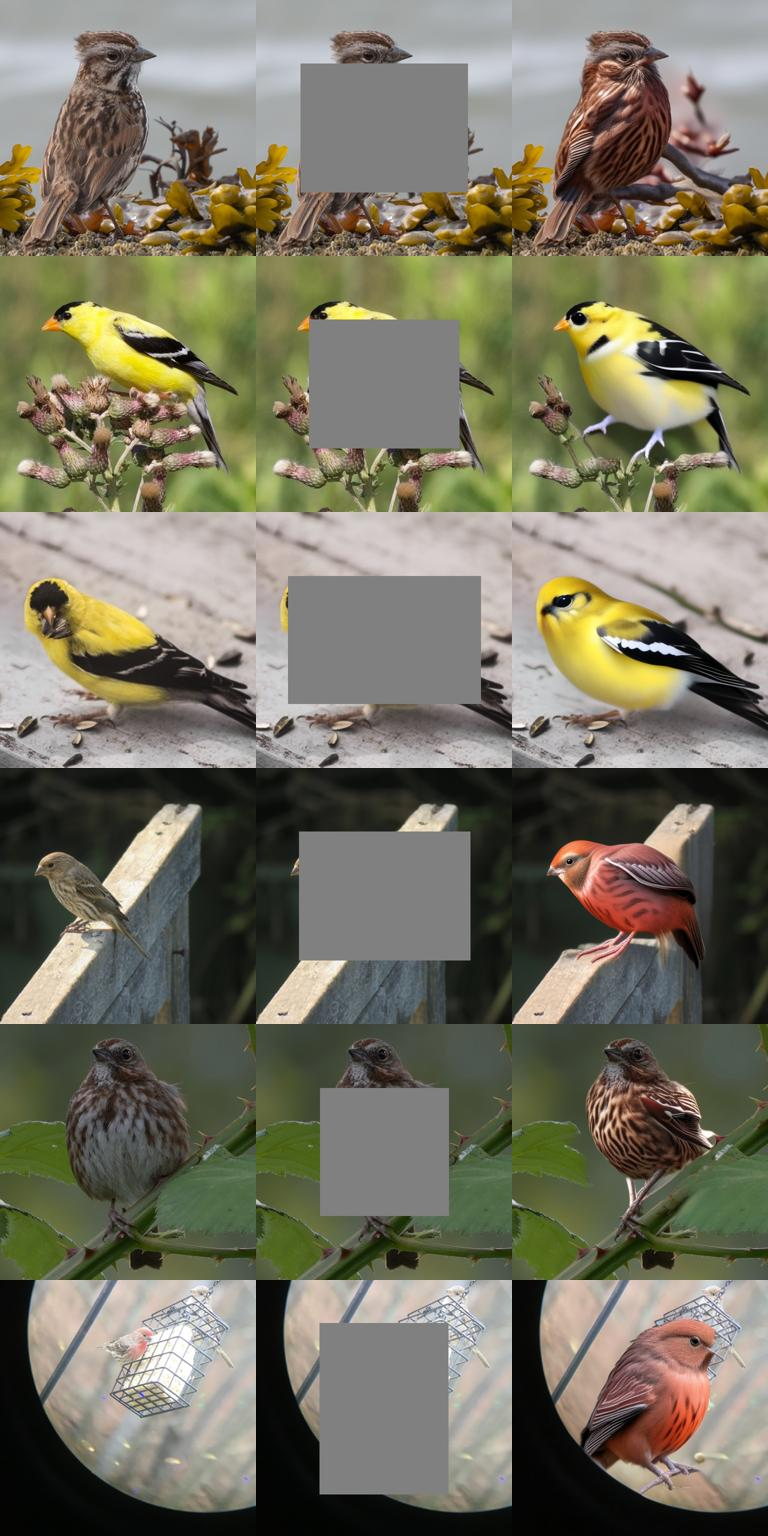

In [ ]:
STEPS = 20  # @param {type:"integer"}
GUIDANCE_SCALE = 4.0  # @param {type:"number"}

run_stage('frozen', '--steps', STEPS, '--guidance', GUIDANCE_SCALE)
show_image('kandinsky_inpainting_frozen_grid.jpg', 'Frozen model: photograph, masked view and output, one row per test photograph')

**What to notice:** the denoising loss by timestep — noise is harder to predict at low timesteps (little noise) than the mean suggests, so compare timestep by timestep later. The mean-fill floor should be the lowest CLIP number; the frozen model may sit below or above the original-photograph reference; the grid under the output (`outputs/kandinsky_inpainting_frozen_grid.jpg` in the run directory) shows each photograph, its masked view and the frozen output side by side. Preservation is high but not perfect.

<details>
<summary>Check your reasoning (open after answering)</summary>

A mean-colour fill leaves most of the bird out, so CLIP usually scores it well below the original photograph. A working inpainting model scores well above the floor, and it can score **above** the original photograph: it repaints the masked region to match the caption, while the original only has to contain the bird. In the recorded Kaggle T4 run of the previous revision the floor was 24.03, the frozen model 31.08 and the original photographs 30.27, and 7 of the 12 frozen outputs scored above their own original; on a BYOD run both models sat about 7 points above the reference. So the original photograph is a reference line, not a ceiling. Preservation is not perfect because the kept region is not copied pixel for pixel: it is carried through the MoVQ latents and decoded, which blurs fine texture slightly. A PSNR in the high 20s or 30s dB is a round-trip loss, not the model repainting the kept region. None of these numbers says whether a person would find the repainted bird convincing.

</details>

## 7. Bounded LoRA fine-tuning · [Concept]

The `adapt` stage calls `pipe.adapt`, which trains the 176 LoRA tensors (rank 8, 1,646,592 parameters — 0.13 % of the UNet) that `peft` attached to the UNet's attention projections `to_q`, `to_k`, `to_v` and `to_out.0`, and nothing else; the base UNet, the MoVQ and the prior are frozen. This is gradient-based parameter-efficient fine-tuning, not in-context conditioning. Each step takes one training photograph's latents and keep mask (MoVQ-encoded once), draws a timestep uniformly from the 1,000-step schedule and a noise tensor (both seeded), adds the noise, and minimises the mean squared error between the predicted and the true noise. The optimiser is AdamW at a fixed learning rate, with gradient-norm clipping at 1.0; on CUDA the LoRA tensors stay in float32 while the forward pass uses float16 autocast with a gradient scaler. Epoch 0 records the frozen model's validation loss, and the epoch with the lowest validation denoising loss is kept.

Before its process ends, the stage records two reference values of the trained model still in memory — its test denoising loss and one inpainted photograph at a fixed seed — and exports the adapter with `pipe.save_artifact` as `outputs/kandinsky_inpainting_adapter/`: the 176 trained tensors as `adapter.safetensors` with a `manifest.json` recording the artifact format, the decoder's id and revision, the LoRA configuration, the tensor names, the optimiser and precision, the file size and SHA-256, and the metadata passed in. The base model is not in the artifact: it must be reloaded from the pinned revision.

**Predict before running:** will the training loss fall steadily from epoch to epoch? Will the validation loss fall by more or less than the training loss?

In [ ]:
EPOCHS = 4  # @param {type:"integer"}
LEARNING_RATE = 1e-4  # @param {type:"number"}
BATCH_SIZE = 1  # @param {type:"integer"}

run_stage('adapt', '--epochs', EPOCHS, '--lr', LEARNING_RATE, '--batch-size', BATCH_SIZE)

Running stage 'adapt' in the isolated environment; log: /content/outputs/kandinsky_inpainting/c8190e696d67/logs/adapt.log


W1004 20:44:39.983000 5184 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W1004 20:44:40.033000 5184 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`


{'epoch': 0, 'train_loss': None, 'val_denoising_mse': 0.027311, 'note': 'frozen model (LoRA at initialization: B = 0)'}


...

{'epoch': 3, 'train_loss': 0.0155, 'val_denoising_mse': 0.027178}


{'epoch': 4, 'train_loss': 0.0249, 'val_denoising_mse': 0.02714}


{'trainable_parameters': 1646592, 'total_parameters': 1254721160, 'steps': 144, 'best_epoch': 4, 'optimizer': 'AdamW (weight_decay 0, grad-norm clip 1.0)', 'precision': 'float16 autocast + GradScaler', 'seconds': 75.5, 'gpu_memory_gb': 2.71}


{'artifact': '/content/outputs/kandinsky_inpainting/c8190e696d67/outputs/kandinsky_inpainting_adapter', 'format': 'org.valcorza.kandinsky-inpainting.adapter.v1', 'tensors': 176, 'bytes': 6607664, 'sha256': '2571b0ccf33c0461...'}


{'stage': 'adapt', 'status': 'ok', 'seconds': 167.4}


**What to notice:** one row per epoch, epoch 0 with no training loss; a training loss that jumps between epochs because each step draws a random timestep; a `best_epoch` that may be 0 if no epoch improved the validation loss — in that case the kept adapter is the untrained one; and the exported artifact: 176 tensors of about 6.6 MB with its SHA-256.

<details>
<summary>Check your reasoning (open after answering)</summary>

The training loss is noisy, not a smooth curve: with one photograph per step, a step at a low timestep and a step at a high timestep have very different losses. The validation loss is measured at five fixed timesteps with fixed noise, so it moves more smoothly and usually by a smaller amount. A falling validation loss shows the adapter predicts noise better on unseen photographs of the same birds; it does not show the repainted birds look better.

</details>

## 8. Held-out evaluation: the paired comparison · [Evaluation practice]

**Question tested:** on photographs never used for training or for choosing the epoch, what changed? The `evaluate` stage is a fresh process: it loads the adapter from the exported files — the artifact you would ship, not the object that was trained — and measures it exactly as the frozen model was measured in Section 6: the same seed, so the same latents, noise and timesteps for the denoising loss, and the same photographs, masks and generation seeds for inpainting. The stage asserts only what the procedure guarantees — the kept epoch's validation loss is no higher than the frozen model's (epoch 0) — and that the exported adapter reproduces the validation loss recorded for the kept epoch. The test-split change is printed, not asserted.

**Predict before running:** will the test denoising loss fall? Will CLIP prompt similarity rise or fall, and will the adapted outputs sit above or below the original-photograph reference? Will preservation change, and why or why not?

Running stage 'evaluate' in the isolated environment; log: /content/outputs/kandinsky_inpainting/c8190e696d67/logs/evaluate.log


W1004 20:47:32.396000 5893 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W1004 20:47:32.462000 5893 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]


...

{'grid': '/content/outputs/kandinsky_inpainting/c8190e696d67/outputs/kandinsky_inpainting_adapted_grid.jpg'}


{'test_denoising_mse_change': -0.000236, 'note': 'held-out observation, not asserted'}


{'report': '/content/outputs/kandinsky_inpainting/c8190e696d67/outputs/kandinsky_inpainting_evaluation_report.json'}


{'stage': 'evaluate', 'status': 'ok', 'seconds': 156.6}


Frozen model (Section 6) -> /content/outputs/kandinsky_inpainting/c8190e696d67/outputs/kandinsky_inpainting_frozen_grid.jpg


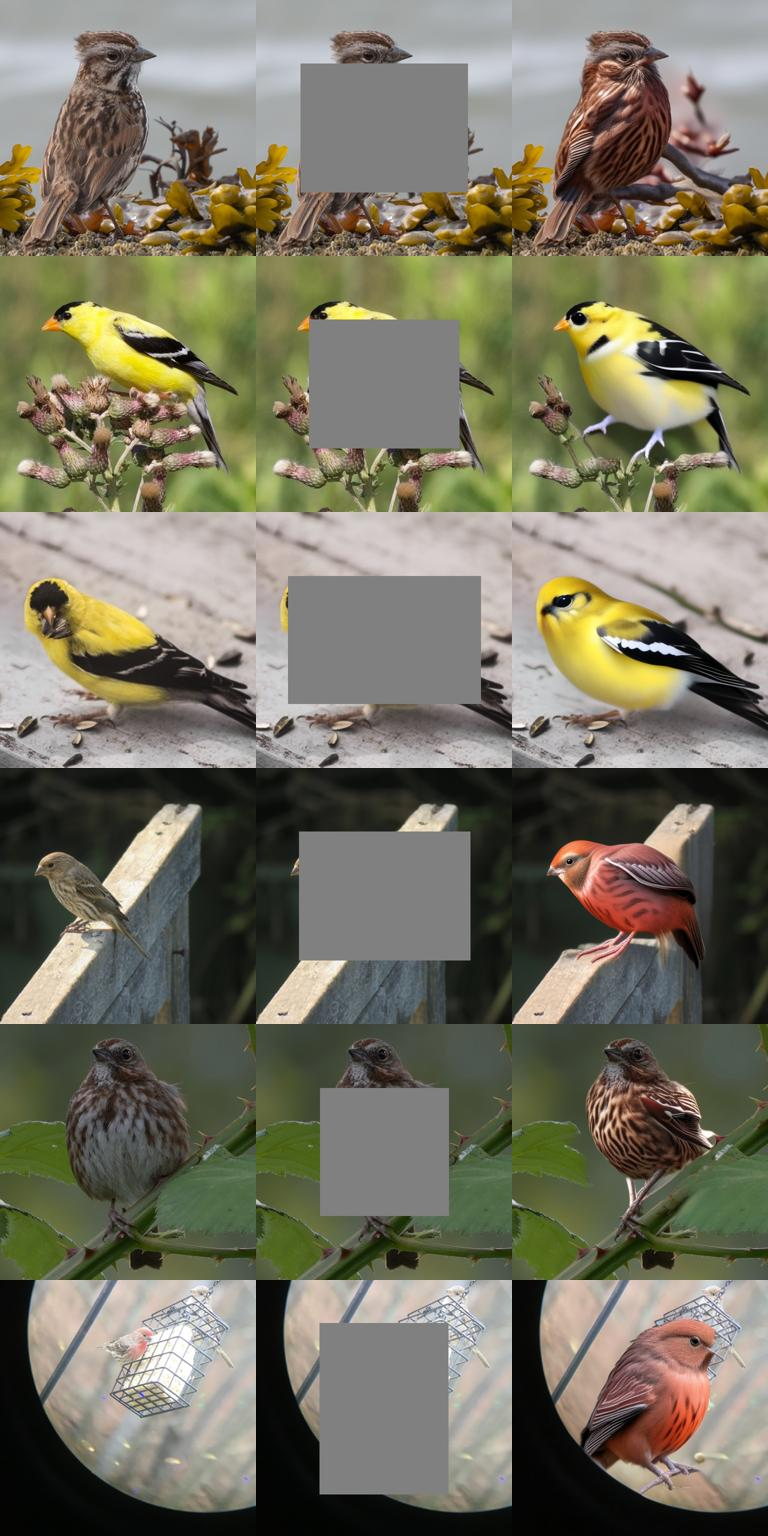

Adapted model: same photographs, masks and seeds -> /content/outputs/kandinsky_inpainting/c8190e696d67/outputs/kandinsky_inpainting_adapted_grid.jpg


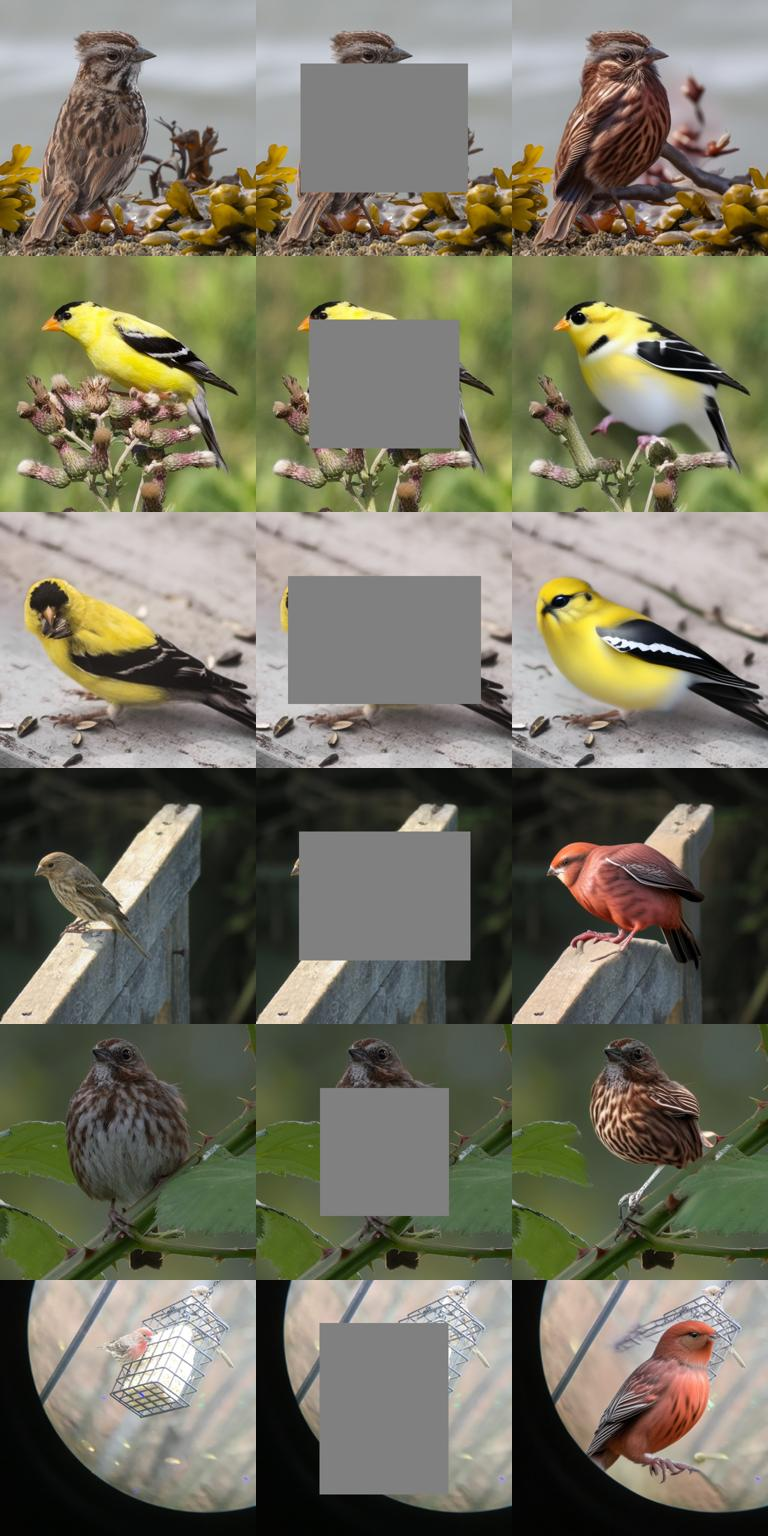

In [ ]:
run_stage('evaluate')
show_image('kandinsky_inpainting_frozen_grid.jpg', 'Frozen model (Section 6)')
show_image('kandinsky_inpainting_adapted_grid.jpg', 'Adapted model: same photographs, masks and seeds')

**What to notice:** read the rows side by side. The denoising loss rows compare identical inputs; the CLIP row shows both models beside the floor and the original-photograph reference, and `clip_above_own_original_photograph` counts, per image, how many outputs scored above their own original (the reference is not a ceiling); the preservation rows should barely move. Compare the two grids under the output — same photographs, masks and seeds, so any difference comes from the adapter. The full record is `outputs/kandinsky_inpainting_evaluation_report.json` in the run directory.

<details>
<summary>Check your reasoning (open after answering)</summary>

Preservation barely moves because the kept region is carried through the latents in both models: LoRA changes how the UNet repaints, not how the MoVQ decodes. A lower test denoising loss is the most direct evidence that the adapter learned something that transfers to unseen photographs of these birds. A CLIP change of a few tenths on twelve photographs from one seeded run is within the noise you would see from a different generation seed; treat it as an observation, not an improvement. The original photograph does not cap CLIP: outputs can score above it, so a model sitting near or above the reference has not reached a limit, and a fall in CLIP towards the reference is not a loss of quality either.

</details>

## 9. Fresh reload and a new caption · [Engineering]

**Fresh reload.** The `reload` stage is a second fresh process. `KandinskyInpaintPipeline.from_artifact` re-verifies the decoder and prior snapshots, checks the artifact format, the base-model identity and the weights digest **before** loading the tensors, and builds a new UNet with the adapter attached — a new object from files; nothing of the trained model survives in memory between processes. It reads the caption embeddings from the cache and checks parity against the two reference values the `adapt` process recorded from the trained model while it was still in memory: the same held-out denoising loss and the same inpainted photograph for the same caption and seed, within a stated tolerance.

**New-data inference.** Only after parity holds does the reloaded model inpaint `NEW_PROMPT` — a caption that appears in no training record — into the first two held-out test photographs with their masks (the same photograph twice if a BYOD test set holds one). The CLIP similarity and preservation are printed as a sanity check, not an evaluation. Finally the stage writes `outputs/kandinsky_inpainting_result.json` with the provenance, the runtime versions and the comparison, and lists every file in the run's `outputs/`.

**Expected result:** the artifact of about 6.6 MB (1,646,592 float32 values) with its SHA-256, a reload parity with a denoising-loss difference below `1e-6` and a mean absolute pixel difference below 1.0, two new-caption predictions, the listing of `outputs/`, and the two saved PNGs.

Running stage 'reload' in the isolated environment; log: /content/outputs/kandinsky_inpainting/c8190e696d67/logs/reload.log


{'artifact': '/content/outputs/kandinsky_inpainting/c8190e696d67/outputs/kandinsky_inpainting_adapter', 'format': 'org.valcorza.kandinsky-inpainting.adapter.v1', 'tensors': 176, 'bytes': 6607664, 'sha256': '2571b0ccf33c0461...'}


W1004 20:50:13.226000 6558 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W1004 20:50:13.278000 6558 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`


...

  - outputs/prepare.json (2.4 KB)


  - outputs/reload.json (0.8 KB)


  - outputs/weights.json (1.8 KB)


{'stage': 'reload', 'status': 'ok', 'seconds': 101.3}


New caption, first held-out photograph (reloaded adapter) -> /content/outputs/kandinsky_inpainting/c8190e696d67/outputs/kandinsky_inpainting_new_prompt_0.png


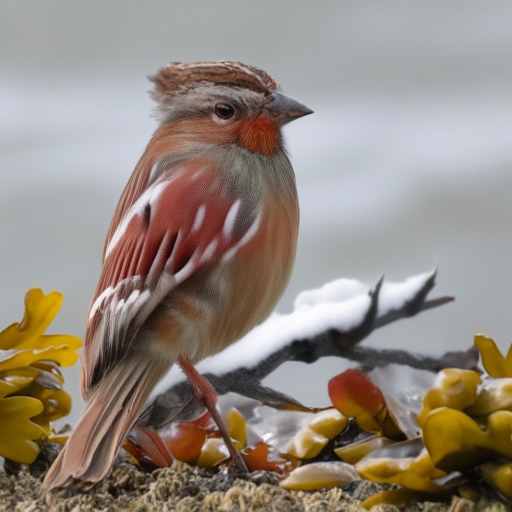

New caption, second held-out photograph (reloaded adapter) -> /content/outputs/kandinsky_inpainting/c8190e696d67/outputs/kandinsky_inpainting_new_prompt_1.png


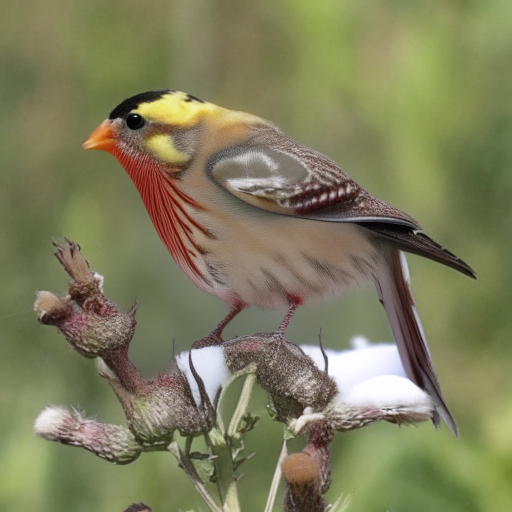

In [ ]:
run_stage('reload')
show_image('kandinsky_inpainting_new_prompt_0.png', 'New caption, first held-out photograph (reloaded adapter)')
show_image('kandinsky_inpainting_new_prompt_1.png', 'New caption, second held-out photograph (reloaded adapter)')

**What to notice:** the reloaded pipeline was built in a process that never saw the trained model — only `adapter.safetensors`, `manifest.json` and the verified base snapshots — so matching numbers show that the files alone carry the adaptation. That is what the artifact boundary guarantees; it does not show that the outputs are good. `outputs/kandinsky_inpainting_result.json` gathers identity, provenance, runtime versions, the comparison, the new-caption predictions and the parity in one machine-readable file.

## 10. Change one thing: the mask size · [Evaluation practice]

**Predict → Change one thing → Run → Observe → Explain.** This optional activity runs the `activity` stage, which loads the exported adapter and inpaints the first two test photographs again with the same captions and the same generation seeds as Section 8. Only the mask changes: a centred box whose side is a quarter (`small`) or three quarters (`large`) of each side, instead of the centre mask's half. It runs after every required output has been written and changes nothing that earlier sections produced; set `RUN_ACTIVITY = False` to skip it.

**Predict before running:** with a `large` mask, will the kept-region PSNR rise or fall? Will CLIP prompt similarity rise or fall? What do you expect with `small`?

Running stage 'activity' in the isolated environment; log: /content/outputs/kandinsky_inpainting/c8190e696d67/logs/activity.log


W1004 20:52:00.867000 7001 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W1004 20:52:00.922000 7001 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]


...

{'id': 'test-000', 'repaint_fraction': {'centre': 0.25, 'large': 0.5625}, 'unmasked_psnr_db': {'centre': 23.86, 'large': 17.7}, 'clip': {'centre': 32.65, 'large': 34.42}}


{'id': 'test-001', 'repaint_fraction': {'centre': 0.25, 'large': 0.5625}, 'unmasked_psnr_db': {'centre': 25.57, 'large': 23.01}, 'clip': {'centre': 35.79, 'large': 34.34}}


{'grid': '/content/outputs/kandinsky_inpainting/c8190e696d67/outputs/kandinsky_inpainting_activity_large_grid.jpg'}


{'stage': 'activity', 'status': 'ok', 'seconds': 90.1}


Adapted model with the large mask -> /content/outputs/kandinsky_inpainting/c8190e696d67/outputs/kandinsky_inpainting_activity_large_grid.jpg


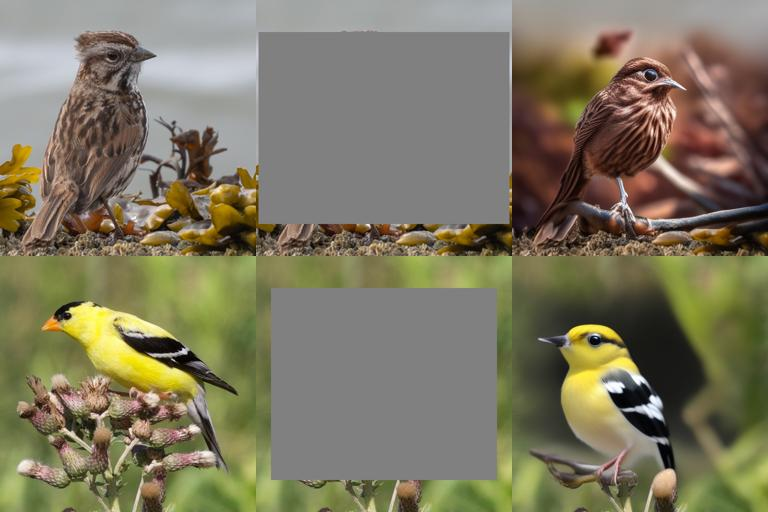

In [ ]:
RUN_ACTIVITY = True  # @param {type:"boolean"}
ACTIVITY_MASK = 'large'  # @param ["small", "large"]

if RUN_ACTIVITY:
    run_stage('activity', '--mask', ACTIVITY_MASK)
    show_image('kandinsky_inpainting_activity_' + ACTIVITY_MASK + '_grid.jpg', 'Adapted model with the ' + ACTIVITY_MASK + ' mask')
else:
    print({'activity': 'skipped (optional)', 'to_run': 'set RUN_ACTIVITY = True and choose ACTIVITY_MASK, then run this cell'})

**Observe and explain:** compare each row's `centre` and changed values, then the activity grid under the output. Did the result match your prediction? Explain it in terms of what the model is allowed to repaint and what the metrics measure. Then switch `ACTIVITY_MASK` and run this cell again.

<details>
<summary>Check your reasoning (open after answering)</summary>

A larger mask gives the model more of the photograph to repaint, so more of the bird is generated rather than kept. CLIP compares the whole photograph with the caption, so it can move either way: a well-repainted large region can still score high, while a poor one pulls the score down. Kept-region PSNR is computed over fewer pixels with a large mask, and those pixels sit near the edges of the photograph; its change reflects the MoVQ round trip on different content, not better or worse inpainting. The lesson: preservation and prompt similarity answer different questions, and both depend on the mask you chose.

</details>

## Interpretation and limits · [Evaluation practice]

A LoRA of 1.6 million parameters trained for a few minutes on 36 photographs is compared with the frozen model on twelve held-out photographs, on identical inputs. The denoising loss shows whether the adapter predicts noise better on unseen photographs of the same six birds; preservation shows how much of the kept region survives the MoVQ round trip; CLIP reads the outputs beside a mean-fill floor and the original-photograph reference, which they can exceed. That is the claim, and it is sample-sanity evidence only.

A denoising loss is the training objective, not a quality score. CLIP similarity is a frozen model's opinion, not a human judgement, and CLIP has its own biases about what a species name looks like. Twelve outputs per model from one seeded run give no dispersion estimate. Nothing here measures how natural the boundary between repainted and kept regions looks, the diversity of repaintings, or artefacts. The split assumes independent photographs; it is stratified within each caption, so the test measures new photographs of seen birds, not unseen ones. The upstream model may have seen photographs like these during pretraining, which cannot be ruled out. Fine-tuning on a narrow domain can also erode the model elsewhere — the new caption in Section 9 is one sanity check, not a test of generality.

Three things to carry to real data. **Masks are part of the contract:** the model learns to repaint the region you mask, given the rest; a centre mask teaches centred subjects, so use masks shaped like the edits you intend. **Captions describe the whole photograph:** the adapter learns the association between caption text and pixels. **Stratify by caption, and keep near-duplicates together:** every caption has held-out photographs, so the test measures new photographs of seen captions; a random split assumes independent photographs, so bursts, crops or edits of one scene must not straddle it. **Licences travel with the outputs:** the Kandinsky weights are Apache-2.0 and the photographs here are CC0 — with your own data, the rights to the photographs and to what the adapter produces are yours to establish.

## Conclude with evidence · [Evaluation practice]

Complete this in your own words:

> On [n] held-out photographs of [subject] with [mask], the adapted model's test denoising loss changed from [frozen] to [adapted], its kept-region PSNR from [frozen] to [adapted] dB, and its CLIP prompt similarity from [frozen] to [adapted], beside a mean-fill floor of [floor] and an original-photograph reference of [reference] ([k] of [n] adapted outputs above their own original). Changing the mask size showed [observation]. These are one seeded run on [n] photographs, scored by automated proxies; they do not establish [limitation]. Next I would [specific next step].

<details>
<summary>Check your reasoning (open after answering)</summary>

A strong conclusion names the photographs, the mask and the split; reports the frozen, adapted, floor and reference numbers side by side, including any that did not improve; separates what was measured (noise prediction, kept-region fidelity, CLIP agreement) from what was not (how convincing the repainting looks to a person, behaviour on other subjects); and ends with a concrete next step, such as repeating the comparison over several generation seeds or asking people to rate the repainted regions. A weak conclusion says only that "fine-tuning improved inpainting".

</details>

**Transfer:** repeat the notebook with `USE_BYOD = True` on your own photographs, with masks drawn over the regions you actually want to edit, and compare the same four numbers.

## Troubleshooting

| Symptom | Likely cause | What to do |
|---|---|---|
| Section 1 stops with `No GPU driver was found` or `CUDA was not detected`, or Section 2 stops with `The isolated environment cannot see a CUDA GPU` | the runtime has no GPU | *Runtime → Change runtime type → T4 GPU*, then run all again from the top. This notebook is not supported on a CPU-only runtime. If Colab offers no GPU, your GPU quota may be exhausted; try again later. |
| Section 1 stops with `This notebook needs a Linux x86_64 GPU runtime` | a local Windows or macOS kernel, or an ARM machine | Use Google Colab, Kaggle, or a Linux x86_64 machine with a CUDA GPU: the locked environment is built for manylinux x86_64 wheels. |
| Section 1 stops with `Not enough free disk` | the snapshots need about 16.5 GB and the isolated environment about 12 GB | Start a fresh runtime with about 30 GB free; a `weights/` directory from an earlier run is reused and counted. |
| `Carried file integrity failure` in Section 2 | a carried file was edited in the notebook | Do not edit the infrastructure cells; open a fresh copy of the notebook from the repository. |
| `uv 0.12.15 wheel size/hash mismatch`, or a `URLError` / timeout while downloading it | a network failure or an unexpected response from PyPI | Re-run the Section 2 install cell. Never replace the pinned URL or digest. |
| `CalledProcessError` from `uv venv` or `uv pip install` (for example a hash mismatch, `Failed to download` or HTTP 5xx) | a transient PyPI or network failure, or a package that no longer matches the lock | Re-run the Section 2 install cell: `uv` reuses what it already downloaded. If a hash mismatch repeats, stop and report it — never remove `--require-hashes`, a pin or a hash to get past it. |
| `RuntimeError: Stage '…' failed (exit 2): …` | the stage raised an error; the message after the colon is the stage's own error, and the stage's full log (with the traceback) is printed above it and kept in the run directory's `logs/` | Find the message in the rows below. A stage reads only files, so after fixing the cause you can re-run that cell and the cells after it. |
| `… is missing: run the stage that writes it before …` | a learner cell was run before an earlier stage | Run the notebook from the top, or re-run the earlier cells in order. |
| `the dataset changed since 'prepare'` | the BYOD zip or the photo cache changed after Section 4 | Re-run from Section 4. |
| A download error (timeout, HTTP 429/5xx) in Section 3 | a transient Hugging Face Hub failure | Re-run the Section 3 cell: staging only fetches the files that are still absent. |
| `ValueError: ...: size ... != manifest ...` or `sha256 ... != manifest ...` | a partial or corrupted download (staging checks that a file exists, verification checks its bytes) | Delete the named file under `weights/` and re-run the Section 3 cell. Never edit a manifest to get past a mismatch. |
| `No space left on device` during a stage | the disk filled after the Section 1 check | Start a fresh runtime with about 30 GB free. |
| A photograph fetch fails in Section 4 (`URLError`, or a size or SHA-256 mismatch) | a network failure or an unexpected response from the iNaturalist bucket | Re-run the Section 4 cell; photographs already verified are kept in `weights/inat-birds/` and reused. |
| `CUDA out of memory` | a form field was raised (`BATCH_SIZE`), or another program in the runtime holds GPU memory | Set the fields back to their defaults and re-run that cell: each stage is its own process, so the failed stage's memory was released when it stopped. |
| A training loss is `nan` | the learning rate is too high | Keep `LEARNING_RATE` at or below `1e-4` and re-run from Section 7; report the run if it persists. |
| `ModuleNotFoundError: No module named 'google.colab'` with `USE_BYOD = True` | the upload dialog needs Google Colab | Set `BYOD_PATH` to a zip already in the runtime, use Colab for the upload, or keep `USE_BYOD = False`. |
| BYOD: `captions.csv is missing columns [...]` or `file ... is not in the dataset` | the zip layout differs from the contract | Fix the named row or file in your zip: `captions.csv` needs `id`, `file`, `caption` (and optionally `mask`), and every named file must be in the zip; the run directory's `outputs/kandinsky_inpainting_sample_captions.csv` shows the shape. |
| BYOD: `mask ... is WxH px but its image is ... px; they must match` | a mask saved at another size | Save each mask at exactly its photograph's size. |
| BYOD: `image sides must be within 256..4096 px`, `split leaves no test record` or `split leaves N training records` | a photograph is too small or too large, or there are too few photographs per caption | Resize the photograph. Give at least one caption three or more photographs, and provide at least **6 distinct photographs** so that 4 remain for training after each caption with 3..7 photographs gives one test and one validation photograph — for example six of one caption, or four of each of two captions. |
| `near_duplicates_across_splits` is above 0 in Section 4 | near-copies of one scene (bursts, crops, edits) landed in different splits | Remove all but one photograph of each scene from your zip and re-run from Section 4; otherwise the held-out numbers are optimistic. |

Successful execution proves that the recorded repository revision's pipeline modules and stage runner, carried in this standalone notebook and run in an isolated hash-locked environment, can stage and digest-verify three pinned safetensors snapshots, fetch and validate digest-pinned real photographs with their masks, encode captions and release the prior, execute bounded LoRA fine-tuning, evaluate the frozen and the adapted model on identical held-out inputs beside a mean-fill floor and an original-photograph reference, reload the exported adapter in a fresh process with parity to the trained model, and emit the shown machine-readable artifacts — without the repository being reachable. It does **not** establish benchmark superiority, production fitness, or image quality beyond the checks shown.

## References

- Repository README: https://github.com/kurtvalcorza/kandinsky-inpainting-pipeline/blob/main/README.md
- Repository model card: https://github.com/kurtvalcorza/kandinsky-inpainting-pipeline/blob/main/MODEL_CARD.md
- Weights notes: https://github.com/kurtvalcorza/kandinsky-inpainting-pipeline/blob/main/docs/WEIGHTS.md
- Hugging Face decoder repository: https://huggingface.co/kandinsky-community/kandinsky-2-2-decoder-inpaint (revision `db790ad5cbcabed886f069ef2710774657621702`)
- Hugging Face prior repository: https://huggingface.co/kandinsky-community/kandinsky-2-2-prior (revision 9fc51ad5732afc5d031724219d22e6c42179c5a8)
- Razzhigaev, A., et al. (2023). Kandinsky: An improved text-to-image synthesis with image prior and latent diffusion. arXiv:2310.03502: https://arxiv.org/abs/2310.03502
- uv (the installer that builds the isolated environment): https://docs.astral.sh/uv/
- Hu, E. J., et al. (2022). LoRA: Low-rank adaptation of large language models. ICLR: https://arxiv.org/abs/2106.09685
- Cherti, M., et al. (2023). Reproducible scaling laws for contrastive language-image learning. CVPR (the LAION CLIP scorer): https://arxiv.org/abs/2212.07143
- Wang, Z., et al. (2004). Image quality assessment: From error visibility to structural similarity. IEEE TIP (SSIM): https://doi.org/10.1109/TIP.2003.819861
- DIMER Notebook Specification 2.2 and Model Card Specification 1.2 (in the ml-worker repository)

**AI assistance disclosure:** generative AI assisted this notebook's code and technical writing under maintainer direction. Tests, pinned identities, manifests and source files remain the authoritative evidence.